 RQ4 – Are there gender differences in visual attention allocation across semantically meaningful source-code construct categories during code comprehension?

While the previous research question examined how visual attention unfolded sequentially across the code, it did not address whether attention was preferentially allocated to particular types of source-code constructs.

RQ4 therefore extends the earlier analysis by shifting the focus from reading order to construct-level attention allocation. Using fine-grained categories derived from srcML syntactic context, this research question investigates whether male and female participants differ in how visual attention is distributed during code comprehension across distinct source-code construct categories, such as class signatures, class members, method signatures, control-flow elements, method calls, and return statements.

# Mount and import

In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [2]:
import sys
sys.path.append('/content/drive/MyDrive/EMIP-Toolkit')
sys.path.append('/content/drive/MyDrive/EMIP-Toolkit/emtk')
sys.path.append('/content/drive/MyDrive/EMIP-Toolkit/emtk/parsers')

In [3]:
import parsers
import aoi
import visualization
import util

In [4]:
import os
import pandas as pd
import numpy as np

In [5]:
DATA_LOSS_THRESHOLD = 70.0

In [6]:
RAWDATA = "emtk/datasets/EMIP/EMIP-Toolkit- replication package/emip_dataset/rawdata"

# Testing for Validity Column in raw samples


In [7]:
desired_path = '/content/drive/MyDrive/EMIP-Toolkit'
os.chdir(desired_path)

In [8]:
def process_batch(batch, invalid_values):
    """Process a batch of TSV lines, extracting timestamp + R Validity safely."""
    valid_lines = 0
    invalid_lines = 0
    for line in batch:
        cols = line.split("\t")

        # We ONLY care about SMP rows
        if len(cols) < 2:
            continue
        if cols[1] != "SMP":
            continue

        # Check timestamp exists
        timestamp = cols[0].strip() if len(cols) > 0 else None

        # Safely extract R Validity (col 27)
        if len(cols) > 27:
            r_validity = cols[27].strip()
        else:
            # Missing R validity — treat as invalid
            r_validity = "MISSING"

        # Check if invalid
        if r_validity not in ("0", "1"):
            invalid_values.add(r_validity)
        else:
          if r_validity == "1":
            valid_lines += 1
          else:
            invalid_lines += 1

    return valid_lines, invalid_lines


In [9]:

# Global counters
files_all_valid = 0
files_with_invalid = 0


def check_validity_in_batches(tsv_path, batch_size=10):
    """
    Stream-reads a TSV file in small batches.
    Extracts timestamp + R-validity only from SMP rows.
    Tracks invalid R-validity values.
    """
    global files_all_valid, files_with_invalid


    print(f"\nChecking file: {os.path.basename(tsv_path)}")

    invalid_values = set()
    total_lines = 0
    total_valid_lines = 0
    total_invalid_lines =0
    participant_id = os.path.basename(tsv_path).split("_")[0]
    batch = []


    with open(tsv_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            total_lines += 1

            if not line.strip():
                continue

            batch.append(line)

            if len(batch) >= batch_size:
                valid_lines, invalid_lines = process_batch(batch, invalid_values)
                total_valid_lines += valid_lines
                total_invalid_lines += invalid_lines
                batch = []

        # last partial batch
        if batch:
            process_batch(batch, invalid_values)

    # ---- Summary for THIS file ----
    if invalid_values:
        print(f" Invalid R Validity values: {invalid_values}")
        files_with_invalid += 1
    else:
        print(f" All R Validity values are 0 or 1.")
        files_all_valid += 1

    print(f"Processed {total_lines} lines.")
    print(f"Valid lines: {total_valid_lines}")
    print(f"Invalid lines: {total_invalid_lines}")
    percentage_valid = (total_valid_lines / total_lines) * 100
    print(f"Percentage of valid lines: {percentage_valid}")
    if percentage_valid >= DATA_LOSS_THRESHOLD:
      valid_participants.add(participant_id)



In [10]:

global valid_participants
valid_participants = set()
for root, dirs, files in os.walk(RAWDATA):
    for fname in files:
        if fname.endswith(".tsv") and fname[0].isdigit():
           check_validity_in_batches(os.path.join(root, fname), batch_size=10)


# ---------------------------
# FINAL GLOBAL SUMMARY
# ---------------------------
print("\n====================++====SUMMARY=====++======================")
print(f"Files with ONLY R-validity values (0 or 1):  {files_all_valid}")
print(f"Files with R-validity values other than 0/1: {files_with_invalid}")
print(f"Valid participants: {valid_participants}")
print(f"Total valid participants: {len(valid_participants)}")
print("=================================================================\n")



Checking file: 99_rawdata.tsv
 All R Validity values are 0 or 1.
Processed 49759 lines.
Valid lines: 48848
Invalid lines: 853
Percentage of valid lines: 98.16917542555116

Checking file: 96_rawdata.tsv
 All R Validity values are 0 or 1.
Processed 47777 lines.
Valid lines: 40753
Invalid lines: 6968
Percentage of valid lines: 85.29836532222618

Checking file: 97_rawdata.tsv
 All R Validity values are 0 or 1.
Processed 49360 lines.
Valid lines: 48757
Invalid lines: 554
Percentage of valid lines: 98.77836304700162

Checking file: 91_rawdata.tsv
 All R Validity values are 0 or 1.
Processed 34786 lines.
Valid lines: 32957
Invalid lines: 1774
Percentage of valid lines: 94.74213764157994

Checking file: 85_rawdata.tsv
 All R Validity values are 0 or 1.
Processed 37146 lines.
Valid lines: 35745
Invalid lines: 1351
Percentage of valid lines: 96.22839605879503

Checking file: 9_rawdata.tsv
 All R Validity values are 0 or 1.
Processed 48338 lines.
Valid lines: 33281
Invalid lines: 15005
Percentag

# Trackability threshold


In [11]:
desired_path = '/content/drive/MyDrive/EMIP-Toolkit'
os.chdir(desired_path)

In [12]:
def check_code_reading_validity(tsv_path):
    participant_id = os.path.basename(tsv_path).split("_")[0]

    in_code_section = False
    total_samples = 0
    valid_samples = 0

    with open(tsv_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            cols = line.split("\t")
            if len(cols) < 2:
                continue

            row_type = cols[1].strip()

            if row_type == "MSG":
                if len(cols) > 3:
                    raw = cols[3].strip()
                    stimulus = cols[3].split(' ')[-1]
                    if stimulus.startswith("vehicle") or stimulus.startswith("rectangle"):
                        in_code_section = True
                    else:
                        in_code_section = False

            elif row_type == "SMP" and in_code_section:
                total_samples += 1
                r_validity = cols[27].strip() if len(cols) > 27 else None
                if r_validity == "1":
                    valid_samples += 1

    if total_samples == 0:
        print(f"[{participant_id}] No SMP samples found during code-reading sections.")
        return participant_id, None

    pct_valid = (valid_samples / total_samples) * 100
    print(f"[{participant_id}] Code-reading samples: {total_samples} | "
          f"Valid: {valid_samples} | {pct_valid:.1f}%")
    return participant_id, pct_valid




In [13]:
# ── Run ──────────────────────────────────────────────────────────────────────

results = {}

for root, dirs, files in os.walk(RAWDATA):
    for fname in files:
        if fname.endswith(".tsv") and fname[0].isdigit():
            pid, pct = check_code_reading_validity(os.path.join(root, fname))
            results[pid] = pct

# ── Summary ──────────────────────────────────────────────────────────────────

trackable_participants = {pid for pid, pct in results.items()
                      if pct is not None and pct >= DATA_LOSS_THRESHOLD}

print("\n==================== SUMMARY ====================")
for pid, pct in sorted(results.items()):
    pct_str = f"{pct:.1f}%" if pct is not None else "N/A"
    print(f"  {pid}: {pct_str} valid during code reading")

print(f"\nValid participants (>= {DATA_LOSS_THRESHOLD}%): {len(trackable_participants)}")
print(f"Length of valid participants {len(trackable_participants)}")
print("==================================================\n")

[99] Code-reading samples: 27701 | Valid: 27334 | 98.7%
[96] Code-reading samples: 29419 | Valid: 28836 | 98.0%
[97] Code-reading samples: 27900 | Valid: 27675 | 99.2%
[91] Code-reading samples: 23765 | Valid: 22585 | 95.0%
[85] Code-reading samples: 24250 | Valid: 23215 | 95.7%
[9] Code-reading samples: 27806 | Valid: 16529 | 59.4%
[94] Code-reading samples: 19357 | Valid: 19025 | 98.3%
[93] Code-reading samples: 9420 | Valid: 8383 | 89.0%
[87] Code-reading samples: 30532 | Valid: 27100 | 88.8%
[90] Code-reading samples: 8674 | Valid: 8478 | 97.7%
[83] Code-reading samples: 38912 | Valid: 37522 | 96.4%
[8] Code-reading samples: 50358 | Valid: 43460 | 86.3%
[74] Code-reading samples: 14902 | Valid: 13351 | 89.6%
[88] Code-reading samples: 29053 | Valid: 27327 | 94.1%
[84] Code-reading samples: 36312 | Valid: 32235 | 88.8%
[98] Code-reading samples: 18734 | Valid: 7431 | 39.7%
[81] Code-reading samples: 26643 | Valid: 26399 | 99.1%
[76] Code-reading samples: 32269 | Valid: 28903 | 89.6%

In [14]:
print(f"Number of participants in valid_participants: {len(valid_participants)}")
print(f"Number of participants in trackable_participants: {len(trackable_participants)}")

# Find common participants
common_participants = valid_participants.intersection(trackable_participants)
print(f"\nCommon participants ({len(common_participants)}): {sorted(list(common_participants))}")

# Find participants in valid_participants but not in trackable_participants
valid_but_not_trackable = valid_participants.difference(trackable_participants)
if valid_but_not_trackable:
    print(f"\nParticipants in valid_participants but NOT in trackable_participants ({len(valid_but_not_trackable)}): {sorted(list(valid_but_not_trackable))}")
else:
    print("\nAll participants in valid_participants are also in trackable_participants.")

# Find participants in trackable_participants but not in valid_participants
trackable_but_not_valid = trackable_participants.difference(valid_participants)
if trackable_but_not_valid:
    print(f"\nParticipants in trackable_participants but NOT in valid_participants ({len(trackable_but_not_valid)}): {sorted(list(trackable_but_not_valid))}")
else:
    print("\nAll participants in trackable_participants are also in valid_participants.")

# Check if sets are identical
if valid_participants == trackable_participants:
    print("\nThe sets valid_participants and trackable_participants are identical.")
else:
    print("\nThe sets valid_participants and trackable_participants are NOT identical.")

Number of participants in valid_participants: 187
Number of participants in trackable_participants: 188

Common participants (183): ['10', '100', '101', '105', '106', '107', '108', '109', '11', '110', '112', '113', '114', '115', '116', '117', '118', '119', '12', '120', '121', '122', '123', '124', '126', '128', '13', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '14', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '15', '150', '151', '152', '153', '154', '155', '156', '157', '158', '159', '16', '160', '161', '162', '163', '164', '165', '166', '168', '169', '17', '170', '171', '172', '175', '176', '177', '178', '179', '180', '181', '182', '183', '184', '185', '186', '187', '188', '189', '190', '191', '192', '193', '194', '195', '196', '197', '198', '2', '20', '200', '201', '202', '206', '207', '208', '21', '210', '211', '213', '214', '215', '216', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', 

# Load Participants

In [15]:
MAX_DISPERSION = 68
MINIMUM_DURATION = 100

First half of participants 1 - 108

In [16]:
desired_path = '/content/drive/MyDrive/EMIP-Toolkit'
os.chdir(desired_path)

In [17]:
eye_events, samples, stimulus_time = parsers.EMIP(sample_size = 108,
                                                  process_raw_samples=False,
                                                  use_minus_one_for_invalid_gaze=False,
                                                  classifier="idt",
                                                  maximum_dispersion = MAX_DISPERSION,
                                                  minimum_duration = MINIMUM_DURATION)

Loaded metadata for 216 participants
Gender mapping created for 216 participants
Males: 175
Females: 41
Finished loading eye events for participants.


Second half of participants 109 - 216

In [18]:
eye_events2, samples2, stimulus_time2 = parsers.EMIP(sample_size = 108,
                                                     start_index = 108,
                                                     process_raw_samples=False,
                                                     use_minus_one_for_invalid_gaze=False,
                                                     classifier="idt",
                                                     maximum_dispersion = MAX_DISPERSION,
                                                     minimum_duration = MINIMUM_DURATION)

Loaded metadata for 216 participants
Gender mapping created for 216 participants
Males: 175
Females: 41
Finished loading eye events for participants.


Combine the two batches of eye events

In [19]:
eye_events = pd.concat([eye_events, eye_events2])

In [20]:
eye_events.head()

,eye_tracker,experiment_id,participant_id,filename,trial_id,stimuli_module,stimuli_name,timestamp,duration,x0,y0,token,pupil,eye_event_type,gender
0,SMIRed250,1,1,1_rawdata.tsv,0,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,instruction_calibration.jpg,947809128,270.938,1532.046744,252.807907,"[1008043594, MSG, 1, # Message: instruction_co...",0,fixation,male
1,SMIRed250,1,1,1_rawdata.tsv,0,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,instruction_calibration.jpg,948829995,119.831,813.900667,513.561000,"[1008043594, MSG, 1, # Message: instruction_co...",0,fixation,male
2,SMIRed250,1,1,1_rawdata.tsv,1,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,instruction_comprehension.jpg,1008594653,188.028,990.360833,432.789583,"[1020309277, MSG, 1, # Message: vehicle_java.jpg]",0,fixation,male
3,SMIRed250,1,1,1_rawdata.tsv,1,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,instruction_comprehension.jpg,1008798679,95.991,925.132400,408.627200,"[1020309277, MSG, 1, # Message: vehicle_java.jpg]",0,fixation,male
4,SMIRed250,1,1,1_rawdata.tsv,1,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,instruction_comprehension.jpg,1009110603,99.997,790.459231,285.858462,"[1020309277, MSG, 1, # Message: vehicle_java.jpg]",0,fixation,male


Merge samples if loaded

In [21]:
if samples and not samples.empty and samples2 and not samples2.empty:
    samples = pd.concat([samples, samples2])

In [22]:
if samples and not samples.empty:
  samples.head()
else:
  print("Raw samples not loaded")

Raw samples not loaded


In [23]:
#find unique participants and number of participants in data frame eye_events
unique_participants = eye_events['participant_id'].unique()
print("There are " + str(len(unique_participants)) +  " Participants in the dataset are" + str(unique_participants))

There are 216 Participants in the dataset are['1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '13' '14' '15' '16'
 '17' '18' '19' '20' '21' '22' '23' '24' '25' '26' '27' '28' '29' '30'
 '31' '32' '33' '34' '35' '36' '37' '38' '39' '40' '41' '42' '43' '44'
 '45' '46' '47' '48' '49' '50' '51' '52' '53' '54' '55' '56' '57' '58'
 '59' '60' '61' '62' '63' '64' '65' '66' '67' '68' '69' '70' '71' '72'
 '73' '74' '75' '76' '77' '78' '79' '80' '81' '82' '83' '84' '85' '86'
 '87' '88' '89' '90' '91' '92' '93' '94' '95' '96' '97' '98' '99' '100'
 '101' '102' '103' '104' '105' '106' '107' '108' '109' '110' '111' '112'
 '113' '114' '115' '116' '117' '118' '119' '120' '121' '122' '123' '124'
 '125' '126' '127' '128' '129' '130' '131' '132' '133' '134' '135' '136'
 '137' '138' '139' '140' '141' '142' '143' '144' '145' '146' '147' '148'
 '149' '150' '151' '152' '153' '154' '155' '156' '157' '158' '159' '160'
 '161' '162' '163' '164' '165' '166' '167' '168' '169' '170' '171' '172'
 '173' '174' '175'

Combine time spent on each stimulus




In [24]:
stimulus_time = pd.concat([stimulus_time, stimulus_time2])

In [25]:
display(stimulus_time)
display(len(stimulus_time))

,participant_id,gender,trial,stimulus_name,start_timestamp,end_timestamp,time_spenton_stimuli
0,1,male,0,instruction_calibration.jpg,945553890,952864364,7310474
1,1,male,1,instruction_comprehension.jpg,1008050652,1020308008,12257356
2,1,male,2,vehicle_java.jpg,1020312074,1097995373,77683299
3,1,male,3,mupliple_choice_vehicle.jpg,1097999372,1137882278,39882906
4,1,male,4,instruction_comprehension.jpg,1137916069,1145160532,7244463
...,...,...,...,...,...,...,...
751,216,female,2,vehicle_java2.jpg,406962816,481100215,74137399
752,216,female,3,mupliple_choice_vehicle.jpg,481116216,497818826,16702610
753,216,female,4,instruction_comprehension.jpg,497838818,502194738,4355920
754,216,female,5,rectangle_java2.jpg,502198746,535731617,33532871


1512

The interval between two consecutive timestamps is 3994 indicating that the unit of time used in the raw data is microseconds. For 250Hz SMI RED250 tracker, one data point is captured every 4 ms, which equals 4000 microseconds - 3994 is a slight variation that could have been caused due to minor fluctuations in hardware's internal clock or processing overhead. Safe to assume that the timestamp captured is in microseconds and time spent on any stimulus can be calculated as End Timestamp - Start Timestamp divided by 1000,000

In [26]:
#Adding an extra column to convert the time spent on stimulus to seconds from microseconds
stimulus_time['tss_second'] = stimulus_time['time_spenton_stimuli'] / 1000000

# Filter out the ones with more than threshold of data loss


In [27]:
#find the number of unique participants in eye_events
unique_participants = eye_events['participant_id'].unique()
print("There are " + str(len(unique_participants)) +  " Participants in the dataset are" + str(unique_participants))
#find the number of unique participants in stimulus_time
unique_participants = stimulus_time['participant_id'].unique()
print("There are " + str(len(unique_participants)) +  " Participants in the dataset are" + str(unique_participants))

There are 216 Participants in the dataset are['1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '13' '14' '15' '16'
 '17' '18' '19' '20' '21' '22' '23' '24' '25' '26' '27' '28' '29' '30'
 '31' '32' '33' '34' '35' '36' '37' '38' '39' '40' '41' '42' '43' '44'
 '45' '46' '47' '48' '49' '50' '51' '52' '53' '54' '55' '56' '57' '58'
 '59' '60' '61' '62' '63' '64' '65' '66' '67' '68' '69' '70' '71' '72'
 '73' '74' '75' '76' '77' '78' '79' '80' '81' '82' '83' '84' '85' '86'
 '87' '88' '89' '90' '91' '92' '93' '94' '95' '96' '97' '98' '99' '100'
 '101' '102' '103' '104' '105' '106' '107' '108' '109' '110' '111' '112'
 '113' '114' '115' '116' '117' '118' '119' '120' '121' '122' '123' '124'
 '125' '126' '127' '128' '129' '130' '131' '132' '133' '134' '135' '136'
 '137' '138' '139' '140' '141' '142' '143' '144' '145' '146' '147' '148'
 '149' '150' '151' '152' '153' '154' '155' '156' '157' '158' '159' '160'
 '161' '162' '163' '164' '165' '166' '167' '168' '169' '170' '171' '172'
 '173' '174' '175'

In [28]:
#in eye_events and stimulus_time only keep those participants where participant_id is in valid_participants set
eye_events = eye_events[eye_events['participant_id'].isin(trackable_participants)]
stimulus_time = stimulus_time[stimulus_time['participant_id'].isin(trackable_participants)]

In [29]:
#find the number of unique participants in eye_events
unique_participants = eye_events['participant_id'].unique()
print("There are " + str(len(unique_participants)) +  " Participants afer filtering are" + str(unique_participants))
#find the number of unique participants in stimulus_time
unique_participants = stimulus_time['participant_id'].unique()
print("There are " + str(len(unique_participants)) +  " Participants after filtering are" + str(unique_participants))

There are 188 Participants afer filtering are['2' '3' '4' '5' '6' '7' '8' '10' '11' '12' '13' '14' '15' '16' '17' '18'
 '20' '21' '23' '24' '25' '26' '27' '28' '29' '30' '31' '32' '33' '34'
 '35' '36' '37' '38' '39' '40' '42' '43' '44' '45' '46' '47' '48' '49'
 '51' '53' '54' '55' '56' '57' '58' '59' '60' '61' '62' '63' '64' '68'
 '69' '70' '71' '72' '73' '74' '75' '76' '78' '79' '80' '81' '82' '83'
 '84' '85' '86' '87' '88' '89' '90' '91' '93' '94' '95' '96' '97' '99'
 '100' '101' '105' '106' '107' '108' '109' '110' '112' '113' '114' '115'
 '116' '117' '118' '119' '120' '121' '122' '123' '124' '126' '128' '130'
 '131' '132' '133' '134' '135' '136' '137' '138' '139' '140' '141' '142'
 '143' '144' '145' '146' '147' '148' '149' '150' '151' '152' '153' '154'
 '155' '156' '157' '158' '159' '160' '161' '162' '163' '164' '165' '166'
 '167' '168' '169' '170' '171' '172' '175' '176' '177' '178' '179' '180'
 '181' '182' '183' '184' '185' '186' '187' '188' '189' '190' '191' '192'
 '193' '194' '1

#Load metadata


Load gender map





In [30]:
desired_path = os.path.join(
    '/content/drive/MyDrive/EMIP-Toolkit/emtk/datasets/EMIP',
    'EMIP-Toolkit- replication package',
    'emip_dataset'
)

os.chdir(desired_path)

In [31]:
from collections import Counter
METADATA_FILE = 'emip_metadata.csv'
try:
    metadata_df = pd.read_csv(METADATA_FILE)
    print(f"Loaded metadata for {len(metadata_df)} participants")

except FileNotFoundError:
    print(f"Warning: Metadata file '{METADATA_FILE}' not found")
except Exception as e:
    print(f"Error loading metadata: {e}.")

Loaded metadata for 216 participants


In [32]:
metadata_df.head()

,id,age,gender,mother_tongue,english_level,visual_aid,makeup,experiment_language,expertise_experiment_language,time_experiment_language,...,order_rectangle,stimulus_rectangle,answer_vehicle,correct_vehicle,order_vehicle,stimulus_vehicle,mother_tongue_original,time_experiment_language_original,time_programming_original,other_languages_original
0,1,63,male,Czech,high,glasses,no,Java,high,30.0,...,2,rectangle_java.jpg,"... defines a vehicle by a producer, that has ...",0,1,vehicle_java.jpg,czech,30y,40+,CoffeeScript (high) JavaScript (high) Python (...
1,2,24,male,Slovak,medium,glasses,no,Java,medium,2.0,...,1,rectangle_java2.jpg,"... defines a vehicle by a producer, that has ...",0,2,vehicle_java2.jpg,Slovak,2,5,"c++(low), php(medium), delphi(low)"
2,3,27,female,Hebrew,high,no,no,Java,none,0.0,...,2,rectangle_java2.jpg,"... defines a vehicle by a producer, that has ...",0,1,vehicle_java2.jpg,Hebrew,0,0,c# (low)
3,4,24,male,Hindi,high,glasses,no,Java,medium,4.0,...,1,rectangle_java2.jpg,"... defines a vehicle by a producer, that has ...",0,2,vehicle_java2.jpg,Hindi,4,10,Python(High) C++(High) C(High) HTML/PHP/SQL (H...
4,5,24,male,Italian,medium,no,no,Java,none,0.0,...,1,rectangle_java2.jpg,"... defines a vehicle by a producer, that has ...",0,2,vehicle_java2.jpg,italiano,0,5,"objective C , C"


In [33]:

def infer_order(row):
    if row['order_vehicle'] == 1:
        return 'vehicle_first'
    elif row['order_rectangle'] == 1:
        return 'rectangle_first'
    else:
        return None

metadata_df['order'] = metadata_df.apply(infer_order, axis=1)

# Binary version for models
metadata_df['order_bin'] = (metadata_df['order'] == 'vehicle_first').astype(int)

In [34]:
exp_map = {'none':0, 'low':1, 'medium':2, 'high':3}
metadata_df['expertise_programming_num'] = metadata_df['expertise_programming'].map(exp_map)


In [35]:
display(metadata_df)

,id,age,gender,mother_tongue,english_level,visual_aid,makeup,experiment_language,expertise_experiment_language,time_experiment_language,...,correct_vehicle,order_vehicle,stimulus_vehicle,mother_tongue_original,time_experiment_language_original,time_programming_original,other_languages_original,order,order_bin,expertise_programming_num
0,1,63,male,Czech,high,glasses,no,Java,high,30.0,...,0,1,vehicle_java.jpg,czech,30y,40+,CoffeeScript (high) JavaScript (high) Python (...,vehicle_first,1,3
1,2,24,male,Slovak,medium,glasses,no,Java,medium,2.0,...,0,2,vehicle_java2.jpg,Slovak,2,5,"c++(low), php(medium), delphi(low)",rectangle_first,0,2
2,3,27,female,Hebrew,high,no,no,Java,none,0.0,...,0,1,vehicle_java2.jpg,Hebrew,0,0,c# (low),vehicle_first,1,0
3,4,24,male,Hindi,high,glasses,no,Java,medium,4.0,...,0,2,vehicle_java2.jpg,Hindi,4,10,Python(High) C++(High) C(High) HTML/PHP/SQL (H...,rectangle_first,0,2
4,5,24,male,Italian,medium,no,no,Java,none,0.0,...,0,2,vehicle_java2.jpg,italiano,0,5,"objective C , C",rectangle_first,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,212,21,male,Slovak,high,glasses,no,Java,medium,2.0,...,1,2,vehicle_java2.jpg,slovak,2,3,"C (high), C++ (low)",rectangle_first,0,2
212,213,26,male,Hindi,high,no,no,Java,low,0.5,...,0,2,vehicle_java2.jpg,Hindi,6 months,3 years,Python(medium) VBA(High) Excel(High) C(medium),rectangle_first,0,2
213,214,21,male,Slovak,high,no,no,Java,medium,1.0,...,1,2,vehicle_java2.jpg,Slovak,1,4,"C (medium) , JavaScript (medium)",rectangle_first,0,2
214,215,22,male,Slovak,medium,no,no,Java,medium,1.0,...,1,1,vehicle_java2.jpg,slovak,1,2,C (medium) c# (medium) Java (medium),vehicle_first,1,2


# Fixation calculations


**Loading eye events for Vehicle code stimulus**

In [36]:
vehicle_stim_events = eye_events[eye_events['stimuli_name'].str.startswith('vehicle')]


vehicle_stim_events['task'] = 'vehicle'
vehicle_stim_events =vehicle_stim_events.sort_values(by='participant_id')

unique_participants = vehicle_stim_events['participant_id'].unique()
print("There are " + str(len(unique_participants)) +  " Participants for the vehicle code are" + str(unique_participants))

unique_participants = vehicle_stim_events[['participant_id', 'gender']].drop_duplicates()
gender_counts = unique_participants['gender'].value_counts()
print("This chunk of dataset contains " + str(gender_counts))

display(vehicle_stim_events[['participant_id', 'task','stimuli_name', 'gender']])


There are 188 Participants for the vehicle code are['10' '100' '101' '105' '106' '107' '108' '109' '11' '110' '112' '113'
 '114' '115' '116' '117' '118' '119' '12' '120' '121' '122' '123' '124'
 '126' '128' '13' '130' '131' '132' '133' '134' '135' '136' '137' '138'
 '139' '14' '140' '141' '142' '143' '144' '145' '146' '147' '148' '149'
 '15' '150' '151' '152' '153' '154' '155' '156' '157' '158' '159' '16'
 '160' '161' '162' '163' '164' '165' '166' '167' '168' '169' '17' '170'
 '171' '172' '175' '176' '177' '178' '179' '18' '180' '181' '182' '183'
 '184' '185' '186' '187' '188' '189' '190' '191' '192' '193' '194' '195'
 '196' '197' '198' '2' '20' '200' '201' '202' '206' '207' '208' '21' '210'
 '211' '213' '214' '215' '216' '23' '24' '25' '26' '27' '28' '29' '3' '30'
 '31' '32' '33' '34' '35' '36' '37' '38' '39' '4' '40' '42' '43' '44' '45'
 '46' '47' '48' '49' '5' '51' '53' '54' '55' '56' '57' '58' '59' '6' '60'
 '61' '62' '63' '64' '68' '69' '7' '70' '71' '72' '73' '74' '75' '76' '78'


/tmp/ipykernel_14245/1738347964.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vehicle_stim_events['task'] = 'vehicle'


,participant_id,task,stimuli_name,gender
6606,10,vehicle,vehicle_java.jpg,male
6545,10,vehicle,vehicle_java.jpg,male
6546,10,vehicle,vehicle_java.jpg,male
6547,10,vehicle,vehicle_java.jpg,male
6548,10,vehicle,vehicle_java.jpg,male
...,...,...,...,...
63718,99,vehicle,vehicle_java2.jpg,male
63717,99,vehicle,vehicle_java2.jpg,male
63716,99,vehicle,vehicle_java2.jpg,male
63724,99,vehicle,vehicle_java2.jpg,male


**Loading eye events for Rectangle code stimulus**

In [37]:
rectangle_stim_events = eye_events[eye_events['stimuli_name'].str.startswith('rectangle')]
rectangle_stim_events = rectangle_stim_events.sort_values(by='participant_id')

rectangle_stim_events['task'] = 'rectangle'

unique_participants = rectangle_stim_events['participant_id'].unique()
print("There are " + str(len(unique_participants)) +  " Participants for the rectangle code in java are" + str(unique_participants))

unique_participants = rectangle_stim_events[['participant_id', 'gender']].drop_duplicates()
gender_counts = unique_participants['gender'].value_counts()
print("This chunk of dataset contains " + str(gender_counts))

display(rectangle_stim_events[['participant_id', 'task','stimuli_name', 'gender', 'timestamp']])



There are 188 Participants for the rectangle code in java are['10' '100' '101' '105' '106' '107' '108' '109' '11' '110' '112' '113'
 '114' '115' '116' '117' '118' '119' '12' '120' '121' '122' '123' '124'
 '126' '128' '13' '130' '131' '132' '133' '134' '135' '136' '137' '138'
 '139' '14' '140' '141' '142' '143' '144' '145' '146' '147' '148' '149'
 '15' '150' '151' '152' '153' '154' '155' '156' '157' '158' '159' '16'
 '160' '161' '162' '163' '164' '165' '166' '167' '168' '169' '17' '170'
 '171' '172' '175' '176' '177' '178' '179' '18' '180' '181' '182' '183'
 '184' '185' '186' '187' '188' '189' '190' '191' '192' '193' '194' '195'
 '196' '197' '198' '2' '20' '200' '201' '202' '206' '207' '208' '21' '210'
 '211' '213' '214' '215' '216' '23' '24' '25' '26' '27' '28' '29' '3' '30'
 '31' '32' '33' '34' '35' '36' '37' '38' '39' '4' '40' '42' '43' '44' '45'
 '46' '47' '48' '49' '5' '51' '53' '54' '55' '56' '57' '58' '59' '6' '60'
 '61' '62' '63' '64' '68' '69' '7' '70' '71' '72' '73' '74' '75' 

,participant_id,task,stimuli_name,gender,timestamp
6356,10,rectangle,rectangle_java.jpg,male,2449138684
6363,10,rectangle,rectangle_java.jpg,male,2451030626
6364,10,rectangle,rectangle_java.jpg,male,2451306551
6365,10,rectangle,rectangle_java.jpg,male,2451626519
6366,10,rectangle,rectangle_java.jpg,male,2451742442
...,...,...,...,...,...
63359,99,rectangle,rectangle_java2.jpg,male,9192005439
63360,99,rectangle,rectangle_java2.jpg,male,9192225168
63361,99,rectangle,rectangle_java2.jpg,male,9192365193
63363,99,rectangle,rectangle_java2.jpg,male,9192797285


In [38]:
# Group by participant and gender, and count fixations
vehicle_fixation_summary = (
    vehicle_stim_events
    .groupby(['trial_id','stimuli_name', 'participant_id', 'gender'])
    .size()
    .reset_index(name='fixation_count')
    .sort_values(by='fixation_count')
)

# Display the result
print(vehicle_fixation_summary)

    trial_id       stimuli_name participant_id gender  fixation_count
125        5  vehicle_java2.jpg            112   male               2
7          2   vehicle_java.jpg            167   male              20
1          2   vehicle_java.jpg            130   male              25
91         2  vehicle_java2.jpg             90   male              26
142        5  vehicle_java2.jpg            156   male              37
..       ...                ...            ...    ...             ...
133        5  vehicle_java2.jpg            135   male             539
140        5  vehicle_java2.jpg            151   male             576
81         2  vehicle_java2.jpg             64   male             629
14         2   vehicle_java.jpg            202   male             724
122        5  vehicle_java2.jpg            101   male             796

[188 rows x 5 columns]


In [39]:
# Group by participant and gender, and count fixations
rectangle_fixation_summary = (
    rectangle_stim_events
    .groupby(['trial_id','stimuli_name', 'participant_id', 'gender'])
    .size()
    .reset_index(name='fixation_count')
    .sort_values(by='fixation_count')
)

# Display the result
print(rectangle_fixation_summary)

    trial_id         stimuli_name participant_id  gender  fixation_count
95         5   rectangle_java.jpg            167    male               3
64         2  rectangle_java2.jpg             23    male              16
55         2  rectangle_java2.jpg            187  female              22
42         2  rectangle_java2.jpg            156    male              25
104        5   rectangle_java.jpg             39  female              30
..       ...                  ...            ...     ...             ...
46         2  rectangle_java2.jpg            168    male             426
30         2  rectangle_java2.jpg            132    male             466
80         2  rectangle_java2.jpg             86  female             475
93         5   rectangle_java.jpg            160    male             489
14         2   rectangle_java.jpg            194    male             492

[188 rows x 5 columns]


# Filter over minimum number of fixations

In [40]:
MINIMUM_NUM_FIXATIONS = 5

In [41]:
merged_vehicle_data = pd.merge(
    vehicle_stim_events,
    vehicle_fixation_summary[['participant_id', 'stimuli_name', 'fixation_count']],
    on=['participant_id', 'stimuli_name'],
    how='left'
)

vehicle_stim_events = merged_vehicle_data[merged_vehicle_data['fixation_count'] >= MINIMUM_NUM_FIXATIONS]

print(f"Number of participants in vehicle_stim_events after filtering: {vehicle_stim_events['participant_id'].nunique()}")


Number of participants in vehicle_stim_events after filtering: 187


In [42]:
merged_rectangle_data = pd.merge(
    rectangle_stim_events,
    rectangle_fixation_summary[['participant_id', 'stimuli_name', 'fixation_count']],
    on=['participant_id', 'stimuli_name'],
    how='left'
)

rectangle_stim_events = merged_rectangle_data[merged_rectangle_data['fixation_count'] >= MINIMUM_NUM_FIXATIONS]

print(f"Number of participants in rectangle_stim_events after filtering: {rectangle_stim_events['participant_id'].nunique()}")

Number of participants in rectangle_stim_events after filtering: 187


# Combined sorted fixations computations

In [43]:
common_participants = pd.Series(vehicle_stim_events['participant_id'].unique()).loc[
    pd.Series(vehicle_stim_events['participant_id'].unique()).isin(rectangle_stim_events['participant_id'].unique())
]

vehicle_stim_events_filtered = vehicle_stim_events[vehicle_stim_events['participant_id'].isin(common_participants)]
rectangle_stim_events_filtered = rectangle_stim_events[rectangle_stim_events['participant_id'].isin(common_participants)]

combined_fixations = pd.concat([vehicle_stim_events_filtered, rectangle_stim_events_filtered])
combined_fixations = combined_fixations.sort_values(['participant_id', 'task','timestamp'])
display(combined_fixations)

,eye_tracker,experiment_id,participant_id,filename,trial_id,stimuli_module,stimuli_name,timestamp,duration,x0,y0,token,pupil,eye_event_type,gender,task,fixation_count
41,SMIRed250,10,10,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2437315789,311.930,816.773671,523.896456,"[2469870784, MSG, 1, # Message: mupliple_choic...",0,fixation,male,rectangle,115
40,SMIRed250,10,10,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2437643706,283.958,692.096389,269.487778,"[2469870784, MSG, 1, # Message: mupliple_choic...",0,fixation,male,rectangle,115
39,SMIRed250,10,10,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2437951670,200.002,631.675200,182.216200,"[2469870784, MSG, 1, # Message: mupliple_choic...",0,fixation,male,rectangle,115
38,SMIRed250,10,10,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2438155670,135.938,621.027941,178.004706,"[2469870784, MSG, 1, # Message: mupliple_choic...",0,fixation,male,rectangle,115
94,SMIRed250,10,10,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2438295606,364.033,575.743111,187.592111,"[2469870784, MSG, 1, # Message: mupliple_choic...",0,fixation,male,rectangle,115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43868,SMIRed250,99,99,99_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,9322980368,200.001,868.935686,444.204314,"[9324407328, MSG, 1, # Message: mupliple_choic...",0,fixation,male,vehicle,316
43867,SMIRed250,99,99,99_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,9323220373,108.012,909.933571,885.376071,"[9324407328, MSG, 1, # Message: mupliple_choic...",0,fixation,male,vehicle,316
43866,SMIRed250,99,99,99_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,9323332385,116.006,911.733333,911.622667,"[9324407328, MSG, 1, # Message: mupliple_choic...",0,fixation,male,vehicle,316
43865,SMIRed250,99,99,99_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,9323452391,95.994,910.237200,883.287200,"[9324407328, MSG, 1, # Message: mupliple_choic...",0,fixation,male,vehicle,316


In [44]:
#find the numbers of participants and males and females in combined_fixations
unique_participants = combined_fixations['participant_id'].unique()
print("There are " + str(len(unique_participants)) +  " Participants in combined_fixations")
unique_participants = combined_fixations[['participant_id', 'gender']].drop_duplicates()
gender_counts = unique_participants['gender'].value_counts()
print("This chunk of dataset contains " + str(gender_counts))


There are 186 Participants in combined_fixations
This chunk of dataset contains gender
male      154
female     32
Name: count, dtype: int64


# Filter only java participants


In [45]:
#only keep those participants in combined_fixations where stimuli_name contains java
combined_fixations = combined_fixations[combined_fixations['stimuli_name'].str.contains('java')]

In [46]:
display(combined_fixations)

,eye_tracker,experiment_id,participant_id,filename,trial_id,stimuli_module,stimuli_name,timestamp,duration,x0,y0,token,pupil,eye_event_type,gender,task,fixation_count
41,SMIRed250,10,10,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2437315789,311.930,816.773671,523.896456,"[2469870784, MSG, 1, # Message: mupliple_choic...",0,fixation,male,rectangle,115
40,SMIRed250,10,10,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2437643706,283.958,692.096389,269.487778,"[2469870784, MSG, 1, # Message: mupliple_choic...",0,fixation,male,rectangle,115
39,SMIRed250,10,10,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2437951670,200.002,631.675200,182.216200,"[2469870784, MSG, 1, # Message: mupliple_choic...",0,fixation,male,rectangle,115
38,SMIRed250,10,10,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2438155670,135.938,621.027941,178.004706,"[2469870784, MSG, 1, # Message: mupliple_choic...",0,fixation,male,rectangle,115
94,SMIRed250,10,10,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2438295606,364.033,575.743111,187.592111,"[2469870784, MSG, 1, # Message: mupliple_choic...",0,fixation,male,rectangle,115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43868,SMIRed250,99,99,99_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,9322980368,200.001,868.935686,444.204314,"[9324407328, MSG, 1, # Message: mupliple_choic...",0,fixation,male,vehicle,316
43867,SMIRed250,99,99,99_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,9323220373,108.012,909.933571,885.376071,"[9324407328, MSG, 1, # Message: mupliple_choic...",0,fixation,male,vehicle,316
43866,SMIRed250,99,99,99_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,9323332385,116.006,911.733333,911.622667,"[9324407328, MSG, 1, # Message: mupliple_choic...",0,fixation,male,vehicle,316
43865,SMIRed250,99,99,99_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,9323452391,95.994,910.237200,883.287200,"[9324407328, MSG, 1, # Message: mupliple_choic...",0,fixation,male,vehicle,316


In [47]:
unique_participants = combined_fixations[['participant_id', 'gender']].drop_duplicates()
gender_counts = unique_participants['gender'].value_counts()
print("This chunk of dataset contains " + str(gender_counts))


This chunk of dataset contains gender
male      147
female     32
Name: count, dtype: int64


#AOIs for subline level - Tokens


In [48]:
desired_path = '/content/drive/MyDrive/EMIP-Toolkit'


os.chdir(desired_path)
print(os.getcwd())

/content/drive/MyDrive/EMIP-Toolkit


In [49]:
unique_stimuli_ = combined_fixations['stimuli_name'].unique()
print(unique_stimuli_)

['rectangle_java.jpg' 'vehicle_java.jpg' 'rectangle_java2.jpg'
 'vehicle_java2.jpg']


In [50]:
aoi_token_dfs = {}

for stimulus_name in unique_stimuli_:
    # Filter vehicle_stim_events for the current stimulus
    current_vehicle_stim_events = combined_fixations[
        combined_fixations['stimuli_name'] == stimulus_name
    ]

    # Generate AOIs for the current stimulus
    aoi_token_df = aoi.find_aoi(current_vehicle_stim_events, level="sub-line")

    # Store the AOI DataFrame in the dictionary
    aoi_token_dfs[stimulus_name] = aoi_token_df

    print(f"\n--- AOI for stimulus: {stimulus_name} ---")
    print(aoi_token_df)
    print(f"Number of unique AOI lines: {len(aoi_token_df)}")


--- AOI for stimulus: rectangle_java.jpg ---
         kind            name       x    y  width  height               image
0    sub-line   line 1 part 1   534.5  171     72      24  rectangle_java.jpg
1    sub-line   line 1 part 2   613.5  171     60      24  rectangle_java.jpg
2    sub-line   line 1 part 3   680.5  171    105      24  rectangle_java.jpg
3    sub-line   line 1 part 4   795.5  171     11      24  rectangle_java.jpg
4    sub-line   line 2 part 1   614.5  212     83      25  rectangle_java.jpg
..        ...             ...     ...  ...    ...     ...                 ...
139  sub-line  line 16 part 5  1057.5  804     10      25  rectangle_java.jpg
140  sub-line  line 16 part 6  1079.5  804     10      25  rectangle_java.jpg
141  sub-line  line 16 part 7  1102.5  804     11      25  rectangle_java.jpg
142  sub-line  line 17 part 1   617.5  847     10      23  rectangle_java.jpg
143  sub-line  line 18 part 1   557.5  890     10      23  rectangle_java.jpg

[144 rows x 7 col

# Add tokens to AOIs

In [51]:
file_path = "emtk/datasets/EMIP/EMIP-Toolkit- replication package/emip_dataset/EMIP_DataCollection_Materials/emip_stimulus_programs/"


aois_with_tokens = {}

for stimulus_name in unique_stimuli_:

    # Generate AOIs for the current stimulus
    aoi_tokens = aoi.add_tokens_to_AOIs(file_path, aoi_token_dfs[stimulus_name] )

    # Store the AOI DataFrame in the dictionary
    aois_with_tokens [stimulus_name] = aoi_tokens

    print(f"\n--- AOI for stimulus: {stimulus_name} ---")
    display(aoi_tokens)
    print(f"Number of unique AOI lines: {len(aoi_tokens)}")



--- AOI for stimulus: rectangle_java.jpg ---


,kind,name,x,y,width,height,image,token
0,sub-line,line 1 part 1,534.5,171,72,24,rectangle_java.jpg,public
1,sub-line,line 1 part 2,613.5,171,60,24,rectangle_java.jpg,class
2,sub-line,line 1 part 3,680.5,171,105,24,rectangle_java.jpg,Rectangle
3,sub-line,line 1 part 4,795.5,171,11,24,rectangle_java.jpg,{
4,sub-line,line 2 part 1,614.5,212,83,25,rectangle_java.jpg,private
...,...,...,...,...,...,...,...,...
139,sub-line,line 16 part 5,1057.5,804,10,25,rectangle_java.jpg,)
140,sub-line,line 16 part 6,1079.5,804,10,25,rectangle_java.jpg,)
141,sub-line,line 16 part 7,1102.5,804,11,25,rectangle_java.jpg,;
142,sub-line,line 17 part 1,617.5,847,10,23,rectangle_java.jpg,}


Number of unique AOI lines: 144

--- AOI for stimulus: vehicle_java.jpg ---


,kind,name,x,y,width,height,image,token
0,sub-line,line 1 part 1,606.5,54,73,24,vehicle_java.jpg,public
1,sub-line,line 1 part 2,686.5,54,59,24,vehicle_java.jpg,class
2,sub-line,line 1 part 3,752.5,54,83,24,vehicle_java.jpg,Vehicle
3,sub-line,line 1 part 4,845.5,54,10,24,vehicle_java.jpg,{
4,sub-line,line 2 part 1,667.5,96,72,24,vehicle_java.jpg,String
...,...,...,...,...,...,...,...,...
107,sub-line,line 20 part 3,896.5,922,25,21,vehicle_java.jpg,10
108,sub-line,line 20 part 4,930.5,922,10,21,vehicle_java.jpg,)
109,sub-line,line 20 part 5,953.5,922,11,21,vehicle_java.jpg,;
110,sub-line,line 21 part 1,669.5,964,11,22,vehicle_java.jpg,}


Number of unique AOI lines: 112

--- AOI for stimulus: rectangle_java2.jpg ---


,kind,name,x,y,width,height,image,token
0,sub-line,line 1 part 1,589.5,222,63,21,rectangle_java2.jpg,public
1,sub-line,line 1 part 2,657.5,222,52,21,rectangle_java2.jpg,class
2,sub-line,line 1 part 3,715.5,222,90,21,rectangle_java2.jpg,Rectangle
3,sub-line,line 1 part 4,813.5,222,10,21,rectangle_java2.jpg,{
4,sub-line,line 2 part 1,669.5,259,72,21,rectangle_java2.jpg,private
...,...,...,...,...,...,...,...,...
139,sub-line,line 16 part 5,1057.5,766,10,21,rectangle_java2.jpg,)
140,sub-line,line 16 part 6,1077.5,766,9,21,rectangle_java2.jpg,)
141,sub-line,line 16 part 7,1096.5,766,10,21,rectangle_java2.jpg,;
142,sub-line,line 17 part 1,672.5,804,10,18,rectangle_java2.jpg,}


Number of unique AOI lines: 144

--- AOI for stimulus: vehicle_java2.jpg ---


,kind,name,x,y,width,height,image,token
0,sub-line,line 1 part 1,649.5,140,62,22,vehicle_java2.jpg,public
1,sub-line,line 1 part 2,716.5,140,52,22,vehicle_java2.jpg,class
2,sub-line,line 1 part 3,773.5,140,72,22,vehicle_java2.jpg,Vehicle
3,sub-line,line 1 part 4,853.5,140,10,22,vehicle_java2.jpg,{
4,sub-line,line 2 part 1,709.5,178,62,21,vehicle_java2.jpg,String
...,...,...,...,...,...,...,...,...
107,sub-line,line 20 part 3,914.5,885,22,20,vehicle_java2.jpg,10
108,sub-line,line 20 part 4,943.5,885,9,20,vehicle_java2.jpg,)
109,sub-line,line 20 part 5,962.5,885,11,20,vehicle_java2.jpg,;
110,sub-line,line 21 part 1,711.5,922,10,19,vehicle_java2.jpg,}


Number of unique AOI lines: 112


# Add srcML tags to AOIs with token

__Prerequisite__: In order to match the tokens with the AOI, make sure you have the EMIP2021 folder inside the datasets folder:
```
- emtk
    - datasets
        - EMIP2021
            - rectangle.tsv
            - vehicle.tsv
```

The srcML format is an XML representation for source code, where the markup tags identify elements of the abstract syntax for the language. Read more about it: https://www.srcml.org/about.html

In [52]:
srcML_path = "emtk/datasets/EMIP2021/"
aois_with_tokens_srcml = {}

for stimulus_name in unique_stimuli_:

    # Generate AOIs for the current stimulus
    aoi_tokens_srcml = aoi.add_srcml_to_AOIs(aois_with_tokens[stimulus_name], srcML_path)

    # Store the AOI DataFrame in the dictionary
    aois_with_tokens_srcml[stimulus_name] = aoi_tokens_srcml

    print(f"\n--- AOI for stimulus: {stimulus_name} ---")
    display(aoi_tokens_srcml)
    print(f"Number of unique AOI lines: {len(aoi_tokens_srcml)}")


--- AOI for stimulus: rectangle_java.jpg ---


,kind,name,x,y,width,height,image,token,srcML_tag
0,sub-line,line 1 part 1,534.5,171,72,24,rectangle_java.jpg,public,class->specifier
1,sub-line,line 1 part 2,613.5,171,60,24,rectangle_java.jpg,class,class
2,sub-line,line 1 part 3,680.5,171,105,24,rectangle_java.jpg,Rectangle,class->name
3,sub-line,line 1 part 4,795.5,171,11,24,rectangle_java.jpg,{,class->block
4,sub-line,line 2 part 1,614.5,212,83,25,rectangle_java.jpg,private,class->block->decl_stmt->decl->type->specifier
...,...,...,...,...,...,...,...,...,...
139,sub-line,line 16 part 5,1057.5,804,10,25,rectangle_java.jpg,),class->block->function->block->block_content->...
140,sub-line,line 16 part 6,1079.5,804,10,25,rectangle_java.jpg,),class->block->function->block->block_content->...
141,sub-line,line 16 part 7,1102.5,804,11,25,rectangle_java.jpg,;,class->block->function->block->block_content->...
142,sub-line,line 17 part 1,617.5,847,10,23,rectangle_java.jpg,},class->block->function->block


Number of unique AOI lines: 144

--- AOI for stimulus: vehicle_java.jpg ---


,kind,name,x,y,width,height,image,token,srcML_tag
0,sub-line,line 1 part 1,606.5,54,73,24,vehicle_java.jpg,public,class->specifier
1,sub-line,line 1 part 2,686.5,54,59,24,vehicle_java.jpg,class,class
2,sub-line,line 1 part 3,752.5,54,83,24,vehicle_java.jpg,Vehicle,class->name
3,sub-line,line 1 part 4,845.5,54,10,24,vehicle_java.jpg,{,class->block
4,sub-line,line 2 part 1,667.5,96,72,24,vehicle_java.jpg,String,class->block->decl_stmt->decl->type->name
...,...,...,...,...,...,...,...,...,...
107,sub-line,line 20 part 3,896.5,922,25,21,vehicle_java.jpg,10,class->block->function->block->block_content->...
108,sub-line,line 20 part 4,930.5,922,10,21,vehicle_java.jpg,),class->block->function->block->block_content->...
109,sub-line,line 20 part 5,953.5,922,11,21,vehicle_java.jpg,;,class->block->function->block->block_content->...
110,sub-line,line 21 part 1,669.5,964,11,22,vehicle_java.jpg,},class->block->function->block


Number of unique AOI lines: 112

--- AOI for stimulus: rectangle_java2.jpg ---


,kind,name,x,y,width,height,image,token,srcML_tag
0,sub-line,line 1 part 1,589.5,222,63,21,rectangle_java2.jpg,public,class->specifier
1,sub-line,line 1 part 2,657.5,222,52,21,rectangle_java2.jpg,class,class
2,sub-line,line 1 part 3,715.5,222,90,21,rectangle_java2.jpg,Rectangle,class->name
3,sub-line,line 1 part 4,813.5,222,10,21,rectangle_java2.jpg,{,class->block
4,sub-line,line 2 part 1,669.5,259,72,21,rectangle_java2.jpg,private,class->block->decl_stmt->decl->type->specifier
...,...,...,...,...,...,...,...,...,...
139,sub-line,line 16 part 5,1057.5,766,10,21,rectangle_java2.jpg,),class->block->function->block->block_content->...
140,sub-line,line 16 part 6,1077.5,766,9,21,rectangle_java2.jpg,),class->block->function->block->block_content->...
141,sub-line,line 16 part 7,1096.5,766,10,21,rectangle_java2.jpg,;,class->block->function->block->block_content->...
142,sub-line,line 17 part 1,672.5,804,10,18,rectangle_java2.jpg,},class->block->function->block


Number of unique AOI lines: 144

--- AOI for stimulus: vehicle_java2.jpg ---


,kind,name,x,y,width,height,image,token,srcML_tag
0,sub-line,line 1 part 1,649.5,140,62,22,vehicle_java2.jpg,public,class->specifier
1,sub-line,line 1 part 2,716.5,140,52,22,vehicle_java2.jpg,class,class
2,sub-line,line 1 part 3,773.5,140,72,22,vehicle_java2.jpg,Vehicle,class->name
3,sub-line,line 1 part 4,853.5,140,10,22,vehicle_java2.jpg,{,class->block
4,sub-line,line 2 part 1,709.5,178,62,21,vehicle_java2.jpg,String,class->block->decl_stmt->decl->type->name
...,...,...,...,...,...,...,...,...,...
107,sub-line,line 20 part 3,914.5,885,22,20,vehicle_java2.jpg,10,class->block->function->block->block_content->...
108,sub-line,line 20 part 4,943.5,885,9,20,vehicle_java2.jpg,),class->block->function->block->block_content->...
109,sub-line,line 20 part 5,962.5,885,11,20,vehicle_java2.jpg,;,class->block->function->block->block_content->...
110,sub-line,line 21 part 1,711.5,922,10,19,vehicle_java2.jpg,},class->block->function->block


Number of unique AOI lines: 112


In [53]:
# Collect all unique srcML tags from the dictionary of DataFrames
unique_tags = set()

for stimulus_name, df in aois_with_tokens_srcml.items():
    if 'srcML_tag' in df.columns:
        unique_tags.update(df['srcML_tag'].unique())

print(f"Found {len(unique_tags)} unique srcML tags:")
for tag in sorted(list(unique_tags)):
    print(tag)

Found 67 unique srcML tags:
class
class->block
class->block->constructor->block
class->block->constructor->block->block_content->expr_stmt
class->block->constructor->block->block_content->expr_stmt->expr->literal
class->block->constructor->block->block_content->expr_stmt->expr->name
class->block->constructor->block->block_content->expr_stmt->expr->name->name
class->block->constructor->block->block_content->expr_stmt->expr->name->name->operator->name
class->block->constructor->block->block_content->expr_stmt->expr->operator
class->block->constructor->name
class->block->constructor->parameter_list
class->block->constructor->parameter_list->parameter->decl->type->name
class->block->constructor->specifier
class->block->decl_stmt
class->block->decl_stmt->decl->name
class->block->decl_stmt->decl->type->name
class->block->decl_stmt->decl->type->specifier
class->block->function->block
class->block->function->block->block_content->decl_stmt
class->block->function->block->block_content->decl_stm

In [54]:
import pandas as pd

# Combine all stimulus-specific AOI DataFrames into one
aois_combined_df = pd.concat([
    df.assign(stimulus_name=name) for name, df in aois_with_tokens_srcml.items()
], ignore_index=True)

# Save the combined DataFrame to a CSV file
aois_combined_df.to_csv('aois_with_tokens_srcml.csv', index=False)

print("AOIs with srcML tags saved to aois_with_tokens_srcml.csv")
display(aois_combined_df.head())

AOIs with srcML tags saved to aois_with_tokens_srcml.csv


,kind,name,x,y,width,height,image,token,srcML_tag,stimulus_name
0,sub-line,line 1 part 1,534.5,171,72,24,rectangle_java.jpg,public,class->specifier,rectangle_java.jpg
1,sub-line,line 1 part 2,613.5,171,60,24,rectangle_java.jpg,class,class,rectangle_java.jpg
2,sub-line,line 1 part 3,680.5,171,105,24,rectangle_java.jpg,Rectangle,class->name,rectangle_java.jpg
3,sub-line,line 1 part 4,795.5,171,11,24,rectangle_java.jpg,{,class->block,rectangle_java.jpg
4,sub-line,line 2 part 1,614.5,212,83,25,rectangle_java.jpg,private,class->block->decl_stmt->decl->type->specifier,rectangle_java.jpg


#Hit tests for the tokens


Fixations were assigned to token‑level AOIs using a rectangular hit test with an additional tolerance of 25 pixels (±12.5 px per edge). This tolerance was chosen relative to the spatial properties of the stimuli: median line heights ranged from approximately 21 to 25 pixels across tasks. The selected tolerance therefore corresponds to roughly half a line height, providing robustness to eye‑tracker spatial uncertainty while preventing cross‑line assignment. This value is substantially smaller than the fixation dispersion threshold (≈68 px), ensuring line‑level precision.

In [55]:

aois_token_fixations = {}

for stimulus_name in unique_stimuli_:

    trial_data = combined_fixations[combined_fixations['stimuli_name'] == stimulus_name]
    aoi_token_fixation = aoi.hit_test(trial_data, aois_with_tokens_srcml[stimulus_name], radius = 25)

    # Store the AOI DataFrame in the dictionary
    aois_token_fixations[stimulus_name] = aoi_token_fixation

    print(f"\n--- AOI for stimulus: {stimulus_name} ---")
    display(aoi_token_fixation)
    print(f"Number of unique AOI lines: {len(aoi_token_fixation)}")


--- AOI for stimulus: rectangle_java.jpg ---


,eye_tracker,experiment_id,participant_id,gender,filename,trial_id,stimuli_module,stimuli_name,timestamp,duration,x0,y0,aoi_kind,aoi_name,aoi_x,aoi_y,aoi_width,aoi_height,aoi_token,aoi_srcML_tag
0,SMIRed250,10,10,male,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2437315789,311.930,816.773671,523.896456,sub-line,line 9 part 4,809.5,509,10,24,(,class->block->function->parameter_list
1,SMIRed250,10,10,male,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2437643706,283.958,692.096389,269.487778,sub-line,line 3 part 1,614.5,254,72,25,public,class->block->constructor->specifier
2,SMIRed250,10,10,male,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2437951670,200.002,631.675200,182.216200,sub-line,line 1 part 2,613.5,171,60,24,class,class
3,SMIRed250,10,10,male,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2438155670,135.938,621.027941,178.004706,sub-line,line 1 part 2,613.5,171,60,24,class,class
4,SMIRed250,10,10,male,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2438295606,364.033,575.743111,187.592111,sub-line,line 1 part 1,534.5,171,72,24,public,class->specifier
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7700,SMIRed250,93,93,female,93_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,3214739228,263.851,789.044925,824.308955,sub-line,line 16 part 1,675.5,804,205,25,System.out.println,class->block->function->block->block_content->...
7701,SMIRed250,93,93,female,93_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,3215007080,188.038,845.284375,808.829167,sub-line,line 16 part 1,675.5,804,205,25,System.out.println,class->block->function->block->block_content->...
7702,SMIRed250,93,93,female,93_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,3215231132,192.053,973.291837,794.694286,sub-line,line 15 part 5,921.5,763,105,24,Rectangle,class->block->function->block->block_content->...
7703,SMIRed250,93,93,female,93_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,3215947146,200.031,1095.397451,546.795098,sub-line,line 10 part 10,1074.5,550,81,25,this.y1,class->block->function->block->block_content->...


Number of unique AOI lines: 7705

--- AOI for stimulus: vehicle_java.jpg ---


,eye_tracker,experiment_id,participant_id,gender,filename,trial_id,stimuli_module,stimuli_name,timestamp,duration,x0,y0,aoi_kind,aoi_name,aoi_x,aoi_y,aoi_width,aoi_height,aoi_token,aoi_srcML_tag
0,SMIRed250,10,10,male,10_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java.jpg,2494206922,107.997,789.373571,481.033214,sub-line,line 10 part 2,746.5,476,37,24,int,class->block->function->type->name
1,SMIRed250,10,10,male,10_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java.jpg,2494318919,212.032,795.505370,498.293889,sub-line,line 10 part 2,746.5,476,37,24,int,class->block->function->type->name
2,SMIRed250,10,10,male,10_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java.jpg,2494546950,151.927,722.771795,101.114615,sub-line,line 2 part 1,667.5,96,72,24,String,class->block->decl_stmt->decl->type->name
3,SMIRed250,10,10,male,10_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java.jpg,2494702876,260.007,723.452615,91.589846,sub-line,line 2 part 1,667.5,96,72,24,String,class->block->decl_stmt->decl->type->name
4,SMIRed250,10,10,male,10_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java.jpg,2495346798,187.843,750.817660,45.387234,sub-line,line 1 part 2,686.5,54,59,24,class,class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8530,SMIRed250,93,93,female,93_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java.jpg,3183885808,271.934,791.058116,922.747246,sub-line,line 20 part 1,726.5,922,139,21,v.accelerate,class->block->function->block->block_content->...
8531,SMIRed250,93,93,female,93_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java.jpg,3184357700,108.022,683.017143,982.094286,sub-line,line 21 part 1,669.5,964,11,22,},class->block->function->block
8532,SMIRed250,93,93,female,93_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java.jpg,3184709747,236.044,793.663167,572.601667,sub-line,line 12 part 1,787.5,561,195,24,this.currentSpeed,class->block->function->block->block_content->...
8533,SMIRed250,93,93,female,93_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java.jpg,3184949792,219.875,827.702500,561.069643,sub-line,line 12 part 1,787.5,561,195,24,this.currentSpeed,class->block->function->block->block_content->...


Number of unique AOI lines: 8535

--- AOI for stimulus: rectangle_java2.jpg ---


,eye_tracker,experiment_id,participant_id,gender,filename,trial_id,stimuli_module,stimuli_name,timestamp,duration,x0,y0,aoi_kind,aoi_name,aoi_x,aoi_y,aoi_width,aoi_height,aoi_token,aoi_srcML_tag
0,SMIRed250,101,101,male,101_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java2.jpg,441184985,269.986,816.818333,366.391667,sub-line,line 5 part 2,806.5,367,15,21,=,class->block->constructor->block->block_conten...
1,SMIRed250,101,101,male,101_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java2.jpg,441482984,124.147,720.265313,282.662500,sub-line,line 2 part 1,669.5,259,72,21,private,class->block->decl_stmt->decl->type->specifier
2,SMIRed250,101,101,male,101_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java2.jpg,441655178,152.081,667.825161,242.797742,sub-line,line 1 part 2,657.5,222,52,21,class,class
3,SMIRed250,101,101,male,101_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java2.jpg,441811258,163.962,617.675897,226.363846,sub-line,line 1 part 1,589.5,222,63,21,public,class->specifier
4,SMIRed250,101,101,male,101_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java2.jpg,441991222,388.087,751.327273,224.358831,sub-line,line 1 part 3,715.5,222,90,21,Rectangle,class->name
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20632,SMIRed250,99,99,male,99_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java2.jpg,9213335695,136.143,864.276857,384.306857,sub-line,line 5 part 4,856.5,367,10,21,;,class->block->constructor->block->block_conten...
20633,SMIRed250,99,99,male,99_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java2.jpg,9213543852,380.011,901.796458,702.034271,sub-line,line 14 part 1,730.5,694,177,21,System.out.println,class->block->function->block->block_content->...
20634,SMIRed250,99,99,male,99_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java2.jpg,9213947853,336.014,824.336000,520.326941,sub-line,line 9 part 3,775.5,512,53,21,width,class->block->function->name
20635,SMIRed250,99,99,male,99_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java2.jpg,9214299870,260.009,807.375758,725.536667,sub-line,line 14 part 1,730.5,694,177,21,System.out.println,class->block->function->block->block_content->...


Number of unique AOI lines: 20637

--- AOI for stimulus: vehicle_java2.jpg ---


,eye_tracker,experiment_id,participant_id,gender,filename,trial_id,stimuli_module,stimuli_name,timestamp,duration,x0,y0,aoi_kind,aoi_name,aoi_x,aoi_y,aoi_width,aoi_height,aoi_token,aoi_srcML_tag
0,SMIRed250,101,101,male,101_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,519523230,167.930,850.455349,238.081395,sub-line,line 3 part 3,835.5,214,9,21,",",class->block->decl_stmt
1,SMIRed250,101,101,male,101_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,519715111,159.662,736.845312,202.702188,sub-line,line 2 part 1,709.5,178,62,21,String,class->block->decl_stmt->decl->type->name
2,SMIRed250,101,101,male,101_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,520271288,127.938,783.318889,200.846296,sub-line,line 2 part 1,709.5,178,62,21,String,class->block->decl_stmt->decl->type->name
3,SMIRed250,101,101,male,101_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,520403222,139.863,791.255862,218.358276,sub-line,line 3 part 2,748.5,214,81,21,topSpeed,class->block->decl_stmt->decl->name
4,SMIRed250,101,101,male,101_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,520547080,179.831,735.384138,232.607586,sub-line,line 3 part 1,710.5,214,32,21,int,class->block->decl_stmt->decl->type->name
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24221,SMIRed250,99,99,male,99_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,9322260460,115.861,881.822333,442.514333,sub-line,line 8 part 1,769.5,412,168,22,this.currentSpeed,class->block->constructor->block->block_conten...
24222,SMIRed250,99,99,male,99_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,9322980368,200.001,868.935686,444.204314,sub-line,line 8 part 1,769.5,412,168,22,this.currentSpeed,class->block->constructor->block->block_conten...
24223,SMIRed250,99,99,male,99_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,9323220373,108.012,909.933571,885.376071,sub-line,line 20 part 2,897.5,885,10,20,(,class->block->function->block->block_content->...
24224,SMIRed250,99,99,male,99_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,9323332385,116.006,911.733333,911.622667,sub-line,line 20 part 2,897.5,885,10,20,(,class->block->function->block->block_content->...


Number of unique AOI lines: 24226


In [56]:
import pandas as pd

# Create a list to store dataframes with the extra column
df_list = []

for stimulus_name, df in aois_token_fixations.items():
    # Copy to avoid modifying the original dict dataframes in-place if needed
    temp_df = df.copy()
    temp_df['stimulus_name'] = stimulus_name
    df_list.append(temp_df)

# Concatenate all 4 dataframes
all_token_fixations = pd.concat(df_list, ignore_index=True)

# Display summary
print(f"Combined DataFrame shape: {all_token_fixations.shape}")
print(f"Stimuli included: {all_token_fixations['stimulus_name'].unique()}")
display(all_token_fixations.head())

Combined DataFrame shape: (61103, 21)
Stimuli included: ['rectangle_java.jpg' 'vehicle_java.jpg' 'rectangle_java2.jpg'
 'vehicle_java2.jpg']


,eye_tracker,experiment_id,participant_id,gender,filename,trial_id,stimuli_module,stimuli_name,timestamp,duration,...,y0,aoi_kind,aoi_name,aoi_x,aoi_y,aoi_width,aoi_height,aoi_token,aoi_srcML_tag,stimulus_name
0,SMIRed250,10,10,male,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2437315789,311.930,...,523.896456,sub-line,line 9 part 4,809.5,509,10,24,(,class->block->function->parameter_list,rectangle_java.jpg
1,SMIRed250,10,10,male,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2437643706,283.958,...,269.487778,sub-line,line 3 part 1,614.5,254,72,25,public,class->block->constructor->specifier,rectangle_java.jpg
2,SMIRed250,10,10,male,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2437951670,200.002,...,182.216200,sub-line,line 1 part 2,613.5,171,60,24,class,class,rectangle_java.jpg
3,SMIRed250,10,10,male,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2438155670,135.938,...,178.004706,sub-line,line 1 part 2,613.5,171,60,24,class,class,rectangle_java.jpg
4,SMIRed250,10,10,male,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2438295606,364.033,...,187.592111,sub-line,line 1 part 1,534.5,171,72,24,public,class->specifier,rectangle_java.jpg


In [57]:

selected_columns = all_token_fixations[['participant_id', 'gender', 'timestamp', 'aoi_name', 'duration', 'aoi_token', 'aoi_srcML_tag', 'stimuli_name']]
sorted_all_token_fixations = selected_columns.sort_values(by=['participant_id','timestamp'])
sorted_all_token_fixations['participant_id'] = pd.to_numeric(sorted_all_token_fixations['participant_id'])
sorted_all_token_fixations = sorted_all_token_fixations.sort_values(by=['participant_id', 'timestamp'])

display(sorted_all_token_fixations)

,participant_id,gender,timestamp,aoi_name,duration,aoi_token,aoi_srcML_tag,stimuli_name
26475,2,male,15538919968,line 1 part 2,132.032,class,class,rectangle_java2.jpg
26476,2,male,15539120016,line 1 part 4,116.018,{,class->block,rectangle_java2.jpg
26477,2,male,15539731983,line 2 part 5,151.990,y1,class->block->decl_stmt->decl->name,rectangle_java2.jpg
26478,2,male,15539927987,line 2 part 5,156.054,y1,class->block->decl_stmt->decl->name,rectangle_java2.jpg
26479,2,male,15540224064,line 2 part 1,219.819,private,class->block->decl_stmt->decl->type->specifier,rectangle_java2.jpg
...,...,...,...,...,...,...,...,...
28478,216,female,532836203,line 7 part 1,191.694,this.y2,class->block->constructor->block->block_conten...,rectangle_java2.jpg
28479,216,female,533115844,line 2 part 8,180.015,",",class->block->decl_stmt,rectangle_java2.jpg
28480,216,female,533339852,line 3 part 11,155.996,x2,class->block->constructor->parameter_list->par...,rectangle_java2.jpg
28481,216,female,533519852,line 9 part 10,239.896,this.x1,class->block->function->block->block_content->...,rectangle_java2.jpg


In [58]:
import numpy as np

# Create the task column based on stimuli_name prefix
sorted_all_token_fixations['task'] = np.where(
    sorted_all_token_fixations['stimuli_name'].str.startswith('rectangle'),
    'rectangle',
    'vehicle'
)

# Display the first few rows to verify
display(sorted_all_token_fixations)

,participant_id,gender,timestamp,aoi_name,duration,aoi_token,aoi_srcML_tag,stimuli_name,task
26475,2,male,15538919968,line 1 part 2,132.032,class,class,rectangle_java2.jpg,rectangle
26476,2,male,15539120016,line 1 part 4,116.018,{,class->block,rectangle_java2.jpg,rectangle
26477,2,male,15539731983,line 2 part 5,151.990,y1,class->block->decl_stmt->decl->name,rectangle_java2.jpg,rectangle
26478,2,male,15539927987,line 2 part 5,156.054,y1,class->block->decl_stmt->decl->name,rectangle_java2.jpg,rectangle
26479,2,male,15540224064,line 2 part 1,219.819,private,class->block->decl_stmt->decl->type->specifier,rectangle_java2.jpg,rectangle
...,...,...,...,...,...,...,...,...,...
28478,216,female,532836203,line 7 part 1,191.694,this.y2,class->block->constructor->block->block_conten...,rectangle_java2.jpg,rectangle
28479,216,female,533115844,line 2 part 8,180.015,",",class->block->decl_stmt,rectangle_java2.jpg,rectangle
28480,216,female,533339852,line 3 part 11,155.996,x2,class->block->constructor->parameter_list->par...,rectangle_java2.jpg,rectangle
28481,216,female,533519852,line 9 part 10,239.896,this.x1,class->block->function->block->block_content->...,rectangle_java2.jpg,rectangle


In [59]:
mismatched_stimuli_task = sorted_all_token_fixations[
    ~sorted_all_token_fixations.apply(lambda row: row['stimuli_name'].startswith(row['task']), axis=1)
]

if not mismatched_stimuli_task.empty:
    print("Rows where 'stimuli_name' does not start with 'task' value:")
    display(mismatched_stimuli_task)
else:
    print("No rows found where 'stimuli_name' does not start with 'task' value.")

No rows found where 'stimuli_name' does not start with 'task' value.


In [60]:

#if 'stimuli_name' in sorted_all_token_fixations.columns:
#    sorted_all_token_fixations = sorted_all_token_fixations.drop(columns=['stimuli_name'])

#task_counts = sorted_all_token_fixations['task'].value_counts()
#print("Task Counts:")
#print(task_counts)

#Adding stimulus on set time for the java files to the sorted_all_token_fixations

In [61]:
java_stimuli = ['vehicle_java.jpg', 'vehicle_java2.jpg',
                'rectangle_java2.jpg', 'rectangle_java.jpg']

time_df = stimulus_time[
    stimulus_time['stimulus_name'].isin(java_stimuli)
][['participant_id', 'stimulus_name', 'start_timestamp']].copy()

# Simplify to task level
time_df['task'] = time_df['stimulus_name'].apply(
    lambda x: 'vehicle' if 'vehicle' in x else 'rectangle'
)

time_df = time_df[['participant_id', 'task', 'start_timestamp']]

In [62]:
display(time_df)

,participant_id,task,start_timestamp
9,2,rectangle,15537688106
12,2,vehicle,15617102638
16,3,vehicle,2248880418
19,3,rectangle,2330805566
23,4,rectangle,278785840
...,...,...,...
740,214,vehicle,14059494174
744,215,vehicle,292312083
747,215,rectangle,389929454
751,216,vehicle,406962816


In [63]:
time_df['participant_id'] = pd.to_numeric(time_df['participant_id'])

In [64]:
sorted_all_token_fixations = sorted_all_token_fixations.merge(
    time_df,
    on=['participant_id', 'task'],
    how='left'
)

# Check merge worked
print(sorted_all_token_fixations['start_timestamp'].isna().sum(), "missing onsets")
print(sorted_all_token_fixations.shape)

0 missing onsets
(61103, 10)


In [65]:
negative_timestamp_rows1 = sorted_all_token_fixations[
    sorted_all_token_fixations['timestamp'] < sorted_all_token_fixations['start_timestamp']
]

if not negative_timestamp_rows1.empty:
    print("Rows where 'timestamp' is less than 'start_timestamp':")
    display(negative_timestamp_rows1)
elif negative_timestamp_rows1.empty:
    print("No rows found where 'timestamp' is less than 'start_timestamp'.")

No rows found where 'timestamp' is less than 'start_timestamp'.


In [66]:
display(sorted_all_token_fixations)

,participant_id,gender,timestamp,aoi_name,duration,aoi_token,aoi_srcML_tag,stimuli_name,task,start_timestamp
0,2,male,15538919968,line 1 part 2,132.032,class,class,rectangle_java2.jpg,rectangle,15537688106
1,2,male,15539120016,line 1 part 4,116.018,{,class->block,rectangle_java2.jpg,rectangle,15537688106
2,2,male,15539731983,line 2 part 5,151.990,y1,class->block->decl_stmt->decl->name,rectangle_java2.jpg,rectangle,15537688106
3,2,male,15539927987,line 2 part 5,156.054,y1,class->block->decl_stmt->decl->name,rectangle_java2.jpg,rectangle,15537688106
4,2,male,15540224064,line 2 part 1,219.819,private,class->block->decl_stmt->decl->type->specifier,rectangle_java2.jpg,rectangle,15537688106
...,...,...,...,...,...,...,...,...,...,...
61098,216,female,532836203,line 7 part 1,191.694,this.y2,class->block->constructor->block->block_conten...,rectangle_java2.jpg,rectangle,502198746
61099,216,female,533115844,line 2 part 8,180.015,",",class->block->decl_stmt,rectangle_java2.jpg,rectangle,502198746
61100,216,female,533339852,line 3 part 11,155.996,x2,class->block->constructor->parameter_list->par...,rectangle_java2.jpg,rectangle,502198746
61101,216,female,533519852,line 9 part 10,239.896,this.x1,class->block->function->block->block_content->...,rectangle_java2.jpg,rectangle,502198746


# Assign categories to srcML tags


In [67]:
#save sorted_all_token_fixations to a csv file
sorted_all_token_fixations.to_csv('sorted_all_token_fixations.csv', index=False)

In [68]:
#display unique aoi_srcml_tag in sorted_all_token_fixations
print(sorted_all_token_fixations['aoi_srcML_tag'].unique())
#also display count of unique aoi_srcml_tag
print(sorted_all_token_fixations['aoi_srcML_tag'].value_counts())

['class' 'class->block' 'class->block->decl_stmt->decl->name'
 'class->block->decl_stmt->decl->type->specifier'
 'class->block->decl_stmt->decl->type->name' 'class->name'
 'class->block->decl_stmt'
 'class->block->constructor->parameter_list->parameter->decl->type->name'
 'class->block->constructor->block->block_content->expr_stmt->expr->name->name->operator->name'
 'class->block->constructor->block->block_content->expr_stmt->expr->operator'
 'class->block->constructor->block->block_content->expr_stmt->expr->name->name'
 'class->block->constructor->name' 'class->block->function->name'
 'class->block->function->block->block_content->return'
 'class->block->function->block->block_content->return->expr->name->name'
 'class->block->function->parameter_list->parameter->decl->type->name->name'
 'class->block->function->block->block_content->decl_stmt->decl->init->expr->call->argument_list->argument->expr->literal'
 'class->block->function->block->block_content->return->expr->name->name->oper

In [69]:
desired_path = '/content/drive/MyDrive/EMIP-Toolkit/emtk/datasets/EMIP2021/'
os.chdir(desired_path)

In [70]:
import pandas as pd
from io import StringIO
from google.colab import files
import plotly.graph_objects as go

# ══════════════════════════════════════════════════════════════════════════════
# 1.  UPLOAD & PARSE TSV
# ══════════════════════════════════════════════════════════════════════════════

TSV_FILE = "rectangle.tsv"   # change if needed
df_r = pd.read_csv(TSV_FILE, sep="\t")

missing = {"token", "AOI", "syntactic_context"} - set(df_r.columns)
assert not missing, f"TSV is missing required columns: {missing}"
print(f"  Loaded {len(df_r)} rows from '{TSV_FILE}'")

def parse_aoi(aoi):
    p = aoi.split()
    return int(p[1]), int(p[3])

df_r[["line_num", "part_num"]] = pd.DataFrame(
    df_r["AOI"].apply(parse_aoi).tolist(), index=df_r.index
)
df_r = df_r.sort_values(["line_num", "part_num"]).reset_index(drop=True)

# ══════════════════════════════════════════════════════════════════════════════
# 2.  CATEGORISE TOKENS  (10 categories across 4 tiers)
# ══════════════════════════════════════════════════════════════════════════════

def categorize(ctx):

    # ───────────────────────────────────────────────────────────────
    # TIER 1 — CLASS STRUCTURE
    # ───────────────────────────────────────────────────────────────

    # 1. Class signature: <class> without block
    if ("class" in ctx
        and "class->block" not in ctx):
        return "class_signature"

    # 2. Class members: <decl_stmt> directly inside class block_content
    if ("class->block->decl_stmt" in ctx
        and "function" not in ctx
        and "constructor" not in ctx):
        return "class_members"


    # ───────────────────────────────────────────────────────────────
    # TIER 2 — CALLABLE UNIT HEADERS
    # ───────────────────────────────────────────────────────────────

    if "constructor" in ctx and "block_content" not in ctx:
        return "constructor_signature"

    if "function" in ctx and "block_content" not in ctx:
        return "method_signature"


    # ───────────────────────────────────────────────────────────────
    # TIER 3 — CONSTRUCTOR BODY
    # ───────────────────────────────────────────────────────────────

    if "constructor->block->block_content" in ctx:
        return "constructor_body"


    # ───────────────────────────────────────────────────────────────
    # TIER 4 — METHOD BODY
    # ───────────────────────────────────────────────────────────────

    in_method_body = "function->block->block_content" in ctx

    if in_method_body:

      # Local variable declaration vs initialisation
      if "decl_stmt" in ctx:
        if "init" in ctx:
            return "method_init"      # e.g., int x = 5;
        else:
            return "local_var_decl"   # e.g., int x;

    # Control flow
      if "if_stmt" in ctx:
        return "control_flow"

    # Return
      if "return" in ctx:
        return "return_stmt"

    # Method call
      if "expr_stmt" in ctx and "call" in ctx:
        return "method_call"

    # Assignment/init (expr_stmt without call)
      if "expr_stmt" in ctx:
        return "method_init"


    # ───────────────────────────────────────────────────────────────
    # FALLBACK
    # ───────────────────────────────────────────────────────────────

    return "class_signature"


# fg = dark colour  → used for token text AND legend swatch
# bg = light colour → used only for the background pill shape
# label             → shown in legend
PALETTE = {
    # Tier 1 — class structure
    "class_signature": ("#795548", "#EFEBE9", "Class signature"),
    "class_members": ("#B71C1C", "#FFEBEE", "Class members (fields)"),

    # Tier 2 — callable unit headers
    "constructor_signature": ("#BF360C", "#FFE0B2", "Constructor signature"),
    "method_signature":      ("#33691E", "#DCEDC8", "Method signature"),

    # Tier 3 — constructor body
    "constructor_body":      ("#E65100", "#FFF3E0", "Constructor body"),

    # Tier 4 — method body (teal/green family)
    #"local_var_decl":        ("#004D40", "#E0F2F1", "[Method body] Local var declaration"),

    "local_var_decl": ("#2E7D32", "#E8F5E9", "[Method body] Local variable declaration"),

    # Darkened slightly to separate from local_var_decl
    "method_init":           ("#005B4F", "#CDEAE6", "[Method body] Initialisation"),

    "control_flow":          ("#006064", "#E0F7FA", "[Method body] Control flow"),
    "method_call":           ("#00838F", "#B2EBF2", "[Method body] Method call"),

    # NEW: warm hue for categorical separation
    "return_stmt": ("#3949AB", "#E8EAF6", "[Method body] Return"),

}



df_r["category"] = df_r["syntactic_context"].apply(categorize)

# ══════════════════════════════════════════════════════════════════════════════
# 3.  COMPUTE INDENTATION & BUILD PER-LINE LAYOUT
# ══════════════════════════════════════════════════════════════════════════════

INDENT = 4
GUTTER = 4

def get_indent(group):
    tok = group.iloc[0]["token"]
    ctx = group.iloc[0]["syntactic_context"]
    if "block_content" in ctx:
        return 2
    depth = ctx.count("->block")
    if tok == "}":
        depth = max(0, depth - 1)
    return min(depth, 1)

lines_layout = []
for line_num, grp in df_r.groupby("line_num"):
    grp    = grp.sort_values("part_num").reset_index(drop=True)
    x_char = get_indent(grp) * INDENT
    tokens = []
    for _, row in grp.iterrows():
        tokens.append({
            "token":    row["token"],
            "category": row["category"],
            "context":  row["syntactic_context"],
            "x_char":   x_char,
        })
        x_char += len(row["token"]) + 1
    lines_layout.append({"line_num": line_num, "tokens": tokens,
                          "total_chars": x_char})

n_lines   = len(lines_layout)
max_chars = max(l["total_chars"] for l in lines_layout)

# ══════════════════════════════════════════════════════════════════════════════
# 4.  BUILD PLOTLY FIGURE
# ══════════════════════════════════════════════════════════════════════════════
#
# Three layers:
#   A. add_shape() rects  → pale bg pill behind each token  (data coords)
#   B. mode='text' trace  → token characters in fg colour   (no hover)
#   C. mode='markers'     → invisible hit-box for hover,
#                           marker.color = fg so legend swatch is readable

fig = go.Figure()

# ── A. Background pill shapes ─────────────────────────────────────────────────
for line in lines_layout:
    for tok in line["tokens"]:
        _, bg, _ = PALETTE[tok["category"]]
        x0 = GUTTER + tok["x_char"] - 0.12
        x1 = GUTTER + tok["x_char"] + len(tok["token"]) + 0.12
        yc = -line["line_num"]
        fig.add_shape(
            type="rect",
            x0=x0, x1=x1, y0=yc - 0.42, y1=yc + 0.42,
            fillcolor=bg,
            line=dict(width=0),
            layer="below",
        )

# ── B + C. Text traces & hover markers — one pair per category ────────────────
for cat, (fg, bg, label) in PALETTE.items():
    cat_rows = [
        (line, tok)
        for line in lines_layout
        for tok in line["tokens"]
        if tok["category"] == cat
    ]
    if not cat_rows:
        continue

    # B — token text (fg coloured, hover suppressed)
    fig.add_trace(go.Scatter(
        x=[GUTTER + tok["x_char"]  for _, tok in cat_rows],
        y=[-line["line_num"]        for line, _ in cat_rows],
        mode="text",
        text=[tok["token"]          for _, tok in cat_rows],
        textposition="middle right",
        textfont=dict(family="Courier New, Courier, monospace", size=13, color=fg),
        hoverinfo="skip",
        showlegend=False,
        legendgroup=cat,
    ))

    # C — invisible square markers centred on each token
    #     marker.color = fg  →  legend swatch inherits this dark colour
    #     opacity=0          →  invisible on the canvas, hit-box still active
    fig.add_trace(go.Scatter(
        x=[GUTTER + tok["x_char"] + len(tok["token"]) / 2 for _, tok in cat_rows],
        y=[-line["line_num"]                                for line, _ in cat_rows],
        mode="markers",
        marker=dict(
            color=fg,           # dark fg → legend swatch is readable
            symbol="square",
            size=[max(len(tok["token"]) * 8, 12) for _, tok in cat_rows],
            opacity=0,          # invisible on canvas, hover hit-box intact
        ),
        customdata=[[tok["token"], tok["context"]] for _, tok in cat_rows],
        hovertemplate=(
            "<b style='font-family:Courier New,monospace;font-size:13px'>"
            "%{customdata[0]}</b><br>"
            "<span style='color:#89B4FA;font-size:10px;font-family:sans-serif'>"
            "srcML path</span><br>"
            "<span style='font-family:Courier New,monospace;font-size:11px'>"
            "%{customdata[1]}</span>"
            "<extra></extra>"
        ),
        name=label,
        showlegend=True,
        legendgroup=cat,
    ))

# ── Line numbers ───────────────────────────────────────────────────────────────
fig.add_trace(go.Scatter(
    x=[GUTTER - 0.4] * n_lines,
    y=[-line["line_num"] for line in lines_layout],
    mode="text",
    text=[str(line["line_num"]) for line in lines_layout],
    textposition="middle left",
    textfont=dict(family="Courier New, Courier, monospace", size=11, color="#BBBBBB"),
    hoverinfo="skip",
    showlegend=False,
))

# ── Gutter separator ───────────────────────────────────────────────────────────
fig.add_shape(
    type="line",
    x0=GUTTER - 0.25, x1=GUTTER - 0.25,
    y0=-(n_lines + 0.6), y1=-0.4,
    line=dict(color="#DEDEDE", width=1),
)

# ══════════════════════════════════════════════════════════════════════════════
# 5.  LAYOUT
# ══════════════════════════════════════════════════════════════════════════════

PX_PER_CHAR = 9
PX_PER_LINE = 24
LEGEND_W    = 270

x_max      = max_chars + GUTTER + 3
fig_width  = max(900, x_max * PX_PER_CHAR + LEGEND_W)
fig_height = (n_lines + 3) * PX_PER_LINE + 80

fig.update_layout(
    title=dict(
        text=(
            f"<b style='font-size:14px'>{TSV_FILE}</b>" # Changed 'filename' to 'TSV_FILE'
            "<span style='color:#888;font-size:12px'>"
            " — tokens coloured by srcML syntactic context · hover for full path"
            "</span>"
        ),
        x=0.01, xanchor="left",
        pad=dict(t=8, l=8),
        font=dict(family="Arial, sans-serif"),
    ),
    paper_bgcolor="#F5F5F7",
    plot_bgcolor="#FFFFFF",
    width=fig_width,
    height=fig_height,

    xaxis=dict(
        range=[0, x_max],
        showgrid=False, zeroline=False,
        showticklabels=False,
        fixedrange=True,
    ),
    yaxis=dict(
        range=[-(n_lines + 0.8), 0.8],
        showgrid=False, zeroline=False,
        showticklabels=False,
        fixedrange=True,
    ),

    margin=dict(l=8, r=LEGEND_W + 10, t=48, b=12),

    legend=dict(
        title=dict(
            text="<b>srcML category</b>",
            font=dict(size=11, family="Arial, sans-serif", color="#333"),
        ),
        font=dict(size=11, family="Arial, sans-serif", color="#222"),
        bgcolor="rgba(255,255,255,0.97)",
        bordercolor="#DEDEDE",
        borderwidth=1,
        x=1.01, y=1,
        xanchor="left", yanchor="top",
        tracegroupgap=2,
        itemsizing="constant",
    ),

    hoverlabel=dict(
        bgcolor="#16182A",
        bordercolor="#3A3D5C",
        font=dict(size=12, family="Courier New, monospace", color="#C8D3F5"),
        align="left",
        namelength=0,
    ),
    hovermode="closest",
)

fig.show()
print(f" {n_lines} lines · {len(df_r)} tokens · {len(PALETTE)} categories")



  Loaded 144 rows from 'rectangle.tsv'


 18 lines · 144 tokens · 10 categories


In [71]:
display(df_r)

,stimulus_file,token,AOI,syntactic_context,line_num,part_num,category
0,Rectangle.java,public,line 1 part 1,class->specifier,1,1,class_signature
1,Rectangle.java,class,line 1 part 2,class,1,2,class_signature
2,Rectangle.java,Rectangle,line 1 part 3,class->name,1,3,class_signature
3,Rectangle.java,{,line 1 part 4,class->block,1,4,class_signature
4,Rectangle.java,private,line 2 part 1,class->block->decl_stmt->decl->type->specifier,2,1,class_members
...,...,...,...,...,...,...,...
139,Rectangle.java,),line 16 part 5,class->block->function->block->block_content->...,16,5,method_call
140,Rectangle.java,),line 16 part 6,class->block->function->block->block_content->...,16,6,method_call
141,Rectangle.java,;,line 16 part 7,class->block->function->block->block_content->...,16,7,method_init
142,Rectangle.java,},line 17 part 1,class->block->function->block,17,1,method_signature


In [72]:
import pandas as pd
from io import StringIO
from google.colab import files
import plotly.graph_objects as go

# ══════════════════════════════════════════════════════════════════════════════
# 1.  UPLOAD & PARSE TSV
# ══════════════════════════════════════════════════════════════════════════════

TSV_FILE = "vehicle.tsv"   # change if needed
df_v = pd.read_csv(TSV_FILE, sep="\t")

missing = {"token", "AOI", "syntactic_context"} - set(df_v.columns)
assert not missing, f"TSV is missing required columns: {missing}"
print(f"  Loaded {len(df_v)} rows from '{TSV_FILE}'")

def parse_aoi(aoi):
    p = aoi.split()
    return int(p[1]), int(p[3])

df_v[["line_num", "part_num"]] = pd.DataFrame(
    df_v["AOI"].apply(parse_aoi).tolist(), index=df_v.index
)
df_v = df_v.sort_values(["line_num", "part_num"]).reset_index(drop=True)

# ══════════════════════════════════════════════════════════════════════════════
# 2.  CATEGORISE TOKENS  (10 categories across 4 tiers)
# ══════════════════════════════════════════════════════════════════════════════

def categorize(ctx):

    # ───────────────────────────────────────────────────────────────
    # TIER 1 — CLASS STRUCTURE
    # ───────────────────────────────────────────────────────────────

    # 1. Class signature: <class> without block
    if ("class" in ctx
        and "class->block" not in ctx):
        return "class_signature"

    # 2. Class members: <decl_stmt> directly inside class block_content
    if ("class->block->decl_stmt" in ctx
        and "function" not in ctx
        and "constructor" not in ctx):
        return "class_members"


    # ───────────────────────────────────────────────────────────────
    # TIER 2 — CALLABLE UNIT HEADERS
    # ───────────────────────────────────────────────────────────────

    if "constructor" in ctx and "block_content" not in ctx:
        return "constructor_signature"

    if "function" in ctx and "block_content" not in ctx:
        return "method_signature"


    # ───────────────────────────────────────────────────────────────
    # TIER 3 — CONSTRUCTOR BODY
    # ───────────────────────────────────────────────────────────────

    if "constructor->block->block_content" in ctx:
        return "constructor_body"


    # ───────────────────────────────────────────────────────────────
    # TIER 4 — METHOD BODY
    # ───────────────────────────────────────────────────────────────

    in_method_body = "function->block->block_content" in ctx

    if in_method_body:

      # Local variable declaration vs initialisation
      if "decl_stmt" in ctx:
        if "init" in ctx:
            return "method_init"      # e.g., int x = 5;
        else:
            return "local_var_decl"   # e.g., int x;

    # Control flow
      if "if_stmt" in ctx:
        return "control_flow"

    # Return
      if "return" in ctx:
        return "return_stmt"

    # Method call
      if "expr_stmt" in ctx and "call" in ctx:
        return "method_call"

    # Assignment/init (expr_stmt without call)
      if "expr_stmt" in ctx:
        return "method_init"


    # ───────────────────────────────────────────────────────────────
    # FALLBACK
    # ───────────────────────────────────────────────────────────────

    return "class_signature"


# fg = dark colour  → used for token text AND legend swatch
# bg = light colour → used only for the background pill shape
# label             → shown in legend
PALETTE = {
    # Tier 1 — class structure
    "class_signature": ("#795548", "#EFEBE9", "Class signature"),
    "class_members": ("#B71C1C", "#FFEBEE", "Class members (fields)"),

    # Tier 2 — callable unit headers
    "constructor_signature": ("#BF360C", "#FFE0B2", "Constructor signature"),
    "method_signature":      ("#33691E", "#DCEDC8", "Method signature"),

    # Tier 3 — constructor body
    "constructor_body":      ("#E65100", "#FFF3E0", "Constructor body"),

    # Tier 4 — method body (teal/green family)
    #"local_var_decl":        ("#004D40", "#E0F2F1", "[Method body] Local var declaration"),

    "local_var_decl": ("#2E7D32", "#E8F5E9", "[Method body] Local variable declaration"),

    # Darkened slightly to separate from local_var_decl
    "method_init":           ("#005B4F", "#CDEAE6", "[Method body] Initialisation"),

    "control_flow":          ("#006064", "#E0F7FA", "[Method body] Control flow"),
    "method_call":           ("#00838F", "#B2EBF2", "[Method body] Method call"),

    # NEW: warm hue for categorical separation
    "return_stmt": ("#3949AB", "#E8EAF6", "[Method body] Return"),

}



df_v["category"] = df_v["syntactic_context"].apply(categorize)

# ══════════════════════════════════════════════════════════════════════════════
# 3.  COMPUTE INDENTATION & BUILD PER-LINE LAYOUT
# ══════════════════════════════════════════════════════════════════════════════

INDENT = 4
GUTTER = 4

def get_indent(group):
    tok = group.iloc[0]["token"]
    ctx = group.iloc[0]["syntactic_context"]
    if "block_content" in ctx:
        return 2
    depth = ctx.count("->block")
    if tok == "}":
        depth = max(0, depth - 1)
    return min(depth, 1)

lines_layout = []
for line_num, grp in df_v.groupby("line_num"):
    grp    = grp.sort_values("part_num").reset_index(drop=True)
    x_char = get_indent(grp) * INDENT
    tokens = []
    for _, row in grp.iterrows():
        tokens.append({
            "token":    row["token"],
            "category": row["category"],
            "context":  row["syntactic_context"],
            "x_char":   x_char,
        })
        x_char += len(row["token"]) + 1
    lines_layout.append({"line_num": line_num, "tokens": tokens,
                          "total_chars": x_char})

n_lines   = len(lines_layout)
max_chars = max(l["total_chars"] for l in lines_layout)

# ══════════════════════════════════════════════════════════════════════════════
# 4.  BUILD PLOTLY FIGURE
# ══════════════════════════════════════════════════════════════════════════════
#
# Three layers:
#   A. add_shape() rects  → pale bg pill behind each token  (data coords)
#   B. mode='text' trace  → token characters in fg colour   (no hover)
#   C. mode='markers'     → invisible hit-box for hover,
#                           marker.color = fg so legend swatch is readable

fig = go.Figure()

# ── A. Background pill shapes ─────────────────────────────────────────────────
for line in lines_layout:
    for tok in line["tokens"]:
        _, bg, _ = PALETTE[tok["category"]]
        x0 = GUTTER + tok["x_char"] - 0.12
        x1 = GUTTER + tok["x_char"] + len(tok["token"]) + 0.12
        yc = -line["line_num"]
        fig.add_shape(
            type="rect",
            x0=x0, x1=x1, y0=yc - 0.42, y1=yc + 0.42,
            fillcolor=bg,
            line=dict(width=0),
            layer="below",
        )

# ── B + C. Text traces & hover markers — one pair per category ────────────────
for cat, (fg, bg, label) in PALETTE.items():
    cat_rows = [
        (line, tok)
        for line in lines_layout
        for tok in line["tokens"]
        if tok["category"] == cat
    ]
    if not cat_rows:
        continue

    # B — token text (fg coloured, hover suppressed)
    fig.add_trace(go.Scatter(
        x=[GUTTER + tok["x_char"]  for _, tok in cat_rows],
        y=[-line["line_num"]        for line, _ in cat_rows],
        mode="text",
        text=[tok["token"]          for _, tok in cat_rows],
        textposition="middle right",
        textfont=dict(family="Courier New, Courier, monospace", size=13, color=fg),
        hoverinfo="skip",
        showlegend=False,
        legendgroup=cat,
    ))

    # C — invisible square markers centred on each token
    #     marker.color = fg  →  legend swatch inherits this dark colour
    #     opacity=0          →  invisible on the canvas, hit-box still active
    fig.add_trace(go.Scatter(
        x=[GUTTER + tok["x_char"] + len(tok["token"]) / 2 for _, tok in cat_rows],
        y=[-line["line_num"]                                for line, _ in cat_rows],
        mode="markers",
        marker=dict(
            color=fg,           # dark fg → legend swatch is readable
            symbol="square",
            size=[max(len(tok["token"]) * 8, 12) for _, tok in cat_rows],
            opacity=0,          # invisible on canvas, hover hit-box intact
        ),
        customdata=[[tok["token"], tok["context"]] for _, tok in cat_rows],
        hovertemplate=(
            "<b style='font-family:Courier New,monospace;font-size:13px'>"
            "%{customdata[0]}</b><br>"
            "<span style='color:#89B4FA;font-size:10px;font-family:sans-serif'>"
            "srcML path</span><br>"
            "<span style='font-family:Courier New,monospace;font-size:11px'>"
            "%{customdata[1]}</span>"
            "<extra></extra>"
        ),
        name=label,
        showlegend=True,
        legendgroup=cat,
    ))

# ── Line numbers ───────────────────────────────────────────────────────────────
fig.add_trace(go.Scatter(
    x=[GUTTER - 0.4] * n_lines,
    y=[-line["line_num"] for line in lines_layout],
    mode="text",
    text=[str(line["line_num"]) for line in lines_layout],
    textposition="middle left",
    textfont=dict(family="Courier New, Courier, monospace", size=11, color="#BBBBBB"),
    hoverinfo="skip",
    showlegend=False,
))

# ── Gutter separator ───────────────────────────────────────────────────────────
fig.add_shape(
    type="line",
    x0=GUTTER - 0.25, x1=GUTTER - 0.25,
    y0=-(n_lines + 0.6), y1=-0.4,
    line=dict(color="#DEDEDE", width=1),
)

# ══════════════════════════════════════════════════════════════════════════════
# 5.  LAYOUT
# ══════════════════════════════════════════════════════════════════════════════

PX_PER_CHAR = 9
PX_PER_LINE = 24
LEGEND_W    = 270

x_max      = max_chars + GUTTER + 3
fig_width  = max(900, x_max * PX_PER_CHAR + LEGEND_W)
fig_height = (n_lines + 3) * PX_PER_LINE + 80

fig.update_layout(
    title=dict(
        text=(
            f"<b style='font-size:14px'>{TSV_FILE}</b>" # Changed 'filename' to 'TSV_FILE'
            "<span style='color:#888;font-size:12px'>"
            " — tokens coloured by srcML syntactic context · hover for full path"
            "</span>"
        ),
        x=0.01, xanchor="left",
        pad=dict(t=8, l=8),
        font=dict(family="Arial, sans-serif"),
    ),
    paper_bgcolor="#F5F5F7",
    plot_bgcolor="#FFFFFF",
    width=fig_width,
    height=fig_height,

    xaxis=dict(
        range=[0, x_max],
        showgrid=False, zeroline=False,
        showticklabels=False,
        fixedrange=True,
    ),
    yaxis=dict(
        range=[-(n_lines + 0.8), 0.8],
        showgrid=False, zeroline=False,
        showticklabels=False,
        fixedrange=True,
    ),

    margin=dict(l=8, r=LEGEND_W + 10, t=48, b=12),

    legend=dict(
        title=dict(
            text="<b>srcML category</b>",
            font=dict(size=11, family="Arial, sans-serif", color="#333"),
        ),
        font=dict(size=11, family="Arial, sans-serif", color="#222"),
        bgcolor="rgba(255,255,255,0.97)",
        bordercolor="#DEDEDE",
        borderwidth=1,
        x=1.01, y=1,
        xanchor="left", yanchor="top",
        tracegroupgap=2,
        itemsizing="constant",
    ),

    hoverlabel=dict(
        bgcolor="#16182A",
        bordercolor="#3A3D5C",
        font=dict(size=12, family="Courier New, monospace", color="#C8D3F5"),
        align="left",
        namelength=0,
    ),
    hovermode="closest",
)

fig.show()
print(f" {n_lines} lines · {len(df_v)} tokens · {len(PALETTE)} categories")



  Loaded 112 rows from 'vehicle.tsv'


 22 lines · 112 tokens · 10 categories


In [73]:
display(df_v)

,stimulus_file,token,AOI,syntactic_context,line_num,part_num,category
0,Vehicle.java,public,line 1 part 1,class->specifier,1,1,class_signature
1,Vehicle.java,class,line 1 part 2,class,1,2,class_signature
2,Vehicle.java,Vehicle,line 1 part 3,class->name,1,3,class_signature
3,Vehicle.java,{,line 1 part 4,class->block,1,4,class_signature
4,Vehicle.java,String,line 2 part 1,class->block->decl_stmt->decl->type->name,2,1,class_members
...,...,...,...,...,...,...,...
107,Vehicle.java,10,line 20 part 3,class->block->function->block->block_content->...,20,3,method_call
108,Vehicle.java,),line 20 part 4,class->block->function->block->block_content->...,20,4,method_call
109,Vehicle.java,;,line 20 part 5,class->block->function->block->block_content->...,20,5,method_init
110,Vehicle.java,},line 21 part 1,class->block->function->block,21,1,method_signature


In [74]:
df_v_tokens = df_v[['category', 'token']].copy()
df_v_tokens['task'] = 'vehicle'
df_r_tokens = df_r[['category', 'token']].copy()
df_r_tokens['task'] = 'rectangle'

combined_tokens = pd.concat([df_v_tokens, df_r_tokens])

tokens_per_category_task = combined_tokens.groupby(['category', 'task'])['token'].count().reset_index(name='num_tokens')
display(tokens_per_category_task)

,category,task,num_tokens
0,class_members,rectangle,10
1,class_members,vehicle,10
2,class_signature,rectangle,5
3,class_signature,vehicle,5
4,constructor_body,rectangle,16
5,constructor_body,vehicle,16
6,constructor_signature,rectangle,17
7,constructor_signature,vehicle,14
8,control_flow,vehicle,25
9,local_var_decl,rectangle,6


# Group by srcML tags


In [75]:
print("Rows for participant_id 3:")
display(sorted_all_token_fixations[sorted_all_token_fixations['participant_id'] == 3])

Rows for participant_id 3:


,participant_id,gender,timestamp,aoi_name,duration,aoi_token,aoi_srcML_tag,stimuli_name,task,start_timestamp
152,3,female,2249168452,line 2 part 1,140.047,String,class->block->decl_stmt->decl->type->name,vehicle_java2.jpg,vehicle,2248880418
153,3,female,2249312501,line 1 part 1,295.702,public,class->specifier,vehicle_java2.jpg,vehicle,2248880418
154,3,female,2249612205,line 1 part 1,112.056,public,class->specifier,vehicle_java2.jpg,vehicle,2248880418
155,3,female,2249728265,line 1 part 2,216.116,class,class,vehicle_java2.jpg,vehicle,2248880418
156,3,female,2249948381,line 1 part 3,243.961,Vehicle,class->name,vehicle_java2.jpg,vehicle,2248880418
...,...,...,...,...,...,...,...,...,...,...
403,3,female,2360395001,line 16 part 7,168.025,;,class->block->function->block->block_content->...,rectangle_java2.jpg,rectangle,2330805566
404,3,female,2360579030,line 16 part 3,140.020,rect2.area,class->block->function->block->block_content->...,rectangle_java2.jpg,rectangle,2330805566
405,3,female,2360947023,line 15 part 1,96.014,Rectangle,class->block->function->block->block_content->...,rectangle_java2.jpg,rectangle,2330805566
406,3,female,2361502869,line 10 part 3,207.850,height,class->block->function->name,rectangle_java2.jpg,rectangle,2330805566


In [76]:

# Apply the categorize function (defined in previous cells) to the srcML tags
sorted_all_token_fixations['line_category'] = sorted_all_token_fixations['aoi_srcML_tag'].apply(categorize)

# Display the unique categories assigned to verify
print("Assigned Semantic Categories:")
print(sorted_all_token_fixations['line_category'].value_counts())

# Preview the updated dataframe
display(sorted_all_token_fixations)

Assigned Semantic Categories:
line_category
method_signature         11153
control_flow              9438
constructor_body          7423
class_members             6824
return_stmt               6507
constructor_signature     6212
method_init               5200
method_call               3807
class_signature           2712
local_var_decl            1827
Name: count, dtype: int64


,participant_id,gender,timestamp,aoi_name,duration,aoi_token,aoi_srcML_tag,stimuli_name,task,start_timestamp,line_category
0,2,male,15538919968,line 1 part 2,132.032,class,class,rectangle_java2.jpg,rectangle,15537688106,class_signature
1,2,male,15539120016,line 1 part 4,116.018,{,class->block,rectangle_java2.jpg,rectangle,15537688106,class_signature
2,2,male,15539731983,line 2 part 5,151.990,y1,class->block->decl_stmt->decl->name,rectangle_java2.jpg,rectangle,15537688106,class_members
3,2,male,15539927987,line 2 part 5,156.054,y1,class->block->decl_stmt->decl->name,rectangle_java2.jpg,rectangle,15537688106,class_members
4,2,male,15540224064,line 2 part 1,219.819,private,class->block->decl_stmt->decl->type->specifier,rectangle_java2.jpg,rectangle,15537688106,class_members
...,...,...,...,...,...,...,...,...,...,...,...
61098,216,female,532836203,line 7 part 1,191.694,this.y2,class->block->constructor->block->block_conten...,rectangle_java2.jpg,rectangle,502198746,constructor_body
61099,216,female,533115844,line 2 part 8,180.015,",",class->block->decl_stmt,rectangle_java2.jpg,rectangle,502198746,class_members
61100,216,female,533339852,line 3 part 11,155.996,x2,class->block->constructor->parameter_list->par...,rectangle_java2.jpg,rectangle,502198746,constructor_signature
61101,216,female,533519852,line 9 part 10,239.896,this.x1,class->block->function->block->block_content->...,rectangle_java2.jpg,rectangle,502198746,return_stmt


In [77]:
print("Rows for participant_id 3:")
display(sorted_all_token_fixations[sorted_all_token_fixations['participant_id'] == 3])

print("\nRows for participant_id 3 where stimuli_name does not start with task:")
display(sorted_all_token_fixations[
    (sorted_all_token_fixations['participant_id'] == 3) &
    (~sorted_all_token_fixations.apply(lambda row: row['stimuli_name'].startswith(row['task']), axis=1))
])

Rows for participant_id 3:


,participant_id,gender,timestamp,aoi_name,duration,aoi_token,aoi_srcML_tag,stimuli_name,task,start_timestamp,line_category
152,3,female,2249168452,line 2 part 1,140.047,String,class->block->decl_stmt->decl->type->name,vehicle_java2.jpg,vehicle,2248880418,class_members
153,3,female,2249312501,line 1 part 1,295.702,public,class->specifier,vehicle_java2.jpg,vehicle,2248880418,class_signature
154,3,female,2249612205,line 1 part 1,112.056,public,class->specifier,vehicle_java2.jpg,vehicle,2248880418,class_signature
155,3,female,2249728265,line 1 part 2,216.116,class,class,vehicle_java2.jpg,vehicle,2248880418,class_signature
156,3,female,2249948381,line 1 part 3,243.961,Vehicle,class->name,vehicle_java2.jpg,vehicle,2248880418,class_signature
...,...,...,...,...,...,...,...,...,...,...,...
403,3,female,2360395001,line 16 part 7,168.025,;,class->block->function->block->block_content->...,rectangle_java2.jpg,rectangle,2330805566,method_init
404,3,female,2360579030,line 16 part 3,140.020,rect2.area,class->block->function->block->block_content->...,rectangle_java2.jpg,rectangle,2330805566,method_call
405,3,female,2360947023,line 15 part 1,96.014,Rectangle,class->block->function->block->block_content->...,rectangle_java2.jpg,rectangle,2330805566,local_var_decl
406,3,female,2361502869,line 10 part 3,207.850,height,class->block->function->name,rectangle_java2.jpg,rectangle,2330805566,method_signature



Rows for participant_id 3 where stimuli_name does not start with task:


,participant_id,gender,timestamp,aoi_name,duration,aoi_token,aoi_srcML_tag,stimuli_name,task,start_timestamp,line_category


In [78]:
filtered_stimulus_time = stimulus_time[
    (stimulus_time['stimulus_name'].str.startswith('vehicle') |
     stimulus_time['stimulus_name'].str.startswith('rectangle')) &
    (stimulus_time['stimulus_name'].str.contains('java'))
]
display(filtered_stimulus_time)

,participant_id,gender,trial,stimulus_name,start_timestamp,end_timestamp,time_spenton_stimuli,tss_second
9,2,male,2,rectangle_java2.jpg,15537688106,15582532864,44844758,44.844758
12,2,male,5,vehicle_java2.jpg,15617102638,15671067015,53964377,53.964377
16,3,female,2,vehicle_java2.jpg,2248880418,2288461117,39580699,39.580699
19,3,female,5,rectangle_java2.jpg,2330805566,2361826836,31021270,31.021270
23,4,male,2,rectangle_java2.jpg,278785840,330438185,51652345,51.652345
...,...,...,...,...,...,...,...,...
740,214,male,5,vehicle_java2.jpg,14059494174,14166362877,106868703,106.868703
744,215,male,2,vehicle_java2.jpg,292312083,360139357,67827274,67.827274
747,215,male,5,rectangle_java2.jpg,389929454,435242305,45312851,45.312851
751,216,female,2,vehicle_java2.jpg,406962816,481100215,74137399,74.137399


In [79]:
stimulus_duration_df = filtered_stimulus_time[[
    'participant_id', 'stimulus_name', 'time_spenton_stimuli', 'tss_second'
]].copy()

# Rename 'stimulus_name' to 'stimuli_name' to match the column in sorted_all_token_fixations
stimulus_duration_df.rename(columns={'stimulus_name': 'stimuli_name'}, inplace=True)

# Ensure participant_id is numeric for a consistent merge
stimulus_duration_df['participant_id'] = pd.to_numeric(stimulus_duration_df['participant_id'])

# Merge time_spenton_stimuli and tss_second into sorted_all_token_fixations
# Use how='left' to keep all rows from sorted_all_token_fixations
sorted_all_token_fixations = sorted_all_token_fixations.merge(
    stimulus_duration_df,
    on=['participant_id', 'stimuli_name'],
    how='left'
)

# Display head to confirm merge
display(sorted_all_token_fixations.head())

# Check for any missing values in the newly merged columns
print(f"Missing values in 'time_spenton_stimuli': {sorted_all_token_fixations['time_spenton_stimuli'].isna().sum()}")
print(f"Missing values in 'tss_second': {sorted_all_token_fixations['tss_second'].isna().sum()}")

,participant_id,gender,timestamp,aoi_name,duration,aoi_token,aoi_srcML_tag,stimuli_name,task,start_timestamp,line_category,time_spenton_stimuli,tss_second
0,2,male,15538919968,line 1 part 2,132.032,class,class,rectangle_java2.jpg,rectangle,15537688106,class_signature,44844758,44.844758
1,2,male,15539120016,line 1 part 4,116.018,{,class->block,rectangle_java2.jpg,rectangle,15537688106,class_signature,44844758,44.844758
2,2,male,15539731983,line 2 part 5,151.990,y1,class->block->decl_stmt->decl->name,rectangle_java2.jpg,rectangle,15537688106,class_members,44844758,44.844758
3,2,male,15539927987,line 2 part 5,156.054,y1,class->block->decl_stmt->decl->name,rectangle_java2.jpg,rectangle,15537688106,class_members,44844758,44.844758
4,2,male,15540224064,line 2 part 1,219.819,private,class->block->decl_stmt->decl->type->specifier,rectangle_java2.jpg,rectangle,15537688106,class_members,44844758,44.844758


Missing values in 'time_spenton_stimuli': 0
Missing values in 'tss_second': 0


#Computing metrics

In [80]:
display(sorted_all_token_fixations)

,participant_id,gender,timestamp,aoi_name,duration,aoi_token,aoi_srcML_tag,stimuli_name,task,start_timestamp,line_category,time_spenton_stimuli,tss_second
0,2,male,15538919968,line 1 part 2,132.032,class,class,rectangle_java2.jpg,rectangle,15537688106,class_signature,44844758,44.844758
1,2,male,15539120016,line 1 part 4,116.018,{,class->block,rectangle_java2.jpg,rectangle,15537688106,class_signature,44844758,44.844758
2,2,male,15539731983,line 2 part 5,151.990,y1,class->block->decl_stmt->decl->name,rectangle_java2.jpg,rectangle,15537688106,class_members,44844758,44.844758
3,2,male,15539927987,line 2 part 5,156.054,y1,class->block->decl_stmt->decl->name,rectangle_java2.jpg,rectangle,15537688106,class_members,44844758,44.844758
4,2,male,15540224064,line 2 part 1,219.819,private,class->block->decl_stmt->decl->type->specifier,rectangle_java2.jpg,rectangle,15537688106,class_members,44844758,44.844758
...,...,...,...,...,...,...,...,...,...,...,...,...,...
61098,216,female,532836203,line 7 part 1,191.694,this.y2,class->block->constructor->block->block_conten...,rectangle_java2.jpg,rectangle,502198746,constructor_body,33532871,33.532871
61099,216,female,533115844,line 2 part 8,180.015,",",class->block->decl_stmt,rectangle_java2.jpg,rectangle,502198746,class_members,33532871,33.532871
61100,216,female,533339852,line 3 part 11,155.996,x2,class->block->constructor->parameter_list->par...,rectangle_java2.jpg,rectangle,502198746,constructor_signature,33532871,33.532871
61101,216,female,533519852,line 9 part 10,239.896,this.x1,class->block->function->block->block_content->...,rectangle_java2.jpg,rectangle,502198746,return_stmt,33532871,33.532871


In [81]:
negative_timestamp_rows = sorted_all_token_fixations[
    sorted_all_token_fixations['timestamp'] < sorted_all_token_fixations['start_timestamp']
]

if not negative_timestamp_rows.empty:
    print("Rows where 'timestamp' is less than 'start_timestamp':")
    display(negative_timestamp_rows)
else:
    print("No rows found where 'timestamp' is less than 'start_timestamp'.")

No rows found where 'timestamp' is less than 'start_timestamp'.


**Time to first fixation TTFF Per Participant Per Task Per category in ms**

In [82]:
# TTFF = first fixation timestamp on line - stimulus onset
ttff_df = sorted_all_token_fixations.groupby(
    ['participant_id', 'gender', 'task', 'line_category']
).agg(
    first_fixation_ts=('timestamp', 'min'),
    start_timestamp=('start_timestamp', 'first'),
    time_spenton_stimuli	=('time_spenton_stimuli', 'first')
).reset_index()

ttff_df['ttff_ms'] = (ttff_df['first_fixation_ts'] - ttff_df['start_timestamp'])/1000


In [83]:
display(ttff_df)

,participant_id,gender,task,line_category,first_fixation_ts,start_timestamp,time_spenton_stimuli,ttff_ms
0,2,male,rectangle,class_members,15539731983,15537688106,44844758,2043.877
1,2,male,rectangle,class_signature,15538919968,15537688106,44844758,1231.862
2,2,male,rectangle,constructor_body,15546987518,15537688106,44844758,9299.412
3,2,male,rectangle,constructor_signature,15546695439,15537688106,44844758,9007.333
4,2,male,rectangle,method_init,15568994010,15537688106,44844758,31305.904
...,...,...,...,...,...,...,...,...
3195,216,female,vehicle,control_flow,452714533,406962816,74137399,45751.717
3196,216,female,vehicle,method_call,478008530,406962816,74137399,71045.714
3197,216,female,vehicle,method_init,477712393,406962816,74137399,70749.577
3198,216,female,vehicle,method_signature,433568294,406962816,74137399,26605.478


**Total Fixation Time and Fixation Count Per Category**

In [84]:
fix_df = sorted_all_token_fixations.groupby(
     ['participant_id', 'gender', 'task', 'line_category']
).agg(
    total_fix_time=('duration', 'sum'),
    fixation_count=('duration', 'count')
).reset_index()


In [85]:
display(fix_df)

,participant_id,gender,task,line_category,total_fix_time,fixation_count
0,2,male,rectangle,class_members,2679.688,16
1,2,male,rectangle,class_signature,1347.940,10
2,2,male,rectangle,constructor_body,2035.889,12
3,2,male,rectangle,constructor_signature,319.889,3
4,2,male,rectangle,method_init,95.953,1
...,...,...,...,...,...,...
3195,216,female,vehicle,control_flow,424.035,3
3196,216,female,vehicle,method_call,227.963,2
3197,216,female,vehicle,method_init,124.080,1
3198,216,female,vehicle,method_signature,1815.943,14


In [86]:
#display lines of fix_df where fixation_count < 1
print("Lines with fixation_count < 1:", fix_df[fix_df['fixation_count'] < 1].shape[0])

Lines with fixation_count < 1: 0


**Revisits Per Category**

In [87]:
def count_revisits_per_category(group):
    # Sort by timestamp to get reading order
    sorted_group = group.sort_values('timestamp')
    categories = sorted_group['line_category'].tolist()

    revisit_counts = {cat: 0 for cat in set(categories)}
    last_cat = None
    left_categories = set()

    for cat in categories:
        if cat != last_cat:
            if last_cat is not None:
                left_categories.add(last_cat)
            if cat in left_categories:
                revisit_counts[cat] = revisit_counts.get(cat, 0) + 1
            last_cat = cat

    return pd.Series(revisit_counts)

revisits_df = (
    sorted_all_token_fixations
    .groupby(['participant_id', 'gender', 'task'])
    .apply(count_revisits_per_category)
    .reset_index()
    .rename(columns={'level_3': 'line_category', 0: 'revisits'})
)



/tmp/ipykernel_14245/922744280.py:23: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [88]:
display(revisits_df)

,participant_id,gender,task,line_category,revisits
0,2,male,rectangle,constructor_signature,2
1,2,male,rectangle,method_signature,2
2,2,male,rectangle,class_members,1
3,2,male,rectangle,constructor_body,1
4,2,male,rectangle,return_stmt,1
...,...,...,...,...,...
3195,216,female,vehicle,control_flow,0
3196,216,female,vehicle,constructor_body,11
3197,216,female,vehicle,return_stmt,1
3198,216,female,vehicle,class_signature,6


**Combine all category metrics**

In [89]:
category_metrics = fix_df.merge(
    ttff_df[['participant_id', 'task', 'line_category', 'ttff_ms', 'time_spenton_stimuli']],
    on=['participant_id', 'task','line_category'],
    how='left'
).merge(
    revisits_df[['participant_id', 'task', 'line_category', 'revisits']],
    on=['participant_id', 'task', 'line_category'],
    how='left'
)

# Fill missing revisits with 0 (line was visited but never revisited)
#category_metrics['revisits'] = category_metrics['revisits'].fillna(0).astype(int)

#display line_metrics where revisits is NA
print("Lines with missing revisits:", category_metrics['revisits'].isna().sum())



Lines with missing revisits: 0


In [90]:
# Drop any potentially existing num_tokens columns from category_metrics
# This addresses cases where the cell might have been run multiple times, or previous operations left these columns.
cols_to_drop = [col for col in category_metrics.columns if 'num_tokens' in col]
if cols_to_drop:
    category_metrics = category_metrics.drop(columns=cols_to_drop)

category_metrics = category_metrics.merge(
    tokens_per_category_task[['category', 'task', 'num_tokens']],
    left_on=['line_category', 'task'],
    right_on=['category', 'task'],
    how='inner'
)
category_metrics = category_metrics.drop(columns=['category']) # Drop redundant 'category' column from merge

display(category_metrics)

,participant_id,gender,task,line_category,total_fix_time,fixation_count,ttff_ms,time_spenton_stimuli,revisits,num_tokens
0,2,male,rectangle,class_members,2679.688,16,2043.877,44844758,1,10
1,2,male,rectangle,class_signature,1347.940,10,1231.862,44844758,2,5
2,2,male,rectangle,constructor_body,2035.889,12,9299.412,44844758,1,16
3,2,male,rectangle,constructor_signature,319.889,3,9007.333,44844758,2,17
4,2,male,rectangle,method_init,95.953,1,31305.904,44844758,0,26
...,...,...,...,...,...,...,...,...,...,...
3195,216,female,vehicle,control_flow,424.035,3,45751.717,74137399,0,25
3196,216,female,vehicle,method_call,227.963,2,71045.714,74137399,0,4
3197,216,female,vehicle,method_init,124.080,1,70749.577,74137399,0,11
3198,216,female,vehicle,method_signature,1815.943,14,26605.478,74137399,2,21


In [91]:
print(f"Number of NaN values in 'num_tokens' after merge: {category_metrics['num_tokens'].isna().sum()}")
# Display rows with NaN values in 'num_tokens' to see the specific categories/tasks that didn't match
display(category_metrics[category_metrics['num_tokens'].isna()])

Number of NaN values in 'num_tokens' after merge: 0


,participant_id,gender,task,line_category,total_fix_time,fixation_count,ttff_ms,time_spenton_stimuli,revisits,num_tokens


In [92]:
display(category_metrics)

,participant_id,gender,task,line_category,total_fix_time,fixation_count,ttff_ms,time_spenton_stimuli,revisits,num_tokens
0,2,male,rectangle,class_members,2679.688,16,2043.877,44844758,1,10
1,2,male,rectangle,class_signature,1347.940,10,1231.862,44844758,2,5
2,2,male,rectangle,constructor_body,2035.889,12,9299.412,44844758,1,16
3,2,male,rectangle,constructor_signature,319.889,3,9007.333,44844758,2,17
4,2,male,rectangle,method_init,95.953,1,31305.904,44844758,0,26
...,...,...,...,...,...,...,...,...,...,...
3195,216,female,vehicle,control_flow,424.035,3,45751.717,74137399,0,25
3196,216,female,vehicle,method_call,227.963,2,71045.714,74137399,0,4
3197,216,female,vehicle,method_init,124.080,1,70749.577,74137399,0,11
3198,216,female,vehicle,method_signature,1815.943,14,26605.478,74137399,2,21


**Add programming expertise and task order from metadata**

In [93]:
category_metrics['participant_id'] = category_metrics['participant_id'].astype(str)
metadata_df['id'] = metadata_df['id'].astype(str)

In [94]:
#merge
category_metrics = category_metrics.merge(metadata_df[['id','expertise_programming_num','order_bin']],
                        left_on='participant_id', right_on='id', how='left')

In [95]:

category_metrics['task_order'] = np.where(
    ((category_metrics['order_bin'] == 1) & (category_metrics['task'] == 'vehicle')) |
    ((category_metrics['order_bin'] == 0) & (category_metrics['task'] == 'rectangle')),
    1,
    2
)

category_metrics['task_order'] = category_metrics['task_order'].astype(int)

In [96]:
display(category_metrics)

,participant_id,gender,task,line_category,total_fix_time,fixation_count,ttff_ms,time_spenton_stimuli,revisits,num_tokens,id,expertise_programming_num,order_bin,task_order
0,2,male,rectangle,class_members,2679.688,16,2043.877,44844758,1,10,2,2,0,1
1,2,male,rectangle,class_signature,1347.940,10,1231.862,44844758,2,5,2,2,0,1
2,2,male,rectangle,constructor_body,2035.889,12,9299.412,44844758,1,16,2,2,0,1
3,2,male,rectangle,constructor_signature,319.889,3,9007.333,44844758,2,17,2,2,0,1
4,2,male,rectangle,method_init,95.953,1,31305.904,44844758,0,26,2,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3195,216,female,vehicle,control_flow,424.035,3,45751.717,74137399,0,25,216,0,1,1
3196,216,female,vehicle,method_call,227.963,2,71045.714,74137399,0,4,216,0,1,1
3197,216,female,vehicle,method_init,124.080,1,70749.577,74137399,0,11,216,0,1,1
3198,216,female,vehicle,method_signature,1815.943,14,26605.478,74137399,2,21,216,0,1,1


In [97]:

# Drop the redundant id column from merge
category_metrics = category_metrics.drop(columns=['id', 'order_bin'])

print("\nFinal columns:", category_metrics.columns.tolist())



Final columns: ['participant_id', 'gender', 'task', 'line_category', 'total_fix_time', 'fixation_count', 'ttff_ms', 'time_spenton_stimuli', 'revisits', 'num_tokens', 'expertise_programming_num', 'task_order']


In [98]:
display(category_metrics)

,participant_id,gender,task,line_category,total_fix_time,fixation_count,ttff_ms,time_spenton_stimuli,revisits,num_tokens,expertise_programming_num,task_order
0,2,male,rectangle,class_members,2679.688,16,2043.877,44844758,1,10,2,1
1,2,male,rectangle,class_signature,1347.940,10,1231.862,44844758,2,5,2,1
2,2,male,rectangle,constructor_body,2035.889,12,9299.412,44844758,1,16,2,1
3,2,male,rectangle,constructor_signature,319.889,3,9007.333,44844758,2,17,2,1
4,2,male,rectangle,method_init,95.953,1,31305.904,44844758,0,26,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3195,216,female,vehicle,control_flow,424.035,3,45751.717,74137399,0,25,0,1
3196,216,female,vehicle,method_call,227.963,2,71045.714,74137399,0,4,0,1
3197,216,female,vehicle,method_init,124.080,1,70749.577,74137399,0,11,0,1
3198,216,female,vehicle,method_signature,1815.943,14,26605.478,74137399,2,21,0,1


In [99]:
print("Negative count:", (category_metrics['ttff_ms'] < 0).sum())
print("Zero count:", (category_metrics['ttff_ms'] == 0).sum())

Negative count: 0
Zero count: 128


In [100]:
participant_total = category_metrics.groupby(
    ['participant_id', 'task']
).agg(
    total_stimulus_fix_time=('total_fix_time', 'sum'),
    total_stimulus_fix_count=('fixation_count', 'sum'),
    total_stimulus_revisits=('revisits', 'sum')
).reset_index()

category_metrics = category_metrics.merge(
    participant_total,
    on=['participant_id', 'task'],
    how='left'
)

In [101]:
print("Negative count:", (category_metrics['ttff_ms'] < 0).sum())
print("Zero count:", (category_metrics['ttff_ms'] == 0).sum())

Negative count: 0
Zero count: 128


In [102]:
display(category_metrics)

,participant_id,gender,task,line_category,total_fix_time,fixation_count,ttff_ms,time_spenton_stimuli,revisits,num_tokens,expertise_programming_num,task_order,total_stimulus_fix_time,total_stimulus_fix_count,total_stimulus_revisits
0,2,male,rectangle,class_members,2679.688,16,2043.877,44844758,1,10,2,1,7439.228,50,9
1,2,male,rectangle,class_signature,1347.940,10,1231.862,44844758,2,5,2,1,7439.228,50,9
2,2,male,rectangle,constructor_body,2035.889,12,9299.412,44844758,1,16,2,1,7439.228,50,9
3,2,male,rectangle,constructor_signature,319.889,3,9007.333,44844758,2,17,2,1,7439.228,50,9
4,2,male,rectangle,method_init,95.953,1,31305.904,44844758,0,26,2,1,7439.228,50,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3195,216,female,vehicle,control_flow,424.035,3,45751.717,74137399,0,25,0,1,18086.742,124,44
3196,216,female,vehicle,method_call,227.963,2,71045.714,74137399,0,4,0,1,18086.742,124,44
3197,216,female,vehicle,method_init,124.080,1,70749.577,74137399,0,11,0,1,18086.742,124,44
3198,216,female,vehicle,method_signature,1815.943,14,26605.478,74137399,2,21,0,1,18086.742,124,44


In [103]:
# Proportional dwell time — what proportion of total fixation time went to this category
category_metrics['prop_dwell_time'] = (
    category_metrics['total_fix_time'] / category_metrics['total_stimulus_fix_time']
)

# Proportional fixation count — what proportion of total fixations went to this category
category_metrics['prop_dwell_count'] = (
    category_metrics['fixation_count'] / category_metrics['total_stimulus_fix_count']
)


# Proportional revisits — what proportion of all revisits went to this category
category_metrics['prop_revisits'] = (
    category_metrics['revisits'] / category_metrics['total_stimulus_revisits']
)


In [104]:
display(category_metrics)

,participant_id,gender,task,line_category,total_fix_time,fixation_count,ttff_ms,time_spenton_stimuli,revisits,num_tokens,expertise_programming_num,task_order,total_stimulus_fix_time,total_stimulus_fix_count,total_stimulus_revisits,prop_dwell_time,prop_dwell_count,prop_revisits
0,2,male,rectangle,class_members,2679.688,16,2043.877,44844758,1,10,2,1,7439.228,50,9,0.360210,0.320000,0.111111
1,2,male,rectangle,class_signature,1347.940,10,1231.862,44844758,2,5,2,1,7439.228,50,9,0.181194,0.200000,0.222222
2,2,male,rectangle,constructor_body,2035.889,12,9299.412,44844758,1,16,2,1,7439.228,50,9,0.273669,0.240000,0.111111
3,2,male,rectangle,constructor_signature,319.889,3,9007.333,44844758,2,17,2,1,7439.228,50,9,0.043000,0.060000,0.222222
4,2,male,rectangle,method_init,95.953,1,31305.904,44844758,0,26,2,1,7439.228,50,9,0.012898,0.020000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3195,216,female,vehicle,control_flow,424.035,3,45751.717,74137399,0,25,0,1,18086.742,124,44,0.023445,0.024194,0.000000
3196,216,female,vehicle,method_call,227.963,2,71045.714,74137399,0,4,0,1,18086.742,124,44,0.012604,0.016129,0.000000
3197,216,female,vehicle,method_init,124.080,1,70749.577,74137399,0,11,0,1,18086.742,124,44,0.006860,0.008065,0.000000
3198,216,female,vehicle,method_signature,1815.943,14,26605.478,74137399,2,21,0,1,18086.742,124,44,0.100402,0.112903,0.045455


In [105]:
category_metrics['fixation_density'] = (
    category_metrics['fixation_count'] / category_metrics['num_tokens']
)

category_metrics['dwell_time_density'] = (
    category_metrics['total_fix_time'] / category_metrics['num_tokens']
)

category_metrics['revisits_density'] = (
    category_metrics['revisits'] / category_metrics['num_tokens']
)




In [106]:


category_metrics['ttff_relative'] = (
    category_metrics['ttff_ms'] / (category_metrics['time_spenton_stimuli']/1000)
)

In [107]:
display(category_metrics)

,participant_id,gender,task,line_category,total_fix_time,fixation_count,ttff_ms,time_spenton_stimuli,revisits,num_tokens,...,total_stimulus_fix_time,total_stimulus_fix_count,total_stimulus_revisits,prop_dwell_time,prop_dwell_count,prop_revisits,fixation_density,dwell_time_density,revisits_density,ttff_relative
0,2,male,rectangle,class_members,2679.688,16,2043.877,44844758,1,10,...,7439.228,50,9,0.360210,0.320000,0.111111,1.600000,267.968800,0.100000,0.045577
1,2,male,rectangle,class_signature,1347.940,10,1231.862,44844758,2,5,...,7439.228,50,9,0.181194,0.200000,0.222222,2.000000,269.588000,0.400000,0.027469
2,2,male,rectangle,constructor_body,2035.889,12,9299.412,44844758,1,16,...,7439.228,50,9,0.273669,0.240000,0.111111,0.750000,127.243063,0.062500,0.207369
3,2,male,rectangle,constructor_signature,319.889,3,9007.333,44844758,2,17,...,7439.228,50,9,0.043000,0.060000,0.222222,0.176471,18.817000,0.117647,0.200856
4,2,male,rectangle,method_init,95.953,1,31305.904,44844758,0,26,...,7439.228,50,9,0.012898,0.020000,0.000000,0.038462,3.690500,0.000000,0.698095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3195,216,female,vehicle,control_flow,424.035,3,45751.717,74137399,0,25,...,18086.742,124,44,0.023445,0.024194,0.000000,0.120000,16.961400,0.000000,0.617121
3196,216,female,vehicle,method_call,227.963,2,71045.714,74137399,0,4,...,18086.742,124,44,0.012604,0.016129,0.000000,0.500000,56.990750,0.000000,0.958298
3197,216,female,vehicle,method_init,124.080,1,70749.577,74137399,0,11,...,18086.742,124,44,0.006860,0.008065,0.000000,0.090909,11.280000,0.000000,0.954303
3198,216,female,vehicle,method_signature,1815.943,14,26605.478,74137399,2,21,...,18086.742,124,44,0.100402,0.112903,0.045455,0.666667,86.473476,0.095238,0.358867


In [108]:
#print(category_metrics[['ttff_ms', 'ttff_relative']].describe())
print("Negative count:", (category_metrics['ttff_ms'] < 0).sum())
print("Zero count:", (category_metrics['ttff_ms'] == 0).sum())

Negative count: 0
Zero count: 128


In [109]:
negative_temporal_metrics = category_metrics[
    (category_metrics['ttff_ms'] < 0) |
    (category_metrics['ttff_relative'] < 0)
]

if not negative_temporal_metrics.empty:
    print("Rows with ttff_ms or ttff_relative less than zero:")
    display(negative_temporal_metrics)
else:
    print("No rows found where ttff_ms or ttff_relative is less than zero.")

No rows found where ttff_ms or ttff_relative is less than zero.


In [110]:
display(category_metrics[(category_metrics['ttff_relative'] > 1)])

,participant_id,gender,task,line_category,total_fix_time,fixation_count,ttff_ms,time_spenton_stimuli,revisits,num_tokens,...,total_stimulus_fix_time,total_stimulus_fix_count,total_stimulus_revisits,prop_dwell_time,prop_dwell_count,prop_revisits,fixation_density,dwell_time_density,revisits_density,ttff_relative


In [111]:
total_revisits_per_category_task = category_metrics.groupby(['task', 'line_category'])['revisits'].sum().reset_index()
display(total_revisits_per_category_task)

,task,line_category,revisits
0,rectangle,class_members,862
1,rectangle,class_signature,357
2,rectangle,constructor_body,741
3,rectangle,constructor_signature,940
4,rectangle,local_var_decl,601
5,rectangle,method_call,966
6,rectangle,method_init,1284
7,rectangle,method_signature,1734
8,rectangle,return_stmt,1293
9,vehicle,class_members,945


RQ4 aims to extend the analysis by shifting the focus from temporal reading behaviour to semantic attention allocation.

By grouping tokens according to their functional role (e.g., declarations, assignments, control flow), we investigate whether male and female participants differ in how visual effort is distributed across categories during code comprehension.

To capture complementary aspects of visual attention, we compute a set of proportional, density-based, and temporal metrics at the participant–task–category level.

**Proportional Metrics (Attention Distribution)**

Proportional metrics quantify the relative share of attention allocated to each category, normalised by total viewing behaviour for a given participant and task:

- Proportional Dwell Time (prop_dwell_time)

  Calculation: total_fix_time / total_stimulus_fix_time

  Indicates: The proportion of total viewing time spent on a category

  Value: Identifies which semantic categories receive the greatest sustained attention

- Proportional Fixation Count (prop_dwell_count)
  
  Calculation: fixation_count / total_stimulus_fix_count
  
  Indicates: The proportion of fixations directed to a category

  Value: Reflects how frequently a category attracts gaze

- Proportional Revisits (prop_revisits)

  Calculation: revisits / total_stimulus_revisits
  
  Indicates: The proportion of all revisits occurring within a category
  
  Value: Highlights categories that require repeated inspection, suggesting increased cognitive effort or uncertainty.

These metrics reveal how attention is distributed across semantic categories, enabling comparison of allocation patterns between genders.

**Density Metrics (Token-Normalised Cognitive Intensity)**

To account for differences in category size (i.e., number of tokens), density metrics normalise attention by the amount of content, capturing attention intensity per token:

- Dwell Time Density (dwell_time_density)
  
  Calculation: total_fix_time / tokens_in_category
  
  Indicates: Average viewing time per token
  
  Value: Identifies categories that require sustained processing independent of size

- Fixation Density (fixation_density)
  
  Calculation: fixation_count / tokens_in_category
  
  Indicates: Average number of fixations per token

  Value: Reflects fine-grained visual processing effort

- Revisit Density (revisit_density)
  
  Calculation: revisits / tokens_in_category
  
  Indicates: Average revisit frequency per token
  
  Value: Signals localised difficulty or reprocessing behaviour, avoiding bias from larger categories

These metrics are critical for distinguishing whether observed differences are due to true cognitive demand rather than simply the size of a category.

**Temporal Metric (Attention Priority)**

- Time to First Fixation (ttff_ms)

  Calculation: Minimum ttff_ms within a category
  
  Indicates: The earliest absolute time at which a category is first viewed
  
  Value: Provides an interpretable measure of when attention is first directed

- Relative Time to First Fixation (ttff_relative)

  Calculation: ttff_ms / total_stimulus_fix_time

  Indicates: The relative point in time when a category is first fixated
  
  Value: Captures attention priority, revealing which categories are attended to earlier in the comprehension process

This metric adds a temporal dimension, allowing us to analyse how attention is initiated, complementing the distribution and intensity measures.

Together, these metrics provide a comprehensive view of attention allocation across semantic categories:

- Proportional metrics reveal where attention is directed
- Density metrics reveal how intensively each category is processed
- Temporal metrics reveal when attention is first allocated

By combining these perspectives, the analysis enables a robust investigation of whether gender differences exist not only in how much attention is allocated to different code categories, but also in how deeply and how early those categories are processed during code comprehension.

# Correlation Matrix


In [112]:
metrics = [
    'prop_dwell_time', 'prop_dwell_count', 'prop_revisits',
    'dwell_time_density', 'fixation_density', 'revisits_density', 'ttff_ms',
    'ttff_relative'
]

for task_id in category_metrics['task'].unique():
    task_df = category_metrics[category_metrics['task'] == task_id]
    corr = task_df[metrics].corr()
    print(f"\n── {task_id} ──")
    #print(corr.round(2))
    display(corr.round(2))


── rectangle ──


,prop_dwell_time,prop_dwell_count,prop_revisits,dwell_time_density,fixation_density,revisits_density,ttff_ms,ttff_relative
prop_dwell_time,1.00,0.98,0.76,0.39,0.38,0.16,-0.13,-0.13
prop_dwell_count,0.98,1.00,0.78,0.35,0.38,0.16,-0.10,-0.11
prop_revisits,0.76,0.78,1.00,0.23,0.25,0.28,-0.05,-0.06
dwell_time_density,0.39,0.35,0.23,1.00,0.95,0.75,-0.06,-0.24
fixation_density,0.38,0.38,0.25,0.95,1.00,0.83,-0.06,-0.25
revisits_density,0.16,0.16,0.28,0.75,0.83,1.00,0.03,-0.17
ttff_ms,-0.13,-0.10,-0.05,-0.06,-0.06,0.03,1.00,0.83
ttff_relative,-0.13,-0.11,-0.06,-0.24,-0.25,-0.17,0.83,1.00



── vehicle ──


,prop_dwell_time,prop_dwell_count,prop_revisits,dwell_time_density,fixation_density,revisits_density,ttff_ms,ttff_relative
prop_dwell_time,1.00,0.99,0.68,0.46,0.44,0.10,-0.34,-0.37
prop_dwell_count,0.99,1.00,0.69,0.43,0.43,0.09,-0.33,-0.35
prop_revisits,0.68,0.69,1.00,0.29,0.29,0.28,-0.37,-0.42
dwell_time_density,0.46,0.43,0.29,1.00,0.96,0.67,-0.16,-0.33
fixation_density,0.44,0.43,0.29,0.96,1.00,0.73,-0.14,-0.32
revisits_density,0.10,0.09,0.28,0.67,0.73,1.00,-0.06,-0.27
ttff_ms,-0.34,-0.33,-0.37,-0.16,-0.14,-0.06,1.00,0.81
ttff_relative,-0.37,-0.35,-0.42,-0.33,-0.32,-0.27,0.81,1.00



The original metric set comprised eight measures across three categories:
proportional metrics (`prop_dwell_time`, `prop_dwell_count`, `prop_revisits`),
density metrics (`dwell_time_density`, `fixation_density`, `revisits_density`),
and temporal metrics (`ttff_ms`, `ttff_relative`).
A pairwise Pearson correlation matrix was computed for each task separately to
assess redundancy across metrics. Four metrics were retained on the basis that
they capture distinct, non-overlapping dimensions of visual attention.

## Correlation Analysis

Correlations were computed within each task across all participant-category
observations. Two consistent clusters of near-redundant metrics emerged:

**Cluster 1 — Proportional count and time measures**
`prop_dwell_time` and `prop_dwell_count` were almost perfectly correlated in
both tasks (rectangle: r = 0.98; vehicle: r = 0.99), confirming that the
proportion of fixations directed to a category and the proportion of time spent
on it carry effectively identical information

**Cluster 2 — Density measures**
`dwell_time_density` and `fixation_density` were similarly redundant (rectangle:
r = 0.95; vehicle: r = 0.96), again reflecting the inherent relationship between
fixation count and total viewing time per token.

**Temporal measures**
`ttff_ms` and `ttff_relative` showed high correlation (rectangle: r = 0.83; vehicle: r = 0.81), reflecting that one is a normalized version of the other. Despite this correlation, `ttff_relative` was retained because normalization by total stimulus viewing time is essential for cross-participant comparisonand controlling for individual differences in overall viewing duration.

## Selected Metrics

Based on this analysis, four metrics were retained, each representing a
distinct attentional dimension:

| Metric | Dimension | Rationale |
|---|---|---|
| `prop_dwell_time` | Attention allocation | Preferred over `prop_dwell_count` (r = 0.98/0.99); dwell time is the more direct measure of sustained attention |
| `dwell_time_density` | Processing intensity | Preferred over `fixation_density` (r = 0.95/0.96); reveals how intensively each token within a category was processed, controlling for category size; time-based measure is more interpretable as cognitive load per unit of content |
| `prop_revisits` |Re-engagement | Captures where re-reading effort was directed across categories; complements `prop_dwell_time` by measuring allocation of reprocessing behaviour |
| `ttff_relative` | Attention priority | Preferred over `ttff_ms` as it is normalised by total stimulus viewing time, making it comparable across participants regardless of individual differences in overall viewing duration |

## Dropped Metrics

| Metric | Reason for Exclusion |
|---|---|
| `prop_dwell_count` | Redundant with `prop_dwell_time` (r = 0.98/0.99); fixation count and fixation time are near-perfectly correlated, making them interchangeable |
| `fixation_density` | Redundant with `dwell_time_density` (r = 0.95/0.96) |
| `revisits_density` | Although it captures reprocessing intensity per token, `prop_revisits` better aligns with the research question's focus on attention allocation; proportional allocation of revisits complements proportional allocation of initial dwell time, |
| `ttff_ms` | Confounded by individual differences in total viewing time; `ttff_relative` controls for this by normalizing to total stimulus duration while preserving the construct of attentional priority|


The four retained metrics provide complementary perspectives on visual attention to source-code constructs:

Allocation metrics (prop_dwell_time, prop_revisits): Answer "where did attention go?" for both initial viewing and re-reading

Intensity metric (dwell_time_density): Answers "how intensively was each token processed?" independent of category size

Temporal metric (ttff_relative): Answers "when in the viewing sequence was each category first attended?"

# Plots

In [113]:
display(category_metrics[
    (category_metrics['task'] == 'vehicle') &
    (category_metrics['gender'] == 'male') &
    (category_metrics['line_category'] == 'class_members')
])

,participant_id,gender,task,line_category,total_fix_time,fixation_count,ttff_ms,time_spenton_stimuli,revisits,num_tokens,...,total_stimulus_fix_time,total_stimulus_fix_count,total_stimulus_revisits,prop_dwell_time,prop_dwell_count,prop_revisits,fixation_density,dwell_time_density,revisits_density,ttff_relative
7,2,male,vehicle,class_members,1140.027,9,196.030,53964377,1,10,...,12594.563,102,28,0.090517,0.088235,0.035714,0.9,114.0027,0.1,0.003633
41,4,male,vehicle,class_members,4515.785,15,195.896,57787975,2,10,...,36642.352,159,25,0.123239,0.094340,0.080000,1.5,451.5785,0.2,0.003390
60,5,male,vehicle,class_members,5435.927,20,339.818,42063654,8,10,...,31007.900,131,29,0.175308,0.152672,0.275862,2.0,543.5927,0.8,0.008079
79,6,male,vehicle,class_members,6456.340,35,10266.982,78805173,7,10,...,48081.019,216,44,0.134280,0.162037,0.159091,3.5,645.6340,0.7,0.130283
116,10,male,vehicle,class_members,3512.097,12,340.028,37260835,2,10,...,31821.449,115,19,0.110369,0.104348,0.105263,1.2,351.2097,0.2,0.009126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3084,208,male,vehicle,class_members,3267.470,11,223.942,25197723,2,10,...,20858.133,67,7,0.156652,0.164179,0.285714,1.1,326.7470,0.2,0.008887
3100,210,male,vehicle,class_members,3563.590,19,876.065,31013989,4,10,...,24598.414,121,32,0.144871,0.157025,0.125000,1.9,356.3590,0.4,0.028247
3138,213,male,vehicle,class_members,7983.548,36,2011.573,62875257,7,10,...,38404.522,192,39,0.207880,0.187500,0.179487,3.6,798.3548,0.7,0.031993
3156,214,male,vehicle,class_members,4611.464,26,4999.619,106868703,8,10,...,64082.837,304,97,0.071961,0.085526,0.082474,2.6,461.1464,0.8,0.046783


In [114]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats

In [115]:
# ─────────────────────────────────────────────────
# SETUP
# ─────────────────────────────────────────────────

sns.set_theme(style='white', font_scale=1.0)
plt.rcParams.update({
    'font.family':        'sans-serif',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   True,
    'axes.edgecolor':     '#cccccc',
    'axes.linewidth':     0.8,
    'xtick.major.size':   0,
    'ytick.major.size':   3,
    'ytick.major.width':  0.8,
    'ytick.color':        '#666666',
    'xtick.color':        '#333333',
    'grid.color':         '#eeeeee',
    'grid.linewidth':     0.8,
})

# ── Categories ─────────────────────────────────────────────────
ALL_CAT_ORDER = [
    'class_signature', 'class_members', 'constructor_signature',
    'method_signature', 'constructor_body', 'local_var_decl',
    'method_init', 'control_flow', 'method_call', 'return_stmt'
]

ALL_CAT_LABELS = {
    'class_signature':       'Class\nsignature',
    'class_members':         'Class\nmembers',
    'constructor_signature': 'Constructor\nsignature',
    'method_signature':      'Method\nsignature',
    'constructor_body':      'Constructor\nbody',
    'local_var_decl':        'Local var.\ndecl.',
    'method_init':           'Initialisation',
    'control_flow':          'Control\nflow',
    'method_call':           'Method\ncall',
    'return_stmt':           'Return\nstatement',
}

colors = {

        'male': '#4C78A8',    # muted blue
        'female': '#F28E2B'   # muted orange

}

task_ids = sorted(category_metrics['task'].unique())
task_names = {t: t.replace('_', ' ').title() for t in task_ids}

# ─────────────────────────────────────────────────
# HELPER FUNCTIONS
# ─────────────────────────────────────────────────

def add_category_labels(ax, cat_order, offset_even=-0.07, offset_odd=-0.13):
    """Add category labels below x-axis with alternating offsets."""
    ax.set_xticks(range(len(cat_order)))
    ax.set_xticklabels([''] * len(cat_order))

    for j, cat in enumerate(cat_order):
        offset = offset_even if j % 2 == 0 else offset_odd
        ax.text(
            j, offset, ALL_CAT_LABELS[cat],
            transform=ax.get_xaxis_transform(),
            ha='center', va='top',
            fontsize=8.5, color='#333333',
            linespacing=1.4,
        )


def add_alternating_background(ax, n_categories):
    """Add alternating background shading."""
    for j in range(0, n_categories, 2):
        ax.axvspan(j - 0.5, j + 0.5, color='#f7f7f7', zorder=0, lw=0)


def style_legend(ax, show_legend):
    """Style or remove legend."""
    if show_legend:
        handles, labels_ = ax.get_legend_handles_labels()
        leg = ax.legend(
            handles, [l.capitalize() for l in labels_],
            fontsize=9, framealpha=0.9, edgecolor='#dddddd',
            loc='upper right', handlelength=1.5, handleheight=1.0, borderpad=0.7,
        )
        leg.get_frame().set_linewidth(0.5)
    else:
        if ax.get_legend():
            ax.get_legend().remove()


In [116]:
# ─────────────────────────────────────────────────
# 1. GROUPED BAR CHARTS FOR PROPORTIONAL METRICS
# ─────────────────────────────────────────────────

def plot_proportional_metric(df, metric_col, metric_title, ylabel):
    """
    Create grouped bar chart for proportional metrics.
    Shows proportions as percentages (0-100%) for easy interpretation.
    """
    # Calculate statistics for all tasks to determine a global y-axis limit
    all_plot_data = pd.DataFrame()
    for task_id in task_ids:
        task_df_temp = df[df['task'] == task_id].copy()
        task_df_temp[f'{metric_col}_pct'] = task_df_temp[metric_col] * 100
        plot_data_temp = task_df_temp.groupby(['line_category', 'gender'])[f'{metric_col}_pct'].agg(['mean', 'sem']).reset_index()
        all_plot_data = pd.concat([all_plot_data, plot_data_temp])

    global_max_y_value = 0
    if not all_plot_data.empty:
        global_max_y_value = (all_plot_data['mean'] + all_plot_data['sem'] * 1.96).max()
    # Add a small buffer to the global max y value
    global_max_y_limit = max(global_max_y_value * 1.10, 5) # Ensure a minimum of 5% for readability

    fig, axes = plt.subplots(1, len(task_ids), figsize=(9 * len(task_ids), 5.5), sharey=True)
    if len(task_ids) == 1:
        axes = [axes]

    for col_idx, task_id in enumerate(task_ids):
        ax = axes[col_idx]
        task_df = df[df['task'] == task_id].copy()
        task_cats = [c for c in ALL_CAT_ORDER if c in task_df['line_category'].unique()]

        # Convert to percentage
        task_df[f'{metric_col}_pct'] = task_df[metric_col] * 100

        # Calculate means and standard errors for each category-gender combination
        plot_data = task_df.groupby(['line_category', 'gender'])[f'{metric_col}_pct'].agg(['mean', 'sem']).reset_index()

        # Plot
        x = np.arange(len(task_cats))
        width = 0.35

        male_data = plot_data[plot_data['gender'] == 'male'].set_index('line_category').reindex(task_cats)
        female_data = plot_data[plot_data['gender'] == 'female'].set_index('line_category').reindex(task_cats)

        bars1 = ax.bar(x - width/2, male_data['mean'], width,
                      yerr=male_data['sem'] * 1.96,  # 95% CI
                      label='male', color=colors['male'],
                      error_kw={'linewidth': 1.2, 'ecolor': '#333333'},
                      capsize=3, edgecolor='white', linewidth=0.5)

        bars2 = ax.bar(x + width/2, female_data['mean'], width,
                      yerr=female_data['sem'] * 1.96,  # 95% CI
                      label='female', color=colors['female'],
                      error_kw={'linewidth': 1.2, 'ecolor': '#333333'},
                      capsize=3, edgecolor='white', linewidth=0.5)

        # Styling
        ax.set_title(task_names[task_id], fontsize=12, fontweight='semibold',
                    color='#222222', pad=12)
        ax.set_ylabel(ylabel, fontsize=10, color='#444444', labelpad=8)
        ax.set_ylim(0, global_max_y_limit)  # Use the globally determined y-limit
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
        ax.tick_params(axis='y', labelsize=8.5, labelcolor='#555555')
        ax.grid(True, axis='y', zorder=0, alpha=0.4)
        ax.set_axisbelow(True)

        add_category_labels(ax, task_cats)
        add_alternating_background(ax, len(task_cats))
        style_legend(ax, show_legend=(col_idx == len(task_ids) - 1))

    fig.suptitle(
        f'RQ4  ·  {metric_title} by Code Category and Gender',
        fontsize=13, fontweight='bold', color='#111111', y=1.02
    )
    plt.tight_layout()

    return fig

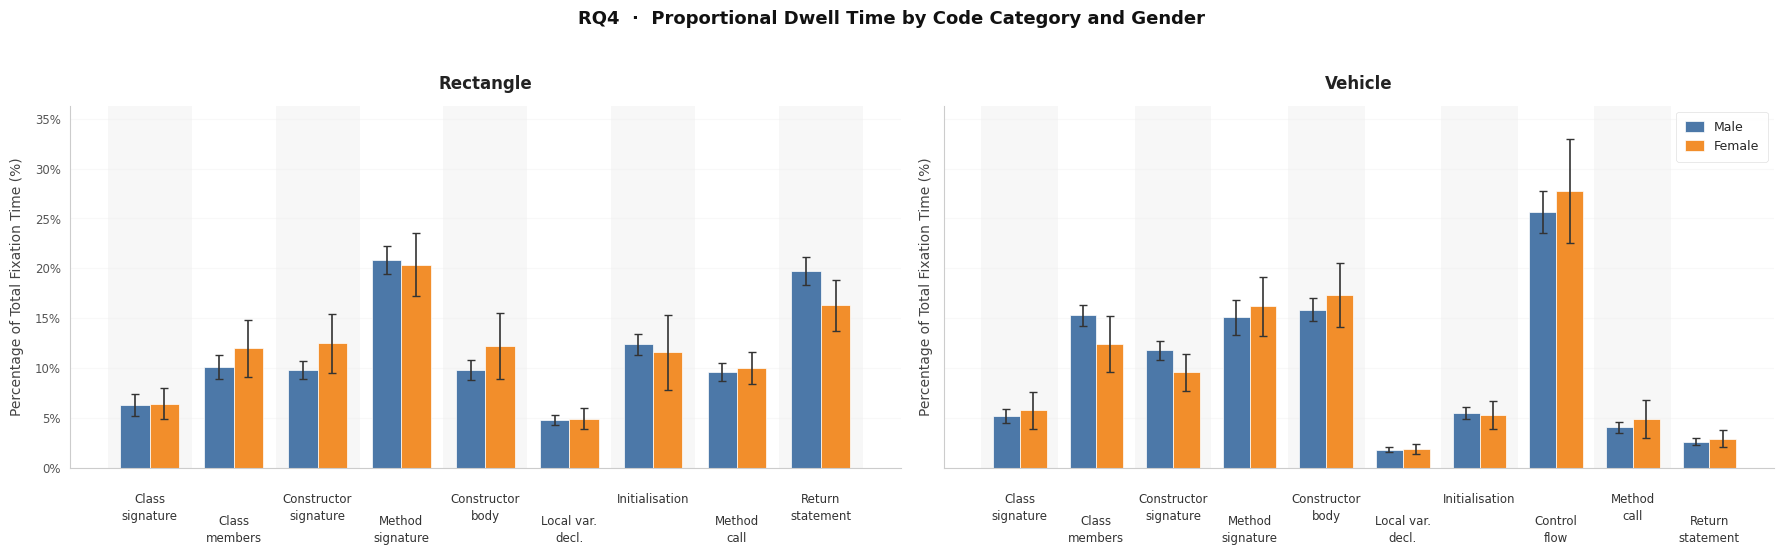

In [117]:
# Plot prop_dwell_time
fig1 = plot_proportional_metric(
    category_metrics,
    'prop_dwell_time',
    'Proportional Dwell Time',
    'Percentage of Total Fixation Time (%)'
)
plt.savefig('rq4_prop_dwell_time.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()



*Caption - Proportional dwell time by functional code category and gender*

Bars represent the mean percentage of total fixation time allocated to each functional code category, computed separately for male and female participants within each task. Proportional dwell time was calculated for each participant as the dwell time on a given category divided by the total dwell time on the stimulus, then converted to a percentage for interpretability. Error bars indicate ±1.96 standard errors of the mean (SEM) and are included for visual comparison only; formal statistical inference is reported separately using mixed-effects models.

*Interpretation*

The figure shows how participants distributed their visual attention across functional code categories, expressed as the mean proportion of total fixation time devoted to each category. Across both tasks, attention was not evenly distributed across the code. Instead, participants concentrated a relatively large share of their total viewing time on selected categories, particularly method-level structures. In the Rectangle task, the highest proportional dwell times were observed for method signatures and return statements, whereas in the Vehicle task, the largest share of attention was directed to control flow, followed by constructor body, class members, and method signatures. In contrast, categories such as local variable declarations, class signatures, and some method calls received comparatively little attention.

The overall pattern is broadly similar for male and female participants, suggesting that both groups allocated attention to the same major structural and functional regions of the code. Although modest differences are visible in some categories—for example, females appear to allocate slightly more attention to constructor-related elements in some cases, while males appear to allocate somewhat more attention to return statements in the Rectangle task—these differences are generally small relative to the overall distribution of attention and should be interpreted cautiously. The figure therefore suggests that, at the descriptive level, gender differences in code comprehension are not accompanied by large differences in where visual attention is allocated across code categories.

Importantly, proportional dwell time reflects how much attention was allocated to a category, not when that category was first inspected.

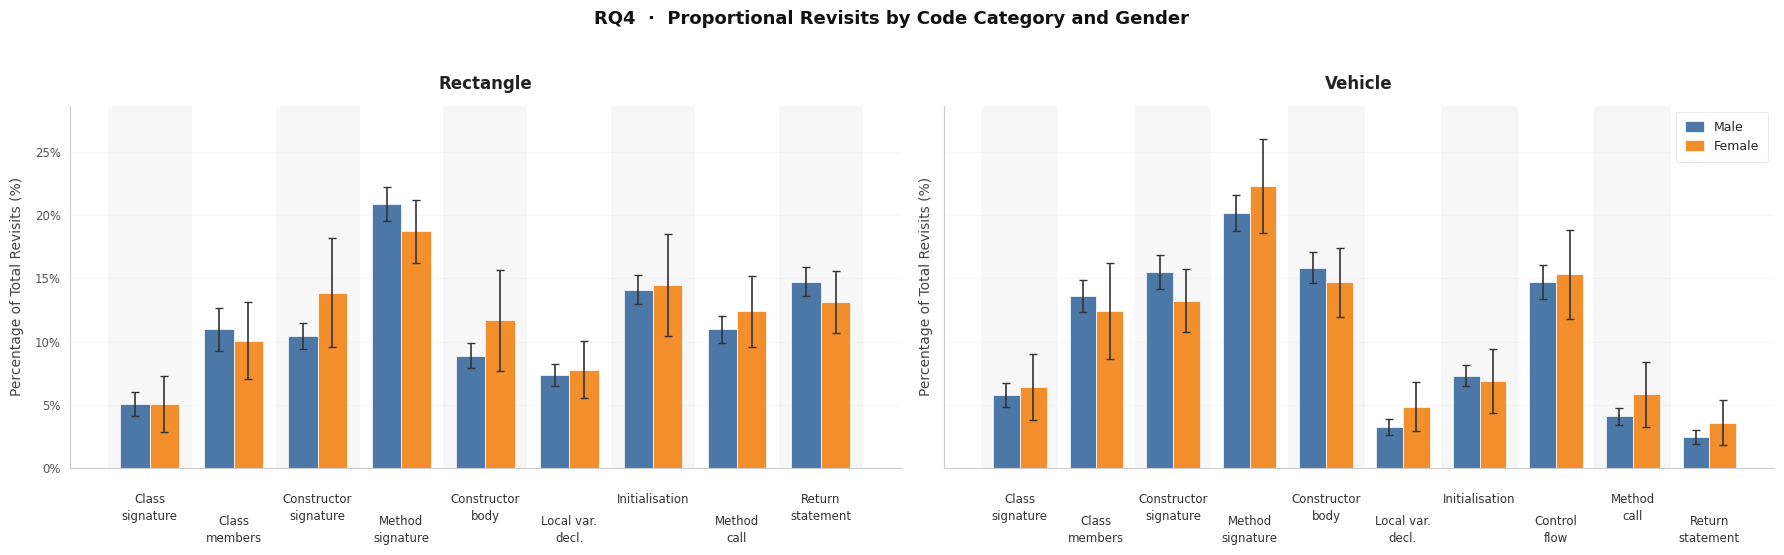

In [118]:
# Plot prop_revisits
fig2 = plot_proportional_metric(
    category_metrics,
    'prop_revisits',
    'Proportional Revisits',
    'Percentage of Total Revisits (%)'
)
plt.savefig('rq4_prop_revisits.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

*Caption -  Proportional revisits by functional code category and gender*

Bars represent the mean percentage of total revisits directed to each code category, computed separately for male and female participants within each task. Proportional revisits were calculated as the number of revisits to a given category divided by the total number of revisits on the stimulus. Error bars indicate ±1.96 standard errors of the mean (SEM) and are provided for visual comparison only; statistical inference is reported using mixed-effects models.

*Interpretation*

Proportional revisits provide insight into where participants re-engaged with the code, reflecting regions that required additional processing, verification, or integration. Across both tasks, revisits were concentrated in a subset of categories, particularly method-level structures. In the Rectangle task, the highest proportion of revisits was observed for method signatures, followed by initialisation and return statements, indicating that participants frequently returned to these elements during comprehension. In the Vehicle task, revisits were most strongly concentrated on method signatures and control flow, suggesting that these regions required repeated inspection to understand program behaviour.

Compared to categories such as class signatures and local variable declarations, which received relatively few revisits, these high-revisit regions likely represent points of increased cognitive demand, where participants needed to verify assumptions or integrate information across different parts of the code.

Gender differences in proportional revisits were generally modest and consistent across tasks. While some categories show slightly higher revisit proportions for female participants (e.g., constructor signature and method signature in the Vehicle task), these differences are small relative to the overall distribution and are accompanied by overlapping uncertainty intervals. Overall, the results suggest that both male and female participants exhibit similar patterns of reprocessing behaviour, revisiting the same structurally and semantically important regions of the code.

In [119]:
# ─────────────────────────────────────────────────
# 2. DOT PLOT WITH ERROR BARS FOR DENSITY METRICS
# ─────────────────────────────────────────────────

def plot_density_metric(df, metric_col, metric_title, ylabel):
    """
    Create dot plot with error bars for density metrics.
    Cleaner than bars for continuous measures.
    """
    fig, axes = plt.subplots(1, len(task_ids), figsize=(9 * len(task_ids), 5.5), sharey=False)
    if len(task_ids) == 1:
        axes = [axes]

    for col_idx, task_id in enumerate(task_ids):
        ax = axes[col_idx]
        task_df = df[df['task'] == task_id]
        task_cats = [c for c in ALL_CAT_ORDER if c in task_df['line_category'].unique()]

        # Calculate statistics
        plot_data = task_df.groupby(['line_category', 'gender'])[metric_col].agg(['mean', 'sem']).reset_index()

        # Plot with offset for gender
        x = np.arange(len(task_cats))
        offset = 0.12

        for gender_val, shift, marker in [('male', -offset, 'o'), ('female', offset, 's')]:
            gender_data = plot_data[plot_data['gender'] == gender_val].set_index('line_category').reindex(task_cats)

            ax.errorbar(
                x=x + shift,
                y=gender_data['mean'],
                yerr=gender_data['sem'] * 1.96,  # 95% CI
                fmt=marker,
                color=colors[gender_val],
                label=gender_val.capitalize(),
                markersize=10,
                capsize=4,
                linewidth=1.5,
                elinewidth=1.5,
                markeredgewidth=1.5,
                markeredgecolor='white',
                ecolor='#333333',
                zorder=3
            )

        # Styling
        ax.set_title(task_names[task_id], fontsize=12, fontweight='semibold',
                    color='#222222', pad=12)
        ax.set_ylabel(ylabel, fontsize=10, color='#444444', labelpad=8)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f'{x:,.0f}' if abs(x) >= 100 else f'{x:.2f}'.rstrip('0').rstrip('.')
        ))
        ax.tick_params(axis='y', labelsize=8.5, labelcolor='#555555')
        ax.grid(True, axis='y', zorder=0, alpha=0.4)
        ax.set_axisbelow(True)
        ax.set_xlim(-0.6, len(task_cats) - 0.4)

        add_category_labels(ax, task_cats)
        add_alternating_background(ax, len(task_cats))
        style_legend(ax, show_legend=(col_idx == len(task_ids) - 1))

    fig.suptitle(
        f'RQ4  ·  {metric_title} by Code Category and Gender',
        fontsize=13, fontweight='bold', color='#111111', y=1.02
    )
    plt.tight_layout()

    return fig

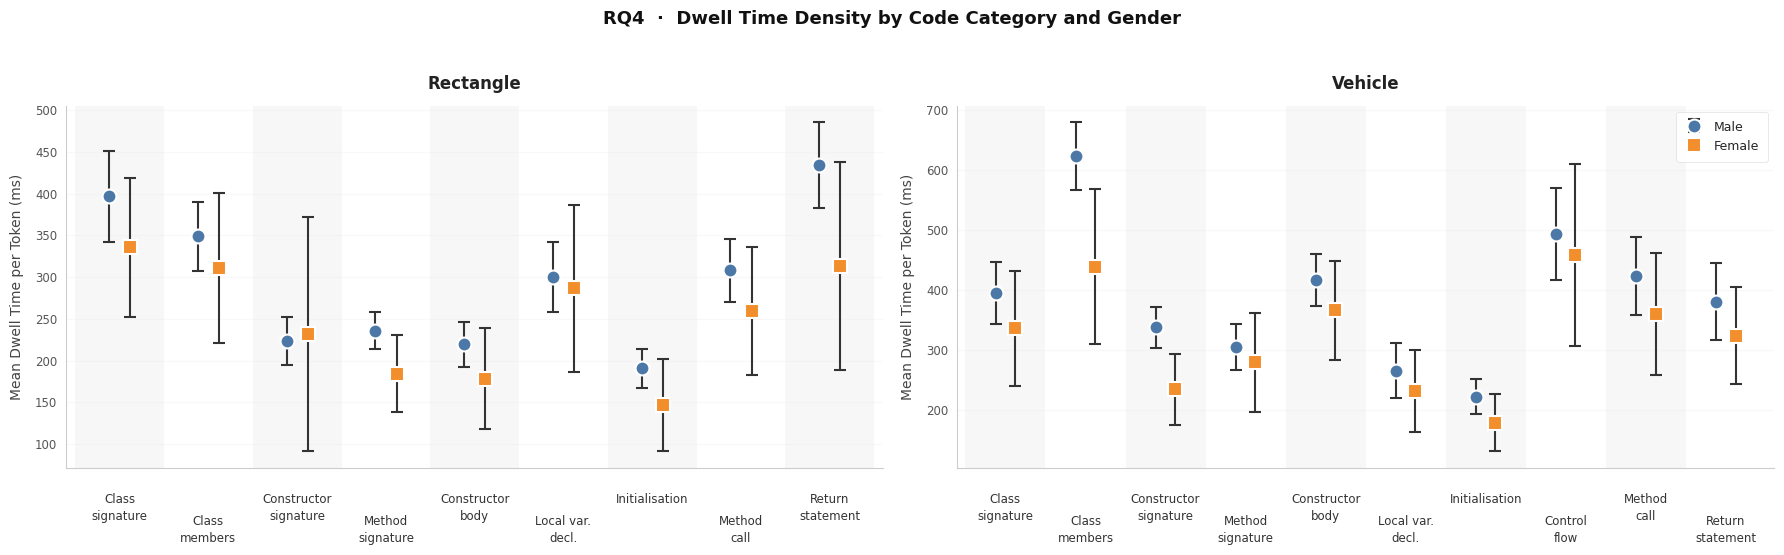

In [120]:
# Plot dwell_time_density
fig3 = plot_density_metric(
    category_metrics,
    'dwell_time_density',
    'Dwell Time Density',
    'Mean Dwell Time per Token (ms)'
)
#plt.savefig('rq4_dwell_time_density.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

*Caption -  Dwell time density by functional code category and gender.*

Points represent the mean dwell time per token (ms) for each code category, computed separately for male and female participants within each task. Dwell time density was calculated as total dwell time on a category divided by the number of tokens within that category, reflecting processing time per unit of code. Error bars indicate ±1.96 standard errors of the mean (SEM) and are provided for visual comparison only; statistical inference is reported using mixed-effects models.

*Interpretation*

Dwell time density provides a measure of processing intensity, indicating how much time participants spent on each unit of code within a category. Across both tasks, substantial variation is observed across categories, suggesting that some regions of the code required more effortful processing than others. In particular, categories such as control flow (in the Vehicle task) and return statements show relatively high dwell time density, indicating that these elements were processed more intensively on a per-token basis. In contrast, categories such as initialisation and constructor body exhibit lower dwell time density, suggesting more rapid processing.

Importantly, these patterns differ from those observed in proportional dwell time, indicating that categories receiving the most overall attention are not necessarily those requiring the greatest processing effort per unit. This highlights the distinction between attention allocation and processing intensity in code comprehension.

Gender differences in dwell time density are generally modest, with both groups exhibiting similar patterns across categories. While some categories show slightly higher processing intensity for one group, these differences are small relative to the overall variation across code structures, suggesting that male and female participants engage with code at a similar level of processing intensity.

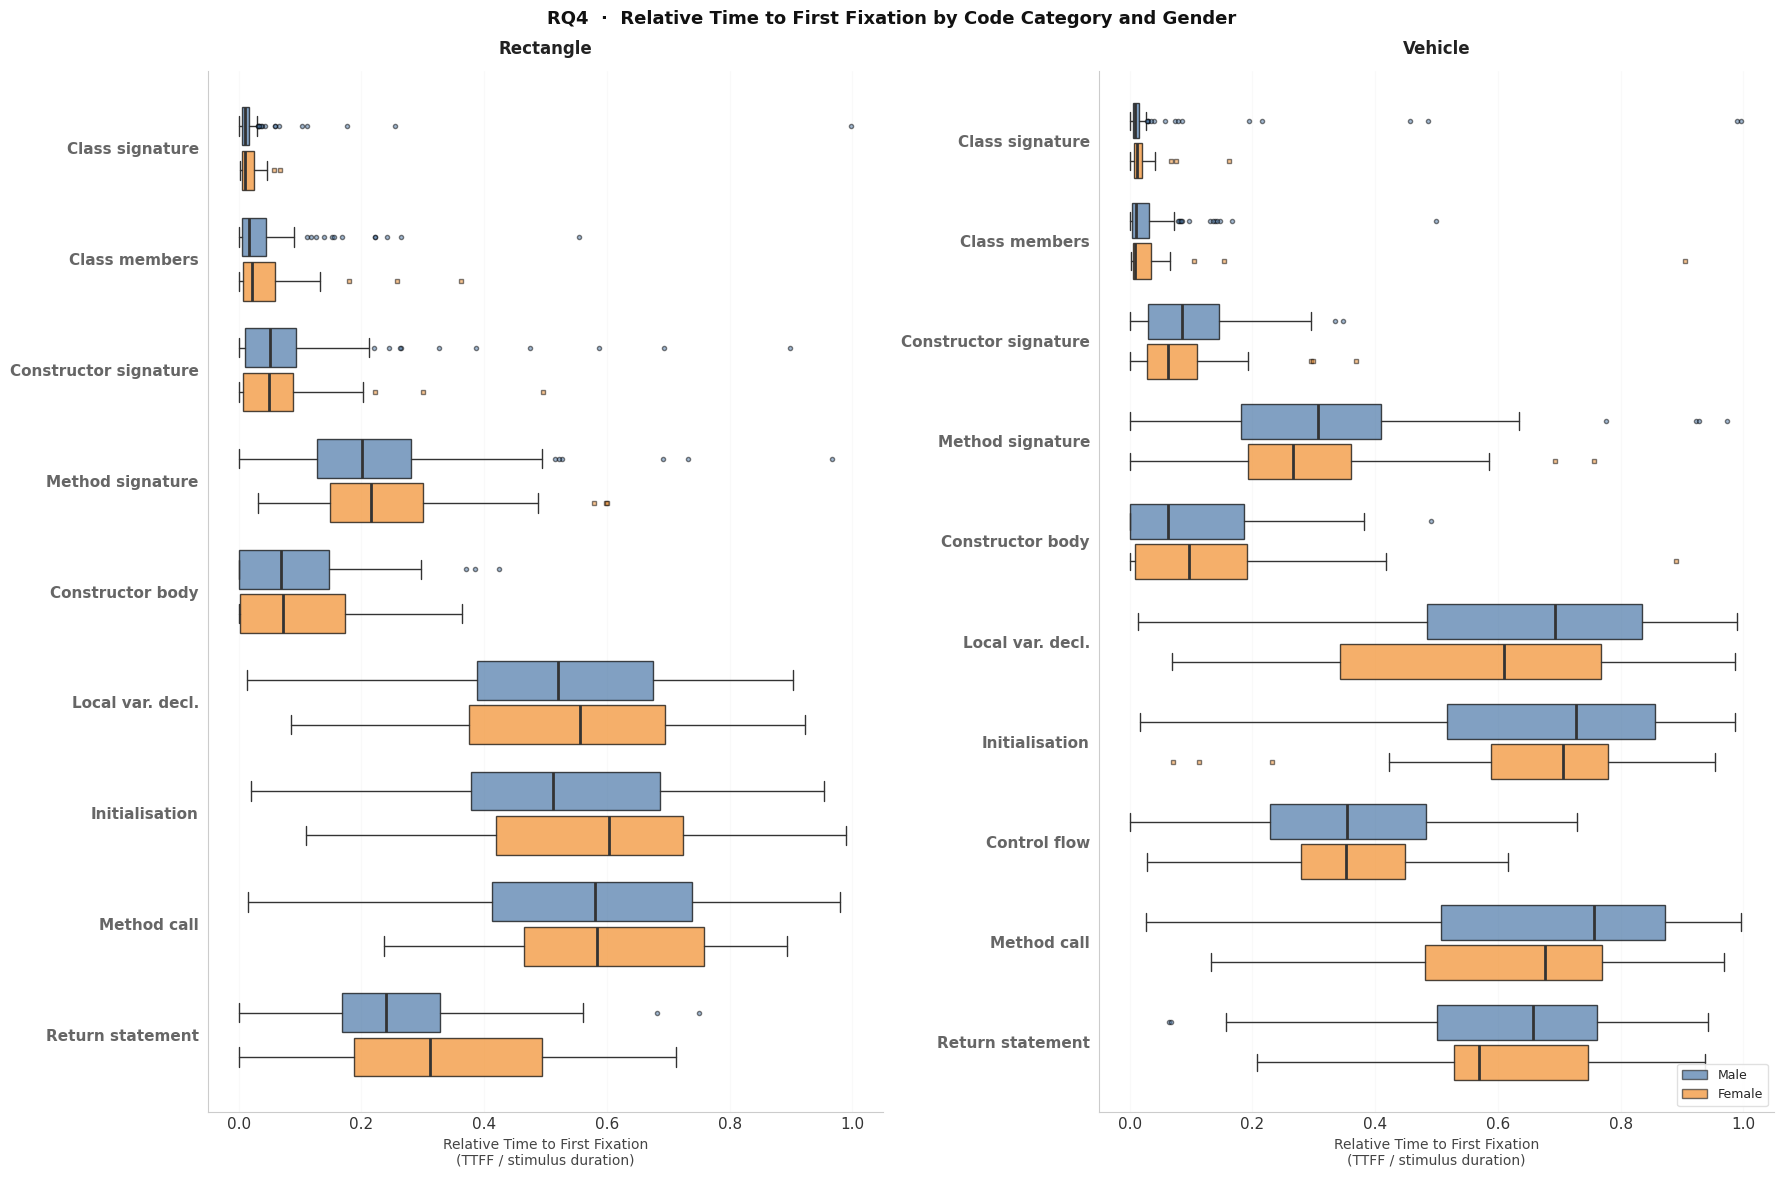

In [121]:
def plot_ttff_horizontal_boxplot(df, metric_col='ttff_relative'):
    """
    Horizontal box plot for TTFF - better for showing early-fixation compression.
    """
    fig, axes = plt.subplots(1, len(task_ids), figsize=(18, 12), sharey=False)
    if len(task_ids) == 1:
        axes = [axes]

    for col_idx, task_id in enumerate(task_ids):
        ax = axes[col_idx]
        task_df = df[df['task'] == task_id].copy()
        task_cats = [c for c in ALL_CAT_ORDER if c in task_df['line_category'].unique()]

        # Prepare data
        plot_df = task_df[task_df['line_category'].isin(task_cats)].copy()
        plot_df['line_category'] = pd.Categorical(plot_df['line_category'],
                                                   categories=task_cats, ordered=True)

        # Create positions for box plots (reversed for top-to-bottom reading)
        positions = np.arange(len(task_cats))[::-1]

        # Separate data by gender
        male_data = [plot_df[(plot_df['line_category'] == cat) &
                             (plot_df['gender'] == 'male')][metric_col].values
                     for cat in task_cats]
        female_data = [plot_df[(plot_df['line_category'] == cat) &
                               (plot_df['gender'] == 'female')][metric_col].values
                       for cat in task_cats]

        # Plot box plots with offset
        offset = 0.2
        bp1 = ax.boxplot(male_data, positions=positions + offset,
                         vert=False, widths=0.35,
                         patch_artist=True,
                         boxprops=dict(facecolor=colors['male'], alpha=0.7, linewidth=1),
                         medianprops=dict(color='#333333', linewidth=2),
                         whiskerprops=dict(color='#333333', linewidth=1),
                         capprops=dict(color='#333333', linewidth=1),
                         flierprops=dict(marker='o', markerfacecolor=colors['male'],
                                       markersize=3, alpha=0.5))

        bp2 = ax.boxplot(female_data, positions=positions - offset,
                         vert=False, widths=0.35,
                         patch_artist=True,
                         boxprops=dict(facecolor=colors['female'], alpha=0.7, linewidth=1),
                         medianprops=dict(color='#333333', linewidth=2),
                         whiskerprops=dict(color='#333333', linewidth=1),
                         capprops=dict(color='#333333', linewidth=1),
                         flierprops=dict(marker='s', markerfacecolor=colors['female'],
                                       markersize=3, alpha=0.5))

        # Styling
        ax.set_yticks(positions)
        ax.set_yticklabels([ALL_CAT_LABELS[c].replace('\n', ' ') for c in task_cats],
                          fontsize=11,fontweight='semibold' )
        ax.set_xlabel('Relative Time to First Fixation\n(TTFF / stimulus duration)',
                     fontsize=10, color='#444444')
        ax.set_title(task_names[task_id], fontsize=12, fontweight='semibold',
                    color='#222222', pad=12)
        ax.set_xlim(-0.05, 1.05)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}'))
        ax.grid(True, axis='x', alpha=0.3, zorder=0)
        ax.set_axisbelow(True)

        # Add legend
        if col_idx == len(task_ids) - 1:
            from matplotlib.patches import Patch
            legend_elements = [
                Patch(facecolor=colors['male'], edgecolor='#333333',
                     label='Male', alpha=0.7),
                Patch(facecolor=colors['female'], edgecolor='#333333',
                     label='Female', alpha=0.7)
            ]
            ax.legend(handles=legend_elements, fontsize=9, framealpha=0.9,
                     edgecolor='#dddddd', loc='lower right')


    fig.suptitle('RQ4  ·  Relative Time to First Fixation by Code Category and Gender',
                fontsize=13, fontweight='bold', color='#111111', y=0.98)
    plt.tight_layout()

    return fig

# Generate plot
fig_ttff_box = plot_ttff_horizontal_boxplot(category_metrics)
plt.savefig('rq4_ttff_relative_boxplot.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

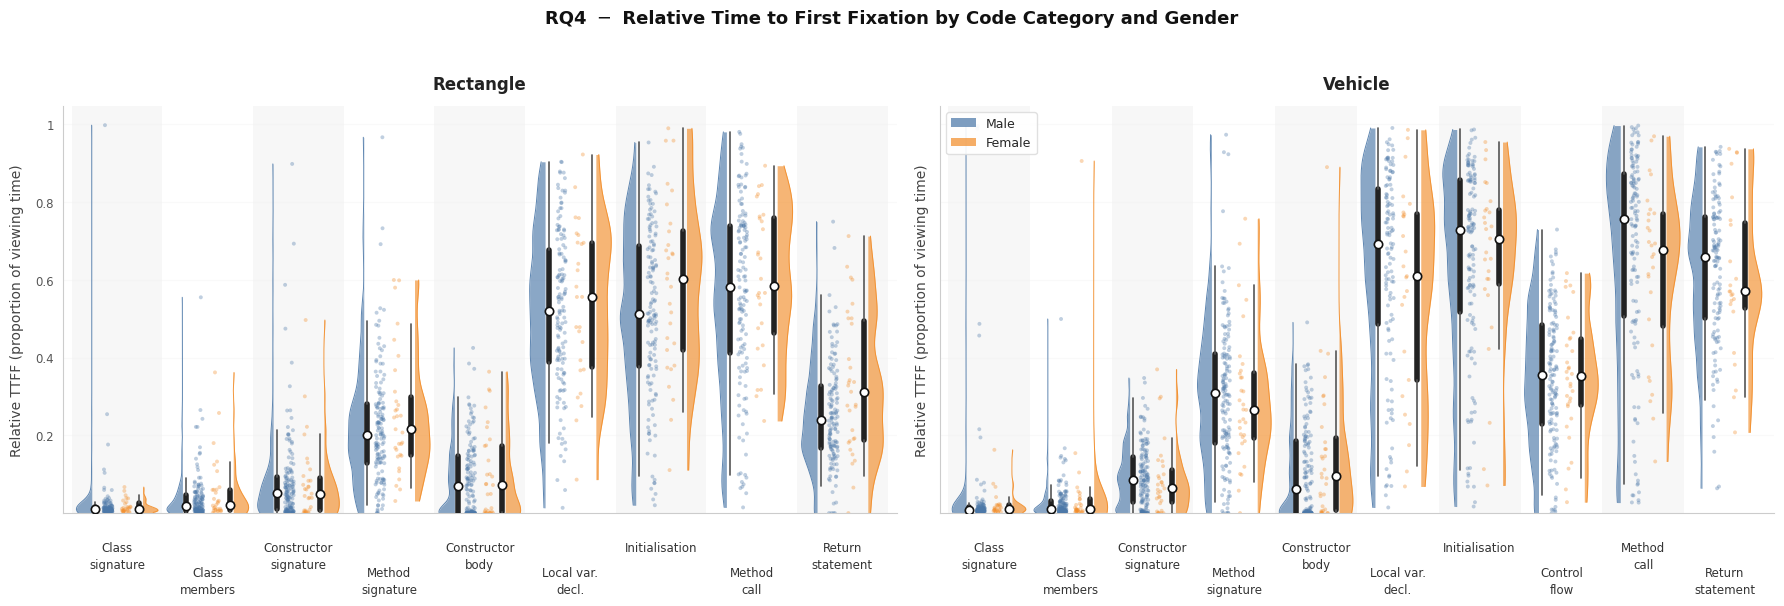

In [122]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from scipy.stats import gaussian_kde


# ─────────────────────────────────────────────────
# Raincloud plot for temporal metrics
# ─────────────────────────────────────────────────

def plot_temporal_metric_raincloud(df, metric_col, metric_title, ylabel,
                                   small_n_threshold=5):
    """
    Raincloud plot for temporal metrics.
      - Half-violin  : distribution shape (log-space KDE, per-category clipped)
      - Box plot     : IQR + whiskers + median dot
      - Strip        : jittered raw observations (separated from violin body)
      - Outliers     : diamond markers above clip_percentile threshold
    Log-scaled y-axis throughout.
    """
    VWIDTH  = 0.17   # half-violin max width (narrower ─> less inter-gender overlap)
    SPACING = 0.28   # x-offset of each gender from category centre

    fig, axes = plt.subplots(
        1, len(task_ids),
        figsize=(9 * len(task_ids), 6),
        sharey=True
    )
    if len(task_ids) == 1:
        axes = [axes]

    all_vals  = df[df[metric_col] >= 0][metric_col]

    y_floor   = max(all_vals.min() * 0.5, 1e-5)

    for col_idx, task_id in enumerate(task_ids):
        ax = axes[col_idx]
        task_df = df[(df['task'] == task_id) & (df[metric_col] >= 0)].copy()
        task_cats = [c for c in ALL_CAT_ORDER if c in task_df['line_category'].unique()]

        plot_df = task_df[task_df['line_category'].isin(task_cats)].copy()
        plot_df['line_category'] = pd.Categorical(
            plot_df['line_category'], categories=task_cats, ordered=True
        )

        for gender, side, color in [
            ('male',   -1, colors['male']),    # left of centre
            ('female', +1, colors['female']),  # right of centre
        ]:
            for i, cat in enumerate(task_cats):
                vals = plot_df[
                    (plot_df['line_category'] == cat) &
                    (plot_df['gender'] == gender)
                ][metric_col].values

                if len(vals) == 0:
                    continue

                cx       = i + side * SPACING
                body     = vals
                outliers = np.array([]) # No outliers when no clipping
                n        = len(vals)

                # ── Half violin ────────────────────
                if len(body) >= 3:
                    # log_body = np.log10(body) # REMOVED

                    # FIX 1: adaptive bandwidth ─ tighter when n is small
                    bw = max(0.2, min(0.4, 0.4 * (10 / len(body)) ** 0.3))
                    kde = gaussian_kde(body, bw_method=bw)

                    # FIX 2: clip y_range to true data bounds, no artefact bleed
                    y_range = np.linspace(
                        max(body.min(), y_floor),
                        body.max(),
                        200
                    )
                    density = kde(y_range)
                    density = density / density.max() * VWIDTH

                    y_vals = y_range
                    ax.fill_betweenx(
                        y_vals,
                        cx,
                        cx + side * density,
                        color=color, alpha=0.65, linewidth=0
                    )
                    ax.plot(
                        cx + side * density, y_vals,
                        color=color, linewidth=0.7, alpha=0.9
                    )

                # ── Box plot (manual, log-safe) ────────────────────────────────
                if len(body) >= 2:
                    q25, q50, q75 = np.percentile(body, [25, 50, 75])
                    iqr  = q75 - q25
                    #w_lo = body[body >= q25 - 1.5 * iqr].min()

                    #w_hi = body[body <= q75 + 1.5 * iqr].max()

                    # In the box plot block, replace the whisker calculation:

                    w_lo = max(body[body >= q25 - 1.5 * iqr].min(), np.percentile(body, 5))    # ─ clip lower whisker at p5
                    w_hi = body[body <= q75 + 1.5 * iqr].max()
                    bx   = cx - side * 0.04   # nudge box toward centre

                    # IQR bar
                    ax.plot([bx, bx], [q25, q75],
                            color='#222222', linewidth=4,
                            solid_capstyle='round', zorder=5)
                    # Whiskers
                    ax.plot([bx, bx], [w_lo, q25],
                            color='#555555', linewidth=1.2, zorder=5)
                    ax.plot([bx, bx], [q75, w_hi],
                            color='#555555', linewidth=1.2, zorder=5)
                    # Median dot
                    ax.scatter([bx], [q50],
                               color='white', edgecolors='#111111',
                               linewidths=1.2, s=36, zorder=6)

                # ── Jittered strip ──────────────────────────────────
                # FIX 3: strip nudged further from violin so layers don't overlap
                np.random.seed(42)
                jitter  = np.random.uniform(-0.05, 0.05, size=len(body))
                strip_x = cx - side * 0.18 + jitter   # was 0.12
                ax.scatter(strip_x, body,
                           color=color, edgecolors='none',
                           s=8, alpha=0.35, zorder=4)

                # ── Outlier diamonds ─────────────────────────────────
                # Removed outlier plotting as there's no clipping

                # ── Small-n annotation ─────────────────────
                if n < small_n_threshold:
                    ax.text(cx, y_floor, f'n={n}',
                            fontsize=6, color='#aaaaaa',
                            ha='center', va='bottom')

        # ── Clip threshold line ───────────────────────────
        # Removed clip threshold line and text

        # ── Log scale ─────────────────────────
        # ax.set_yscale('log') # REMOVED
        ax.set_ylim(bottom=y_floor)
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{x:.2f}'.rstrip('0').rstrip('.'))
        )
        ax.yaxis.set_minor_formatter(mticker.NullFormatter())

        # ── Styling ─────────────────────────
        ax.set_title(task_names[task_id], fontsize=12,
                     fontweight='bold', color='#222222', pad=12)
        ax.set_ylabel(ylabel, fontsize=10, color='#444444', labelpad=8)
        ax.tick_params(axis='y', labelsize=8.5, labelcolor='#555555')
        ax.grid(True, axis='y', alpha=0.3, which='major', zorder=0)
        ax.set_axisbelow(True)
        ax.set_xlim(-0.6, len(task_cats) - 0.4)

        add_category_labels(ax, task_cats)
        add_alternating_background(ax, len(task_cats))

        if col_idx == len(task_ids) - 1:
            legend_elements = [
                Patch(facecolor=colors['male'],   edgecolor='none',
                      label='Male',   alpha=0.72),
                Patch(facecolor=colors['female'], edgecolor='none',
                      label='Female', alpha=0.72),
            ]
            ax.legend(handles=legend_elements, fontsize=9,
                      framealpha=0.9, edgecolor='#dddddd', loc='upper left')

    fig.suptitle(
        f'RQ4  ─  {metric_title} by Code Category and Gender',
        fontsize=13, fontweight='bold', color='#111111', y=1.02
    )
    plt.tight_layout()
    return fig


# ─────────────────────────────────────────────────
# Usage
# ─────────────────────────────────────────────────
fig4 = plot_temporal_metric_raincloud(
    category_metrics,
    'ttff_relative',
    'Relative Time to First Fixation',
    'Relative TTFF (proportion of viewing time)',

    small_n_threshold=5
)
# plt.savefig('rq4_ttff_relative.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

*Caption Relative Time to First Fixation (TTFF) by code category and gender for Rectangle and Vehicle tasks.*

Relative TTFF is computed as the time to first fixation on a code element divided by total stimulus viewing duration, producing values between 0 (very early fixation) and 1 (very late fixation). Violin plots show the distribution of values, boxplots indicate the median and interquartile range, and individual points represent observations. Lower values indicate earlier attention, while higher values indicate later inspection.

*Interpretation*

Consistent with the horizontal boxplot visualization, this figure confirms a clear and robust temporal ordering of attention across code categories. Early-stage elements such as class signature, class members, and constructor signature show very low relative TTFF values, while later-stage elements such as initialisation, method calls, and return statements are fixated much later. This reinforces the same structural-to-logical progression observed in the boxplots, but here the full distributions make the progression more continuous and gradual rather than discretely separated.

Compared to the boxplots, the violin representation highlights the density and spread of the data, showing that although medians differ across categories, there is substantial overlap between adjacent categories. This indicates that while the overall ordering is consistent, participants do not follow a strictly sequential pattern—there is variability in when specific elements are first attended.

The Vehicle task again exhibits slightly higher TTFF values for several categories relative to the Rectangle task, aligning with the boxplot interpretation that attention to key elements is somewhat delayed in the more complex task.

In terms of gender differences, both plots tell the same story: distributions for male and female participants largely overlap, with only minor and inconsistent shifts in medians. The violin plot makes this especially clear by showing similar density shapes across genders, reinforcing the conclusion from the boxplots that there is no meaningful gender-based difference in the timing of first fixations.

Overall, while the boxplots provide a clearer summary of central tendency and spread, this figure complements them by revealing the underlying distributional structure, confirming that the observed patterns are not driven by a small number of values but reflect broader trends across participants.

*Caption - Relative time to first fixation (TTFF) by functional code category and gender.*

Horizontal boxplots show the distribution of relative time to first fixation for each functional code category, separately for male and female participants in the Rectangle and Vehicle tasks. Relative TTFF is defined as the time from stimulus onset to the first fixation on a category, divided by the total viewing duration of the stimulus. Lower values indicate earlier first access in the viewing sequence, while higher values indicate later access. Boxes represent the interquartile range (IQR), the central line indicates the median, whiskers extend to 1.5×IQR, and points denote outliers. Categories not present in a given task (e.g., control flow in the Rectangle task) are shown as blank.


*Interpretation*


Across both tasks, high-level structural elements, such as class signatures, class members, and constructor signatures, were fixated earliest, as indicated by median relative TTFF values close to zero. This suggests that participants initially orient themselves using structural cues before engaging with more detailed aspects of the code.

In contrast, implementation-related and execution-relevant categories,such as local variable declarations, initialisation, method calls, and return statements, were typically accessed later in the viewing sequence. These categories show higher median relative TTFF values and broader distributions, indicating that they are processed after initial structural comprehension, and with greater variability across participants.

The overall ordering of categories is largely consistent between the Rectangle and Vehicle tasks, suggesting a stable reading strategy that generalises across different code contexts. While some differences in spread and median values are observable between male and female participants, the substantial overlap in distributions indicates that both groups follow a broadly similar temporal pattern of attention allocation. Any gender-related differences in the timing of first fixation appear to be subtle and category-specific rather than indicative of fundamentally different reading orders.

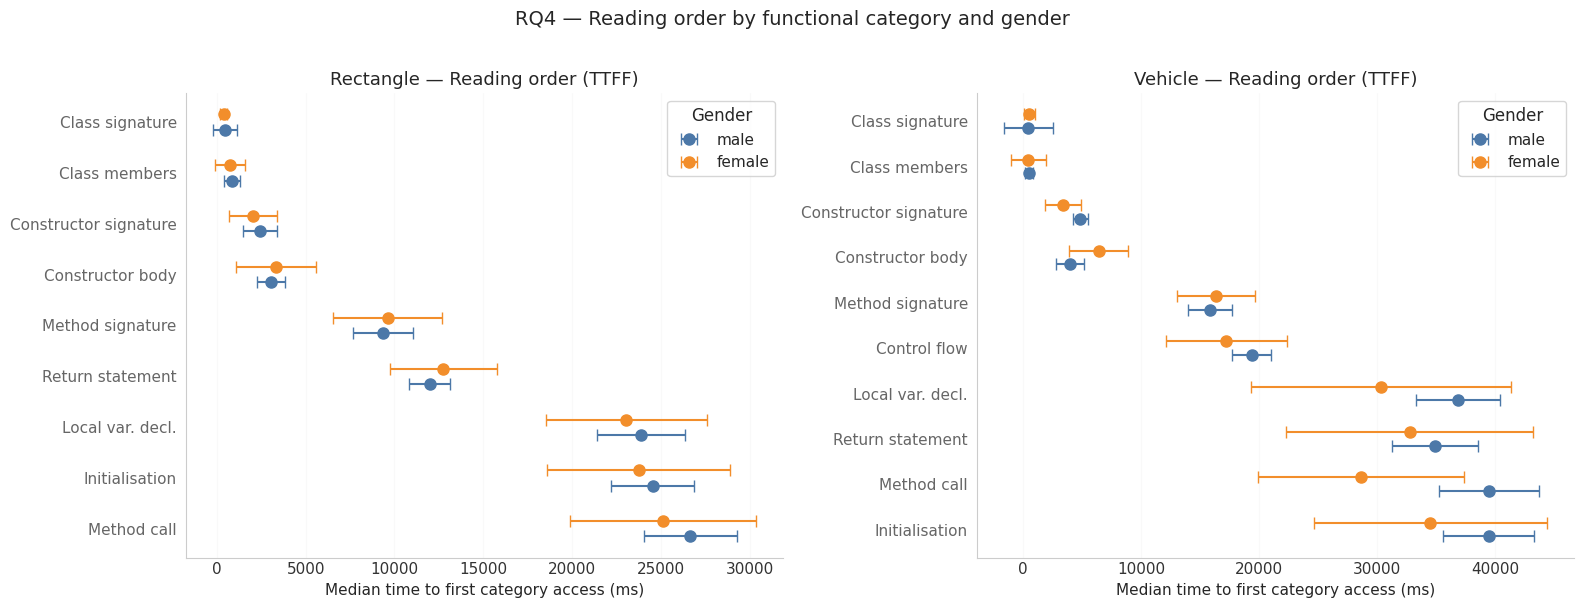

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cat_order = ['class_signature', 'class_members', 'constructor_signature', 'method_signature', 'constructor_body', 'local_var_decl', 'method_init', 'control_flow', 'method_call', 'return_stmt']
cat_labels = {
    'class_signature': 'Class signature',
    'class_members': 'Class members',
    'constructor_signature': 'Constructor signature',
    'method_signature': 'Method signature',
    'constructor_body': 'Constructor body',
    'local_var_decl': 'Local var. decl.',
    'method_init': 'Initialisation',
    'control_flow': 'Control flow',
    'method_call': 'Method call',
    'return_stmt': 'Return statement'
}



# ── Plot Horizontal dot plot for TTFF reading order ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

for ax, task_name in zip(axes, ['rectangle', 'vehicle']):
    task_data = category_metrics[category_metrics['task'] == task_name].copy()

    # Compute median TTFF and CI per category per gender
    ttff_summary = (
        task_data.groupby(['line_category', 'gender'])['ttff_ms']
        .agg(['median', 'sem'])
        .reset_index()
    )
    ttff_summary.columns = ['line_category', 'gender', 'median_ttff', 'sem']
    ttff_summary['ci95'] = ttff_summary['sem'] * 1.96

    # Order categories by overall median TTFF — reveals reading order
    cat_order_ttff = (
        ttff_summary.groupby('line_category')['median_ttff']
        .mean()
        .sort_values()
        .index.tolist()
    )

    for i, cat in enumerate(cat_order_ttff):
        for j, gender in enumerate(['male', 'female']):
            row = ttff_summary[
                (ttff_summary['line_category'] == cat) &
                (ttff_summary['gender'] == gender)
            ]
            if len(row) == 0:
                continue

            offset = 0.15 if gender == 'male' else -0.15
            ax.errorbar(
                x=row['median_ttff'].values[0],
                y=i + offset,
                xerr=row['ci95'].values[0],
                fmt='o',
                color=colors[gender],
                markersize=8,
                capsize=4,
                label=gender if i == 0 else '_nolegend_'
            )

    ax.set_yticks(range(len(cat_order_ttff)))
    ax.set_yticklabels([cat_labels[c] for c in cat_order_ttff], fontsize=11)
    ax.set_title(f'{task_name.capitalize()} — Reading order (TTFF)',
                 fontsize=13)
    ax.set_xlabel('Median time to first category access (ms)', fontsize=11)
    ax.legend(title='Gender')
    ax.grid(True, alpha=0.3, axis='x')
    ax.invert_yaxis()

plt.suptitle('RQ4 — Reading order by functional category and gender',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('rq4_ttff.png', dpi=150, bbox_inches='tight')
plt.show()


*Caption*

Reading order by functional code category and gender, based on median time to first fixation (TTFF) in milliseconds, for the Rectangle and Vehicle tasks.
Points represent median TTFF for each category, with horizontal error bars indicating variability (interquartile range or confidence intervals). Categories are ordered vertically to reflect conceptual program structure. Lower values (left) indicate earlier attention, while higher values (right) indicate later access during code comprehension.


*Interpretation*

This figure provides a representation of reading order, showing the sequence in which participants first attend to different functional code categories. Across both the Rectangle and Vehicle tasks, a consistent progression is observed: participants initially fixate on high-level structural elements (e.g., class signature and class members), followed by constructor-related components, then method definitions, and finally execution-related elements such as local variables, method calls, and return statements.

Across both tasks, the TTFF profiles reveal a reading order in which participants tend to fixate high-level structural elements earlier and lower-level implementation details later. In both the Rectangle and Vehicle tasks, class signature, class members, and constructor signature are among the earliest fixated categories, indicating that participants first orient to the overall class structure before progressing to executable content. In contrast, categories such as method calls, initialisation, and return statements are fixated later, suggesting that these elements are processed after an initial structural overview has been established.

Compared to the horizontal boxplots, which display the full distribution of relative TTFF values, this figure emphasises central tendency and temporal sequencing rather than variability. While the boxplots reveal substantial spread and overlap within categories, highlighting individual differences and skewed distributions,this plot aims at making the ordering of attention easily interpretable.

Gender differences in TTFF are modest and largely parallel across categories. In most cases, male and female medians follow the same ordering, with only small shifts in absolute timing. For some later-accessed categories (e.g., method call and initialisation), females appear to fixate slightly later than males; however, these differences are accompanied by overlapping uncertainty intervals and should be interpreted cautiously. Importantly, because raw TTFF (in milliseconds) is influenced by overall viewing duration, these descriptive differences do not by themselves indicate differences in attentional priority.

Gender differences appear primarily as small horizontal offsets, indicating that both groups follow a similar reading strategy. Additionally, the Vehicle task exhibits generally longer TTFF values and greater variability, suggesting increased complexity and delayed access to key elements compared to the Rectangle task. However, the underlying ordering remains stable across tasks.



# Attention Maps

/tmp/ipykernel_14245/3390762623.py:363: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



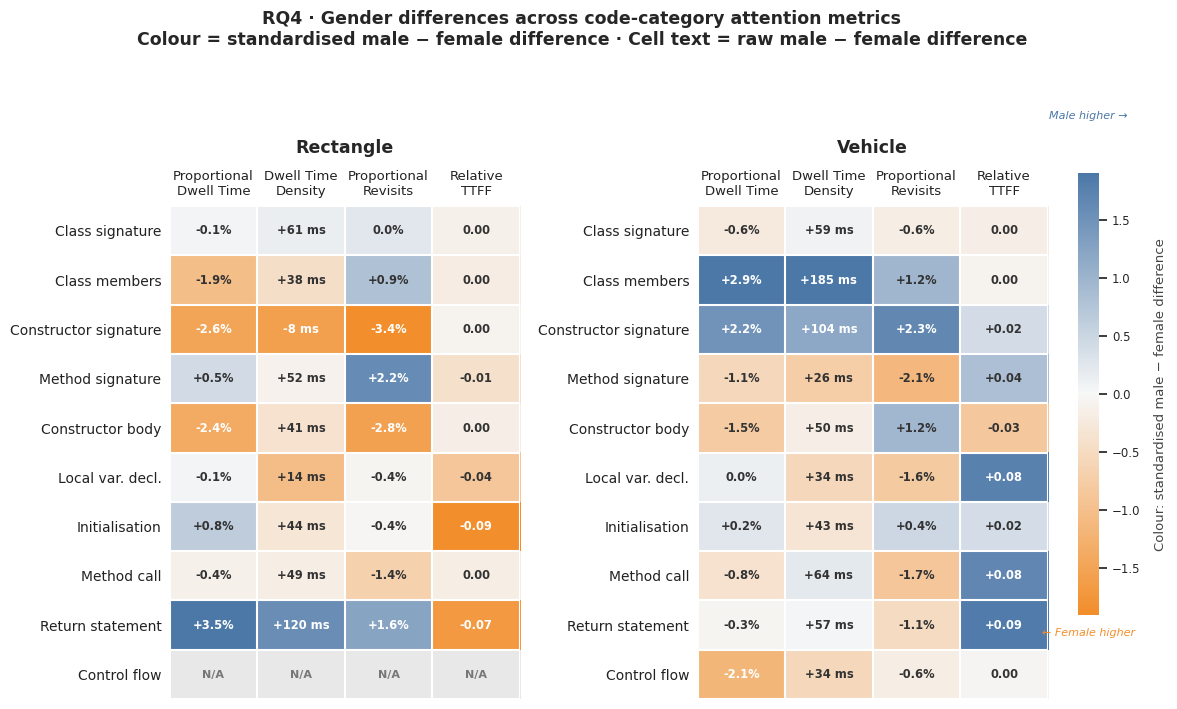

In [124]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
import pandas as pd

# ── Style ─────────────────────────────────────────────────────────────────────
sns.set_theme(style='white', font_scale=1.0)
plt.rcParams.update({'font.family': 'sans-serif'})

# ── Gender colours ────────────────────────────────────────────────────────────
colors = {
    'male': '#4C78A8',
    'female': '#F28E2B'
}

# ── Config ────────────────────────────────────────────────────────────────────
ALL_CAT_ORDER = [
    'class_signature',
    'class_members',
    'constructor_signature',
    'method_signature',
    'constructor_body',
    'local_var_decl',
    'method_init',
    'method_call',
    'return_stmt',
    'control_flow'
]

CAT_LABELS = {
    'class_signature': 'Class signature',
    'class_members': 'Class members',
    'constructor_signature': 'Constructor signature',
    'method_signature': 'Method signature',
    'constructor_body': 'Constructor body',
    'local_var_decl': 'Local var. decl.',
    'method_init': 'Initialisation',
    'method_call': 'Method call',
    'return_stmt': 'Return statement',
    'control_flow': 'Control flow',
}

# metric_name, display_label, aggregation
METRICS = [
    ('prop_dwell_time',    'Proportional\nDwell Time', 'mean'),
    ('dwell_time_density', 'Dwell Time\nDensity',      'mean'),
    ('prop_revisits',      'Proportional\nRevisits',   'mean'),
    ('ttff_relative',      'Relative\nTTFF',           'median'),
]

task_ids = sorted(category_metrics['task'].unique())
task_names = {t: t.replace('_', ' ').title() for t in task_ids}


def build_raw_diff_matrix(task_df, cat_order):
    """
    Returns rows = categories, cols = metrics.
    Values are raw male - female differences.
    """
    out = {}

    task_df = task_df.copy()
    task_df['gender'] = task_df['gender'].astype(str).str.strip().str.lower()

    for metric, _, agg_kind in METRICS:

        if metric == 'ttff_relative':
            plot_df = task_df[
                task_df[metric].notna() &
                (task_df[metric] >= 0) &
                (task_df[metric] <= 1)
            ].copy()
        else:
            plot_df = task_df[
                task_df[metric].notna() &
                (task_df[metric] >= 0)
            ].copy()

        agg = (
            plot_df
            .groupby(['line_category', 'gender'])[metric]
            .agg('median' if agg_kind == 'median' else 'mean')
            .reset_index()
        )

        pivot = (
            agg.pivot(index='line_category', columns='gender', values=metric)
            .reindex(cat_order)
        )

        male = (
            pivot['male']
            if 'male' in pivot.columns
            else pd.Series(index=pivot.index, dtype=float)
        )

        female = (
            pivot['female']
            if 'female' in pivot.columns
            else pd.Series(index=pivot.index, dtype=float)
        )

        out[metric] = male - female

    return pd.DataFrame(out)


def format_raw_diff(metric, value):
    """
    Format raw male - female difference in original metric units.
    Removes misleading +0.00 / -0.00 labels.
    """
    if pd.isna(value):
        return 'N/A'

    # Proportional metrics shown as percentage-point differences
    if metric in ['prop_dwell_time', 'prop_revisits']:
        pct = value * 100
        if abs(pct) < 0.05:
            return '0.0%'
        return f'{pct:+.1f}%'

    # Dwell time density shown in ms/token
    if metric == 'dwell_time_density':
        if abs(value) < 0.5:
            return '0 ms'
        return f'{value:+.0f} ms'

    # Relative TTFF shown as proportion difference
    if metric == 'ttff_relative':
        if abs(value) < 0.005:
            return '0.00'
        return f'{value:+.2f}'

    if abs(value) < 0.005:
        return '0.00'

    return f'{value:+.2f}'


# ── Build raw difference matrices ─────────────────────────────────────────────
raw_diff_matrices = {}

for task_id in task_ids:
    task_df = category_metrics[category_metrics['task'] == task_id].copy()

    task_cats = [
        c for c in ALL_CAT_ORDER
        if c in task_df['line_category'].unique()
    ]

    raw_diff_matrices[task_id] = build_raw_diff_matrix(task_df, task_cats)


# ── Z-score raw differences metric-wise across all tasks ──────────────────────
z_diff_matrices = {
    task_id: pd.DataFrame(index=ALL_CAT_ORDER)
    for task_id in task_ids
}

for metric, _, _ in METRICS:
    all_vals = []

    for task_id in task_ids:
        s = raw_diff_matrices[task_id][metric]
        all_vals.extend(s.dropna().tolist())

    all_vals = np.array(all_vals, dtype=float)

    mu = np.mean(all_vals)
    sd = np.std(all_vals, ddof=0)

    for task_id in task_ids:
        s = raw_diff_matrices[task_id][metric].reindex(ALL_CAT_ORDER)

        if sd > 0:
            z_s = (s - mu) / sd
        else:
            z_s = s - mu

        z_diff_matrices[task_id][metric] = z_s


# ── Shared colour limit ───────────────────────────────────────────────────────
all_z_vals = []

for task_id in task_ids:
    all_z_vals.extend(z_diff_matrices[task_id].values.flatten())

all_z_vals = np.array(all_z_vals, dtype=float)
all_z_vals = all_z_vals[~np.isnan(all_z_vals)]

clim = np.nanpercentile(np.abs(all_z_vals), 95)

cmap = mcolors.LinearSegmentedColormap.from_list(
    'gender_div',
    ['#F28E2B', '#F7F7F7', '#4C78A8'],
    N=256
)
cmap.set_bad(color='#E8E8E8')


# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1,
    len(task_ids),
    figsize=(5.9 * len(task_ids), 6.8),
    sharey=False
)

if len(task_ids) == 1:
    axes = [axes]

metric_labels = [label for _, label, _ in METRICS]

for i, task_id in enumerate(task_ids):

    ax = axes[i]

    z_mat = z_diff_matrices[task_id].reindex(index=ALL_CAT_ORDER)
    raw_mat = raw_diff_matrices[task_id].reindex(index=ALL_CAT_ORDER)

    z_vals = z_mat.values

    im = ax.imshow(
        z_vals,
        cmap=cmap,
        vmin=-clim,
        vmax=clim,
        aspect='auto',
        interpolation='nearest'
    )

    # Cell text: raw male - female differences
    for r in range(z_vals.shape[0]):
        for c in range(z_vals.shape[1]):

            z_val = z_vals[r, c]
            metric = METRICS[c][0]
            raw_val = raw_mat.iloc[r, c] if c < raw_mat.shape[1] else np.nan

            if not np.isnan(z_val):
                text_color = 'white' if abs(z_val) > clim * 0.6 else '#333333'
                label = format_raw_diff(metric, raw_val)

                ax.text(
                    c,
                    r,
                    label,
                    ha='center',
                    va='center',
                    fontsize=8.3,
                    color=text_color,
                    fontweight='semibold'
                )

            else:
                ax.text(
                    c,
                    r,
                    'N/A',
                    ha='center',
                    va='center',
                    fontsize=8,
                    color='#777777',
                    fontweight='semibold'
                )

    # X-axis metric labels on TOP
    ax.set_xticks(range(len(metric_labels)))
    ax.set_xticklabels(
        metric_labels,
        fontsize=9.5,
        color='#222222'
    )

    ax.xaxis.tick_top()
    ax.tick_params(
        axis='x',
        length=0,
        pad=6,
        bottom=False,
        top=True,
        labelbottom=False,
        labeltop=True
    )

    # Y-axis category labels
    ax.set_yticks(range(len(ALL_CAT_ORDER)))
    ax.set_yticklabels(
        [CAT_LABELS[c] for c in ALL_CAT_ORDER],
        fontsize=10,
        color='#222222'
    )
    ax.tick_params(axis='y', length=0, pad=6)

    ax.set_title(
        task_names[task_id],
        fontsize=12.5,
        fontweight='semibold',
        pad=12
    )

    # Grid lines between cells
    ax.set_xticks(np.arange(-0.5, z_vals.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, z_vals.shape[0], 1), minor=True)

    ax.grid(
        which='minor',
        color='white',
        linewidth=1.5
    )
    ax.tick_params(which='minor', length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)


# ── Colourbar ─────────────────────────────────────────────────────────────────
cbar_ax = fig.add_axes([0.92, 0.15, 0.018, 0.65])
cb = fig.colorbar(im, cax=cbar_ax)

cb.set_label(
    'Colour: standardised male − female difference',
    fontsize=9.5,
    color='#444444',
    labelpad=10
)

cb.ax.tick_params(labelsize=8.5)
cb.outline.set_visible(False)

fig.text(
    0.929,
    0.12,
    '← Female higher',
    ha='center',
    fontsize=8,
    color=colors['female'],
    style='italic'
)

fig.text(
    0.929,
    0.88,
    'Male higher →',
    ha='center',
    fontsize=8,
    color=colors['male'],
    style='italic'
)


fig.suptitle(
    'RQ4 · Gender differences across code-category attention metrics\n'
    'Colour = standardised male − female difference · Cell text = raw male − female difference',
    fontsize=12.5,
    fontweight='bold',
    y=1.04
)

plt.tight_layout(rect=[0, 0, 0.91, 0.96])

plt.savefig(
    'rq4_gender_difference_heatmap_raw_text_standardised_colour.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

*Caption - Standardised gender differences across code-category attention metrics in the Rectangle and Vehicle tasks.*

Each cell summarises the difference between the male-labelled group and the female-labelled group for one code category and one attention metric.

Cell colour represents the standardised male - female difference within each metric (blue = higher values for the male-labelled group; orange = higher values for the female-labelled group), allowing visual comparison of the relative strength and direction of group differences across metrics.

Cell text reports the corresponding raw male − female difference in the original metric units: percentage-point differences for Proportional Dwell Time and Proportional Revisits, milliseconds for Dwell Time Density, and proportion-of-stimulus-duration units for Relative TTFF. Positive values in the Relative TTFF column indicate later first fixation for the male-labelled group, whereas negative values indicate later first fixation for the female-labelled group.

Cells marked N/A indicate categories not present in that task (like Control flow in the Rectangle task). This heatmap is intended as a descriptive overview of cross-metric patterns only.

*Interpretation*

 Overall, the heatmap suggests that group differences are not uniform across categories and appear to be task-dependent.

 In the Rectangle task, the largest male-labelled group advantages are concentrated in the Return statement category, which shows higher proportional dwell time, higher dwell time density, and higher proportional revisits, alongside a negative Relative TTFF value indicating relatively later first fixation for the female-labelled group. In contrast, categories such as Constructor signature and Constructor body tend to show female-labelled group advantages in proportional attention allocation and revisits.

 In the Vehicle task, the most prominent male-labelled group differences appear in Class members, where proportional dwell time, dwell time density, and revisits are all higher, and in Local variable declaration, Method call, and Return statement, where Relative TTFF indicates later first fixation for the male-labelled group. At the same time, some categories show female-labelled group advantages for particular metrics, such as Method signature and Control flow in proportional dwell time. These patterns suggest that any group differences in code reading are likely to be category-specific rather than global, and that the direction of difference may vary depending on whether the metric reflects attention allocation, revisiting behaviour, processing intensity, or reading order.

 Because the heatmap combines raw and standardised summaries and does not display uncertainty, these patterns should be interpreted as descriptive trends that are subsequently evaluated using the linear mixed models.


/tmp/ipykernel_14245/2359281981.py:310: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



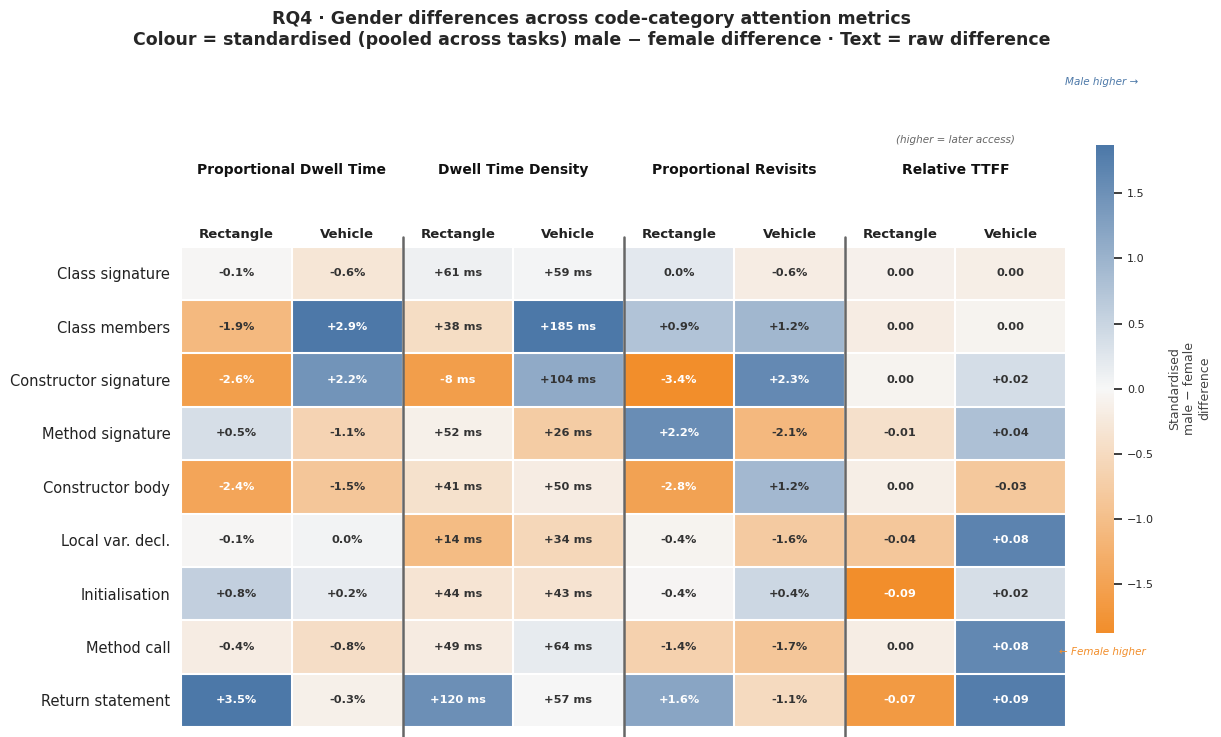

In [125]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd

# ── Style ─────────────────────────────────────────────────────────────────────
sns.set_theme(style='white', font_scale=1.0)
plt.rcParams.update({'font.family': 'sans-serif'})

# ── Gender colours ────────────────────────────────────────────────────────────
colors = {
    'male': '#4C78A8',
    'female': '#F28E2B'
}

# ── Config ────────────────────────────────────────────────────────────────────
# EXCLUDE control_flow — only keep categories common to both tasks
COMMON_CAT_ORDER = [
    'class_signature',
    'class_members',
    'constructor_signature',
    'method_signature',
    'constructor_body',
    'local_var_decl',
    'method_init',
    'method_call',
    'return_stmt',
]

CAT_LABELS = {
    'class_signature': 'Class signature',
    'class_members': 'Class members',
    'constructor_signature': 'Constructor signature',
    'method_signature': 'Method signature',
    'constructor_body': 'Constructor body',
    'local_var_decl': 'Local var. decl.',
    'method_init': 'Initialisation',
    'method_call': 'Method call',
    'return_stmt': 'Return statement',
}

METRICS = [
    ('prop_dwell_time',    'Proportional\nDwell Time', 'mean'),
    ('dwell_time_density', 'Dwell Time\nDensity',      'mean'),
    ('prop_revisits',      'Proportional\nRevisits',   'mean'),
    ('ttff_relative',      'Relative\nTTFF',           'median'),
]

task_ids = sorted(category_metrics['task'].unique())
task_names = {t: t.replace('_', ' ').title() for t in task_ids}


def build_raw_diff_matrix(task_df, cat_order):
    """
    Returns rows = categories, cols = metrics.
    Values are raw male - female differences.
    """
    out = {}
    task_df = task_df.copy()
    task_df['gender'] = task_df['gender'].astype(str).str.strip().str.lower()

    for metric, _, agg_kind in METRICS:
        if metric == 'ttff_relative':
            plot_df = task_df[
                task_df[metric].notna() &
                (task_df[metric] >= 0) &
                (task_df[metric] <= 1)
            ].copy()
        else:
            plot_df = task_df[
                task_df[metric].notna() &
                (task_df[metric] >= 0)
            ].copy()

        agg = (
            plot_df
            .groupby(['line_category', 'gender'])[metric]
            .agg('median' if agg_kind == 'median' else 'mean')
            .reset_index()
        )

        pivot = (
            agg.pivot(index='line_category', columns='gender', values=metric)
            .reindex(cat_order)
        )

        male = (
            pivot['male']
            if 'male' in pivot.columns
            else pd.Series(index=pivot.index, dtype=float)
        )
        female = (
            pivot['female']
            if 'female' in pivot.columns
            else pd.Series(index=pivot.index, dtype=float)
        )

        out[metric] = male - female

    return pd.DataFrame(out)


def format_raw_diff(metric, value):
    """Format raw difference in original units."""
    if pd.isna(value):
        return 'N/A'

    if metric in ['prop_dwell_time', 'prop_revisits']:
        pct = value * 100
        if abs(pct) < 0.05:
            return '0.0%'
        return f'{pct:+.1f}%'

    if metric == 'dwell_time_density':
        if abs(value) < 0.5:
            return '0 ms'
        return f'{value:+.0f} ms'

    if metric == 'ttff_relative':
        if abs(value) < 0.005:
            return '0.00'
        return f'{value:+.2f}'

    if abs(value) < 0.005:
        return '0.00'
    return f'{value:+.2f}'


# ── Build raw difference matrices for COMMON categories only ─────────────────
raw_diff_matrices = {}

for task_id in task_ids:
    task_df = category_metrics[category_metrics['task'] == task_id].copy()
    raw_diff_matrices[task_id] = build_raw_diff_matrix(task_df, COMMON_CAT_ORDER)


# ── Z-score raw differences metric-wise across all tasks ──────────────────────
z_diff_matrices = {
    task_id: pd.DataFrame(index=COMMON_CAT_ORDER)
    for task_id in task_ids
}

for metric, _, _ in METRICS:
    all_vals = []
    for task_id in task_ids:
        s = raw_diff_matrices[task_id][metric]
        all_vals.extend(s.dropna().tolist())

    all_vals = np.array(all_vals, dtype=float)
    mu = np.mean(all_vals)
    sd = np.std(all_vals, ddof=0)

    for task_id in task_ids:
        s = raw_diff_matrices[task_id][metric].reindex(COMMON_CAT_ORDER)
        if sd > 0:
            z_s = (s - mu) / sd
        else:
            z_s = s - mu
        z_diff_matrices[task_id][metric] = z_s


# ── Build unified matrix: columns = (metric, task) pairs ──────────────────────
n_cats = len(COMMON_CAT_ORDER)
n_metrics = len(METRICS)
n_tasks = len(task_ids)
n_cols = n_metrics * n_tasks

# Initialize matrices
unified_z = np.full((n_cats, n_cols), np.nan)
unified_raw = np.full((n_cats, n_cols), np.nan)
col_labels = []
col_metric_idx = []  # track which metric each column belongs to

col_idx = 0
for metric_idx, (metric, _, _) in enumerate(METRICS):
    for task_id in task_ids:
        # Fill column
        z_vals = z_diff_matrices[task_id][metric].values
        raw_vals = raw_diff_matrices[task_id][metric].values

        unified_z[:, col_idx] = z_vals
        unified_raw[:, col_idx] = raw_vals

        # Column label: full task name for clarity
        task_label = task_names[task_id]  # "Rectangle" or "Vehicle"
        col_labels.append(task_label)
        col_metric_idx.append(metric_idx)

        col_idx += 1


# ── Colour limit ──────────────────────────────────────────────────────────────
all_z_vals = unified_z.flatten()
all_z_vals = all_z_vals[~np.isnan(all_z_vals)]
clim = np.nanpercentile(np.abs(all_z_vals), 95)

cmap = mcolors.LinearSegmentedColormap.from_list(
    'gender_div',
    ['#F28E2B', '#F7F7F7', '#4C78A8'],
    N=256
)
cmap.set_bad(color='#E8E8E8')


# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7.5))

im = ax.imshow(
    unified_z,
    cmap=cmap,
    vmin=-clim,
    vmax=clim,
    aspect='auto',
    interpolation='nearest'
)

# Cell annotations (raw values)
for r in range(n_cats):
    for c in range(n_cols):
        z_val = unified_z[r, c]
        raw_val = unified_raw[r, c]

        metric = METRICS[col_metric_idx[c]][0]

        if not np.isnan(z_val):
            text_color = 'white' if abs(z_val) > clim * 0.6 else '#333333'
            label = format_raw_diff(metric, raw_val)

            ax.text(
                c, r, label,
                ha='center', va='center',
                fontsize=8.2, color=text_color, fontweight='semibold'
            )

# Y-axis: category labels
ax.set_yticks(range(n_cats))
ax.set_yticklabels(
    [CAT_LABELS[c] for c in COMMON_CAT_ORDER],
    fontsize=10.5, color='#222222'
)
ax.tick_params(axis='y', length=0, pad=8)

# X-axis: task labels (Rectangle/Vehicle) positioned at each column
ax.set_xticks(range(n_cols))
ax.set_xticklabels(col_labels, fontsize=9.5, color='#222222', fontweight='semibold')
ax.xaxis.tick_top()
ax.tick_params(axis='x', length=0, pad=4, labelbottom=False, labeltop=True)

# Add metric group labels ABOVE the task labels
metric_labels = [label.replace('\n', ' ') for _, label, _ in METRICS]
for metric_idx, metric_label in enumerate(metric_labels):
    # Each metric spans 2 columns (Rectangle + Vehicle)
    x_start = metric_idx * n_tasks
    x_center = x_start + (n_tasks - 1) / 2

    ax.text(
        x_center, -1.8,  # above the task labels
        metric_label,
        ha='center', va='bottom',
        fontsize=10, color='#111111', fontweight='semibold'
    )

    # Add clarifying subtitle for TTFF (semantic reversal)
    if metric_idx == 3:  # TTFF is the 4th metric
        ax.text(
            x_center, -2.4,
            '(higher = later access)',
            ha='center', va='bottom',
            fontsize=7.5, color='#666666', style='italic'
        )

    # Draw separator line between metric groups
    if metric_idx > 0:
        ax.axvline(x_start - 0.5, color='#666666', linewidth=1.8,
                   ymin=-0.05, ymax=1.02, clip_on=False, zorder=10)

# Grid lines between cells
ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_cats, 1), minor=True)
ax.grid(which='minor', color='white', linewidth=1.5)
ax.tick_params(which='minor', length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

# Colourbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.65])
cb = fig.colorbar(im, cax=cbar_ax)
cb.set_label(
    'Standardised\nmale − female\ndifference',
    fontsize=9, color='#444444', labelpad=10
)
cb.ax.tick_params(labelsize=8)
cb.outline.set_visible(False)

fig.text(0.925, 0.12, '← Female higher', ha='center', fontsize=7.5,
         color=colors['female'], style='italic')
fig.text(0.925, 0.88, 'Male higher →', ha='center', fontsize=7.5,
         color=colors['male'], style='italic')

# Title
fig.suptitle(
    'RQ4 · Gender differences across code-category attention metrics\n'
    'Colour = standardised (pooled across tasks) male − female difference · Text = raw difference',
    fontsize=12.5, fontweight='bold', y=0.98
)

plt.tight_layout(rect=[0, 0, 0.91, 0.94])
plt.savefig(
    'rq4_unified_heatmap_common_categories.png',
    dpi=300, bbox_inches='tight', facecolor='white'
)
plt.show()

*Caption - Gender differences across shared code‑category attention metrics in the Rectangle and Vehicle tasks.*

The figure summarises male–female differences across four attention metrics for code categories common to both tasks.

For each cell, colour represents the standardised male − female difference, computed within each metric using the pooled distribution across both tasks, allowing direct comparison of colour intensity between Rectangle and Vehicle.

Cell text reports the corresponding raw male − female difference in the original metric units: percentage‑point differences for Proportional Dwell Time and Proportional Revisits, milliseconds for Dwell Time Density, and proportion‑of‑stimulus‑duration units for Relative TTFF. Blue indicates higher values for the male‑labelled group, and orange indicates higher values for the female‑labelled group. For Relative TTFF, higher values indicate later first fixation.

Only code categories present in both tasks are shown to ensure direct comparability. This heatmap provides a descriptive overview of cross‑metric patterns; formal inference is based on the linear mixed‑effects models reported elsewhere.

*Interpretation*

 The pattern is heterogeneous rather than uniform, with several categories showing consistent directional differences across multiple metrics, and others showing task‑dependent reversals.

 In the Rectangle task, the Return statement category stands out with higher proportional dwell time, higher dwell time density, and higher proportional revisits for the male‑labelled group, while Relative TTFF indicates comparatively later first fixation for the female‑labelled group. In contrast, categories such as Constructor signature and Constructor body in Rectangle tend to show higher proportional attention and revisits for the female‑labelled group despite similar or higher dwell density for the male‑labelled group.

 In the Vehicle task, Class members exhibits the strongest male‑labelled group differences across proportional dwell time, dwell time density, and revisits, whereas several executable categories (for example, Local variable declaration, Method call, and Return statement) show positive Relative TTFF values, indicating later first fixation for the male‑labelled group.

 Across tasks, differences in attention allocation (dwell time and revisits) do not always align with differences in reading order (Relative TTFF), suggesting that where attention is concentrated and when categories are first accessed reflect partially distinct aspects of code comprehension behaviour.

 Because the heatmap combines raw differences with standardised colour encoding and does not display uncertainty, these patterns should be interpreted as descriptive trends that motivate and contextualise the results of the linear mixed‑effects models.

# Statistical Analysis

In [126]:

# Check skewness of all three outcome variables
for col in ['prop_dwell_time', 'prop_revisits' ,'dwell_time_density', 'ttff_relative']:
    skew = category_metrics[col].skew()
    kurt = category_metrics[col].kurt()
    print(f"{col}: skewness={skew:.3f}, kurtosis={kurt:.3f}")

prop_dwell_time: skewness=1.673, kurtosis=5.200
prop_revisits: skewness=1.262, kurtosis=4.614
dwell_time_density: skewness=2.454, kurtosis=11.138
ttff_relative: skewness=0.705, kurtosis=-0.796


In [127]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.special import logit

In [128]:
# ── Copy data ─────────────────────────────────────────────
lmm_df = category_metrics.copy()

# ── Common categories only: remove control_flow ───────────
common_categories = [
    'class_signature',
    'class_members',
    'constructor_signature',
    'method_signature',
    'constructor_body',
    'local_var_decl',
    'method_init',
    'method_call',
    'return_stmt'
]

lmm_df = lmm_df[lmm_df['line_category'].isin(common_categories)].copy()

# ── Clean categorical variables ───────────────────────────
lmm_df['task'] = pd.Categorical(
    lmm_df['task'],
    categories=['rectangle', 'vehicle']
)

lmm_df['gender'] = pd.Categorical(
    lmm_df['gender'],
    categories=['female', 'male']
)

lmm_df['line_category'] = pd.Categorical(
    lmm_df['line_category'],
    categories=common_categories
)

lmm_df['participant_id'] = lmm_df['participant_id'].astype('category')
lmm_df['task_order'] = lmm_df['task_order'].astype('category')

In [129]:
# Remove unused categories everywhere
for col in ['task', 'gender', 'line_category', 'participant_id', 'task_order']:
    lmm_df[col] = lmm_df[col].cat.remove_unused_categories()

##Proportional Dwell Time

In [130]:
# ── Quasi-logit transform ─────────────────────────────────
epsilon = 0.001

lmm_df['prop_dwell_clipped'] = lmm_df['prop_dwell_time'].clip(
    lower=epsilon,
    upper=1 - epsilon
)

lmm_df['logit_prop_dwell'] = np.log(
    lmm_df['prop_dwell_clipped'] / (1 - lmm_df['prop_dwell_clipped'])
)

# ── Drop missing model variables ──────────────────────────
model_df = lmm_df.dropna(
    subset=[
        'logit_prop_dwell',
        'gender',
        'task',
        'line_category',
        'expertise_programming_num',
        'task_order',
        'participant_id'
    ]
).copy()

A linear mixed-effects model was fitted with logit-transformed proportional dwell time as the dependent variable. Fixed effects included gender, line category, task, programming expertise, and task order, along with the interaction between gender and line category. A random intercept for participant was included to account for repeated measures. Only categories present in both tasks were included to ensure comparability.

Control-flow constructs were present only in the Vehicle task and were therefore excluded from the main analysis. A secondary analysis restricted to the Vehicle task was conducted to explore attention allocation to control-flow elements.

In [131]:
model = smf.mixedlm(
    "logit_prop_dwell ~ gender * line_category + task + expertise_programming_num + task_order",
    data=model_df,
    groups=model_df["participant_id"],
    re_formula="1"
)

result = model.fit(method="powell",reml=False,maxiter=1000)
#result = model.fit(method="lbfgs")

print(result.summary())

                              Mixed Linear Model Regression Results
Model:                         MixedLM            Dependent Variable:            logit_prop_dwell
No. Observations:              3023               Method:                        ML              
No. Groups:                    179                Scale:                         0.7995          
Min. group size:               5                  Log-Likelihood:                -3951.1599      
Max. group size:               18                 Converged:                     Yes             
Mean group size:               16.9                                                              
-------------------------------------------------------------------------------------------------
                                                      Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------------------
Intercept                                         

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning:

The MLE may be on the boundary of the parameter space.



**Proportional dwell time varies strongly by code category and task, but there is no statistically reliable evidence that these category-level patterns differ by gender.**


The model tested whether proportional dwell time differs by:
gender
- code category
- task
- expertise
- task order

The key term for RQ4 is:
gender × line_category (do males and females allocate attention differently across categories?)

No overall gender effect, gender[T.male] = -0.102, p = 0.451, indicating that male-labelled participants do not differ significantly from female-labelled participants in proportional dwell time.

No significant gender × line_category interactions, all interaction terms are non-significant.

Even though gender interactions are not significant, several other effects are significant and meaningful.

A) **Strong effect of line category**

Code category strongly influences where attention is allocated.
These coefficients show how proportional dwell time differs by code category relative to Class signature, for the female-labelled group in the Rectangle task, at task order 1, with expertise = 0.

Categories with higher proportional dwell time than class_signature

Class members: β = 0.861, p < .001
Constructor signature: β = 0.724, p < .001
Method signature: β = 1.385, p < .001
Constructor body: β = 1.073, p < .001
Return statement: β = 0.401, p = .020

Category with lower proportional dwell time than class_signature
Local var. decl.: β = -0.613, p < .001

Categories not significantly different from class_signature
Method init: β = 0.308, p = .072
Method call: β = 0.255, p = .137

B) **Strong task effect**

task[T.vehicle] = -0.491, p < .001
This means that, controlling for gender, line category, expertise, and task order, proportional dwell time is lower in the Vehicle task than in the Rectangle task.
Participants distributed attention differently in Vehicle than in Rectangle, such that category-level dwell-time shares were generally lower on the transformed scale in Vehicle.

C) **Task order effect**

task_order[T.2] = -0.077, p = .018
This suggests that the second task was associated with slightly lower proportional dwell time than the first task.
There may be a small practice / order / fatigue effect.

D) **Expertise effect**

expertise_programming_num = -0.058, p = .010
This indicates that higher programming expertise is associated with slightly lower proportional dwell time on the transformed scale.More experienced participants may distribute attention somewhat more efficiently or more selectively across categories. Should be interpreted with caution

The participant-level random intercept variance was estimated at approximately zero, suggesting minimal residual between-participant baseline variation once the fixed effects were included.

In [132]:
# Vehicle-only model WITH control_flow
vehicle_data = category_metrics[category_metrics['task'] == 'vehicle'].copy()

# Don't filter out control_flow this time
vehicle_data['line_category'] = pd.Categorical(
    vehicle_data['line_category'],
    categories=['class_signature', 'class_members', 'constructor_signature',
                'method_signature', 'constructor_body', 'local_var_decl',
                'method_init', 'method_call', 'return_stmt', 'control_flow']
)

# Same logit transform
epsilon = 0.001
vehicle_data['logit_prop_dwell'] = np.log(
    (vehicle_data['prop_dwell_time'].clip(epsilon, 1-epsilon)) /
    (1 - vehicle_data['prop_dwell_time'].clip(epsilon, 1-epsilon))
)

# Fit model
vehicle_model = smf.mixedlm(
    "logit_prop_dwell ~ gender * line_category + expertise_programming_num + task_order",
    data=vehicle_data.dropna(subset=['logit_prop_dwell', 'gender', 'line_category',
                                      'expertise_programming_num', 'task_order']),
    groups=vehicle_data["participant_id"]
)

vehicle_result = vehicle_model.fit(method="powell")
print(vehicle_result.summary())

                              Mixed Linear Model Regression Results
Model:                         MixedLM            Dependent Variable:            logit_prop_dwell
No. Observations:              1664               Method:                        REML            
No. Groups:                    179                Scale:                         0.6454          
Min. group size:               1                  Log-Likelihood:                -2018.1402      
Max. group size:               10                 Converged:                     Yes             
Mean group size:               9.3                                                               
-------------------------------------------------------------------------------------------------
                                                      Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------------------
Intercept                                         

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning:

The MLE may be on the boundary of the parameter space.



Overall gender difference is non-significant  p = 0.681

class_members: p = .044

One gender × category interaction emerged (class_members), but should be interpreted cautiously given it did not appear in the combined model.

Control flow dominates the attention:

line_category[T.control_flow] = +2.026, p < 0.001
This is the strongest category effect by far.
In the Vehicle task, participants allocate significantly more proportional dwell time to control flow structures than to any other category.

Covariates not significant

expertise_programming_num = -0.038, p = 0.166
task_order = -0.058, p = 0.142

## Propotional revisits

In [133]:

print("Skewness:", category_metrics["prop_revisits"].skew())
print("Kurtosis:", category_metrics["prop_revisits"].kurt())

print("Zero proportion:", (category_metrics["prop_revisits"] == 0).mean())
print("One proportion:", (category_metrics["prop_revisits"] == 1).mean())


Skewness: 1.2618280438525604
Kurtosis: 4.61365788696982
Zero proportion: 0.1178125
One proportion: 0.0003125


In [134]:
lmm_df["log_prop_revisits"] = np.log1p(lmm_df["prop_revisits"])

# ── Drop missing model variables ──────────────────────────
model_df = lmm_df.dropna(
    subset=[
        'log_prop_revisits',
        'gender',
        'task',
        'line_category',
        'expertise_programming_num',
        'task_order',
        'participant_id'
    ]
).copy()

In [135]:
revisit_model = smf.mixedlm(
    "log_prop_revisits ~ gender * line_category + task + expertise_programming_num + task_order",
    data=model_df,   # same filtered dataset (no control_flow)
    groups=model_df["participant_id"],
    re_formula="1"
)

revisit_result = revisit_model.fit(
    method="powell",
    reml=False,
    maxiter=1000
)

print(revisit_result.summary())

                             Mixed Linear Model Regression Results
Model:                       MixedLM            Dependent Variable:            log_prop_revisits
No. Observations:            3022               Method:                        ML               
No. Groups:                  179                Scale:                         0.0043           
Min. group size:             4                  Log-Likelihood:                3955.8215        
Max. group size:             18                 Converged:                     Yes              
Mean group size:             16.9                                                               
------------------------------------------------------------------------------------------------
                                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------
Intercept                                              0.064

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning:

The MLE may be on the boundary of the parameter space.

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning:

The Hessian matrix at the estimated parameter values is not positive definite.



Model findings (proportional revisits)
- Revisit behaviour differed significantly across code categories
- Method signatures, constructor signatures, and constructor bodies showed the highest levels of revisiting
- Local variable declarations did not differ significantly from the reference category
- No significant main effect of gender was observed
- No significant gender × category interaction effects were found
- This indicates that male and female participants did not differ in how reprocessing effort was distributed across code categories
- The Vehicle task showed slightly lower revisit levels than the Rectangle task
- Task order and programming expertise were not significant predictors
- Participant-level variation was negligible after accounting for fixed effects

In [136]:
# Vehicle-only model WITH control_flow
vehicle_data = category_metrics[category_metrics['task'] == 'vehicle'].copy()

vehicle_data['line_category'] = pd.Categorical(
    vehicle_data['line_category'],
    categories=[
        'class_signature', 'class_members', 'constructor_signature',
        'method_signature', 'constructor_body', 'local_var_decl',
        'method_init', 'method_call', 'return_stmt', 'control_flow'
    ]
)

vehicle_data['gender'] = pd.Categorical(
    vehicle_data['gender'],
    categories=['female', 'male']
)

vehicle_data['participant_id'] = vehicle_data['participant_id'].astype('category')
vehicle_data['task_order'] = vehicle_data['task_order'].astype('category')

# Transform revisits
vehicle_data["log_prop_revisits"] = np.log1p(vehicle_data["prop_revisits"])

# Drop missing values FIRST
vehicle_model_df = vehicle_data.dropna(
    subset=[
        'log_prop_revisits',
        'gender',
        'line_category',
        'expertise_programming_num',
        'task_order',
        'participant_id'
    ]
).copy()

# Remove unused categories after filtering
for col in ['gender', 'line_category', 'participant_id', 'task_order']:
    vehicle_model_df[col] = vehicle_model_df[col].cat.remove_unused_categories()

# Fit model
vehicle_model = smf.mixedlm(
    "log_prop_revisits ~ gender * line_category + expertise_programming_num + task_order",
    data=vehicle_model_df,
    groups=vehicle_model_df["participant_id"],
    re_formula="1"
)

vehicle_result = vehicle_model.fit(
    method="powell",
    reml=False,
    maxiter=1000
)

print(vehicle_result.summary())

                             Mixed Linear Model Regression Results
Model:                       MixedLM            Dependent Variable:            log_prop_revisits
No. Observations:            1663               Method:                        ML               
No. Groups:                  178                Scale:                         0.0035           
Min. group size:             5                  Log-Likelihood:                2333.3801        
Max. group size:             10                 Converged:                     Yes              
Mean group size:             9.3                                                                
------------------------------------------------------------------------------------------------
                                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------
Intercept                                              0.060

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning:

The MLE may be on the boundary of the parameter space.

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning:

The Hessian matrix at the estimated parameter values is not positive definite.



Vehicle-only revisits model (with control_flow)

- Revisit behaviour differed significantly across code categories
- Method signatures and control-flow constructs showed the highest levels of revisiting
- Constructor-related categories also showed elevated revisiting
- Local variable declarations, method calls, and return statements did not differ significantly from the reference category
- No significant main effect of gender was observed
- No significant gender × category interactions were found, including for control-flow constructs
- This indicates that male and female participants did not differ in how reprocessing effort was allocated across code categories
- Programming expertise and task order were not significant predictors
- Participant-level variability was negligible after accounting for fixed effects

## Dwell time density

In [137]:
print("Skewness:", category_metrics["dwell_time_density"].skew())
print("Kurtosis:", category_metrics["dwell_time_density"].kurt())

print("Zero proportion:", (category_metrics["dwell_time_density"] == 0).mean())
print("One proportion:", (category_metrics["dwell_time_density"] == 1).mean())

Skewness: 2.454001675756951
Kurtosis: 11.138204116095144
Zero proportion: 0.0
One proportion: 0.0


In [138]:
# Transform
lmm_df["log_dwell_time_density"] = np.log(lmm_df["dwell_time_density"])

# Drop missing
model_df = lmm_df.dropna(
    subset=[
        'log_dwell_time_density',
        'gender',
        'task',
        'line_category',
        'expertise_programming_num',
        'task_order',
        'participant_id'
    ]
).copy()

# Fit model
density_model = smf.mixedlm(
    "log_dwell_time_density ~ gender * line_category + task + expertise_programming_num + task_order",
    data=model_df,
    groups=model_df["participant_id"],
    re_formula="1"
)

density_result = density_model.fit(
    method="powell",
    reml=False,
    maxiter=1000
)

print(density_result.summary())

                             Mixed Linear Model Regression Results
Model:                      MixedLM          Dependent Variable:          log_dwell_time_density
No. Observations:           3023             Method:                      ML                    
No. Groups:                 179              Scale:                       0.5688                
Min. group size:            5                Log-Likelihood:              -3617.2595            
Max. group size:            18               Converged:                   Yes                   
Mean group size:            16.9                                                                
------------------------------------------------------------------------------------------------
                                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------
Intercept                                              5.309

 Model summary (dwell time density)


Significant main effect of line category → dwell time density varies by code construct


No significant main effect of gender


No significant gender × category interactions


Category-level patterns

Lower dwell time density for:

constructor_signature (p = .006)


method_signature (p = .010)


method_init (p < .001, strongest)

Suggests shallower processing of structural elements



Task effects

- Vehicle task → higher dwell time density (p < .001)
- Task 2 → lower dwell time density (p = .001)
- Indicates task difficulty + learning effects


Expertise

Programming expertise → not significant



Random effects


Non-zero group variance → meaningful participant-level variability



Interpretation (RQ4)

- Attention allocation intensity differs by code category
- No evidence of gender differences in processing intensity
- Effects driven by code structure and task, not gender



In [139]:
# Vehicle-only model WITH control_flow
vehicle_data = category_metrics[category_metrics['task'] == 'vehicle'].copy()

vehicle_data['line_category'] = pd.Categorical(
    vehicle_data['line_category'],
    categories=[
        'class_signature', 'class_members', 'constructor_signature',
        'method_signature', 'constructor_body', 'local_var_decl',
        'method_init', 'method_call', 'return_stmt', 'control_flow'
    ]
)

vehicle_data['gender'] = pd.Categorical(
    vehicle_data['gender'],
    categories=['female', 'male']
)

vehicle_data['participant_id'] = vehicle_data['participant_id'].astype('category')
vehicle_data['task_order'] = vehicle_data['task_order'].astype('category')

# Transform revisits
vehicle_data["log_dwell_time_density"] = np.log(vehicle_data["dwell_time_density"])

# Drop missing values FIRST
vehicle_model_df = vehicle_data.dropna(
    subset=[
        'log_dwell_time_density',
        'gender',
        'line_category',
        'expertise_programming_num',
        'task_order',
        'participant_id'
    ]
).copy()

# Remove unused categories after filtering
for col in ['gender', 'line_category', 'participant_id', 'task_order']:
    vehicle_model_df[col] = vehicle_model_df[col].cat.remove_unused_categories()

# Fit model
vehicle_model = smf.mixedlm(
    "log_dwell_time_density ~ gender * line_category + expertise_programming_num + task_order",
    data=vehicle_model_df,
    groups=vehicle_model_df["participant_id"],
    re_formula="1"
)

vehicle_result = vehicle_model.fit(
    method="powell",
    reml=False,
    maxiter=1000
)

print(vehicle_result.summary())

                             Mixed Linear Model Regression Results
Model:                      MixedLM          Dependent Variable:          log_dwell_time_density
No. Observations:           1664             Method:                      ML                    
No. Groups:                 179              Scale:                       0.5172                
Min. group size:            1                Log-Likelihood:              -1969.6598            
Max. group size:            10               Converged:                   Yes                   
Mean group size:            9.3                                                                 
------------------------------------------------------------------------------------------------
                                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------
Intercept                                              5.321

Model summary (vehicle task only)

- Significant main effect of line category - dwell time density varies across code constructs
- No significant main effect of gender
- No statistically significant gender × category interactions
- Model converged successfully with non-zero participant variance

Control flow (key addition)
- Control flow not significantly different from the reference category (p = .460)
- No gender difference in control flow processing (interaction p = .932)
- Suggests control flow does not receive uniquely higher or lower processing intensity, and is processed similarly by both genders
Category-level effects

- Lower dwell time density for:
local_var_decl (p = .031)
method_init (p < .001, strongest effect)
- Indicates reduced processing effort for these categories
- Other categories (e.g., method_signature, constructor_signature) show no strong differences

Gender effects
- No overall gender difference in dwell time density (p = .413)
- No reliable gender differences within any specific category
- A marginal trend for:
class_members (p = .056), but not statistically significant

Task order & expertise
Task order → not significant

Programming expertise → marginal positive effect (p = .065)

Suggests slightly higher dwell density with more expertise, but weak evidence

Random effects

Group variance = 0.269 → substantial participant-level variability
Confirms that individual differences in attention allocation exist


Interpretation (RQ4 – extended with control flow)

- Attention allocation intensity differs by code construct, even within the same task
- Control flow does not stand out as uniquely demanding
- No evidence of gender differences in processing intensity across any category
- Overall, attention allocation patterns are driven by code structure rather than gender

## Relative time to first fixation

In [140]:

print("Skewness:", category_metrics["ttff_relative"].skew())
print("Kurtosis:", category_metrics["ttff_relative"].kurt())

print("Zero proportion:", (category_metrics["ttff_relative"] == 0).mean())
print("One proportion:", (category_metrics["ttff_relative"] == 1).mean())

Skewness: 0.7052312191058814
Kurtosis: -0.796240959834372
Zero proportion: 0.04
One proportion: 0.0


In [141]:

lmm_df['ttff_relative'] = category_metrics['ttff_relative']

# Drop missing
model_df = lmm_df.dropna(
    subset=[
        'ttff_relative',
        'gender',
        'task',
        'line_category',
        'expertise_programming_num',
        'task_order',
        'participant_id'
    ]
).copy()

ttfr_model = smf.mixedlm(
    "ttff_relative ~ gender * line_category + task + expertise_programming_num + task_order",
    data=model_df,
    groups=model_df["participant_id"],
    re_formula="1"
)

ttfr_result = ttfr_model.fit(
    method="powell",
    reml=False,
    maxiter=1000
)

print(ttfr_result.summary())





                             Mixed Linear Model Regression Results
Model:                         MixedLM             Dependent Variable:             ttff_relative
No. Observations:              3023                Method:                         ML           
No. Groups:                    179                 Scale:                          0.0256       
Min. group size:               5                   Log-Likelihood:                 1110.9653    
Max. group size:               18                  Converged:                      Yes          
Mean group size:               16.9                                                             
------------------------------------------------------------------------------------------------
                                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------
Intercept                                             -0.006

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning:

The MLE may be on the boundary of the parameter space.



Model summary (relative TTFF)

- Significant main effect of line category -attention priority differs across code constructs
- No significant main effect of gender
- No significant gender × category interactions
- Model converged with very small but non-zero participant variance

Category-level patterns (attention priority)

- Later attention (higher TTFF) for:

method_init (strongest, p < .001)

method_call (p < .001)

local_var_decl (p < .001)

return_stmt (p < .001)

method_signature (p < .001)

- Indicates these categories are visited later in the reading sequence
constructor_signature and constructor_body also accessed later, but with smaller effects

Task effects

Vehicle task → later first fixation overall (p < .001)

→ suggests more distributed or delayed attention in more complex code

Task order

Task 2 → slightly later fixation (p = .023)
→ small shift in reading strategy over time

Gender effects

No overall gender difference (p = .330)
No significant gender differences across categories

Weak trend:
method_init (p = .070) → males slightly earlier, but not significant


 Expertise
Marginal effect (p = .058)
→ higher expertise associated with slightly earlier attention, but weak evidence

Random effects
Very small group variance (0.005)
→ little between-participant variability in reading order

Interpretation (RQ4 – attention priority)
Code comprehension follows a structured reading order driven by code semantics
Certain constructs (e.g., initialization, method calls, variables) are systematically accessed later

No evidence of gender differences in attention priority

Reading order is influenced by task complexity and code structure, not gender

In [142]:
# Vehicle-only model WITH control_flow
vehicle_data = category_metrics[category_metrics['task'] == 'vehicle'].copy()

vehicle_data['line_category'] = pd.Categorical(
    vehicle_data['line_category'],
    categories=[
        'class_signature', 'class_members', 'constructor_signature',
        'method_signature', 'constructor_body', 'local_var_decl',
        'method_init', 'method_call', 'return_stmt', 'control_flow'
    ]
)

vehicle_data['gender'] = pd.Categorical(
    vehicle_data['gender'],
    categories=['female', 'male']
)

vehicle_data['participant_id'] = vehicle_data['participant_id'].astype('category')
vehicle_data['task_order'] = vehicle_data['task_order'].astype('category')


# Drop missing values FIRST
vehicle_model_df = vehicle_data.dropna(
    subset=[
        'ttff_relative',
        'gender',
        'line_category',
        'expertise_programming_num',
        'task_order',
        'participant_id'
    ]
).copy()

# Remove unused categories after filtering
for col in ['gender', 'line_category', 'participant_id', 'task_order']:
    vehicle_model_df[col] = vehicle_model_df[col].cat.remove_unused_categories()

# Fit model
vehicle_model = smf.mixedlm(
    "ttff_relative ~ gender * line_category + expertise_programming_num + task_order",
    data=vehicle_model_df,
    groups=vehicle_model_df["participant_id"],
    re_formula="1"
)

vehicle_result = vehicle_model.fit(
    method="powell",
    reml=False,
    maxiter=1000
)

print(vehicle_result.summary())

                             Mixed Linear Model Regression Results
Model:                         MixedLM             Dependent Variable:             ttff_relative
No. Observations:              1664                Method:                         ML           
No. Groups:                    179                 Scale:                          0.0232       
Min. group size:               1                   Log-Likelihood:                 628.6008     
Max. group size:               10                  Converged:                      Yes          
Mean group size:               9.3                                                              
------------------------------------------------------------------------------------------------
                                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------
Intercept                                              0.041

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning:

The MLE may be on the boundary of the parameter space.

